# EDA — Representation × Kiwi × o200k 3-Layer Casebook

**Artifact class**: `EXPLORATORY / PRE-NB07 / PRE-F07 MULTILAYER DIAGNOSTIC CASEBOOK`

> 이 notebook은 **canonical NB07이 아니며 F07 final figure도 아니다.**
> Gate 판정, 새 QC/exclusion, full-population morph/token pipeline 실행 권한이 없다.
> 산출물은 이 notebook 파일 하나이며, 그 자체가 이 exploratory 작업의 reproducibility record다.

---

## 0.1 Lane boundary

| Lane | 담당 | 이 notebook |
|---|---|---|
| Claude-A | engineering / full-population computation | **침범 안 함** |
| Claude-B | research / statistics / Gate 판단 | **침범 안 함** |
| Claude-VIZ (이 lane) | data visualization / exploratory casebook | 본 notebook |

금지 사항 (이 notebook 내에서 수행하지 않음):

- Gate(G2/G3/G4) 판정 · 새 QC rule · 새 exclusion
- full-population morphology / tokenizer 실행
- `src/`, `tests/`, canonical notebook 03/04/05 수정
- 새 `.py` helper module 생성
- Git add / commit / push
- 원문 KO/EN 문장 텍스트의 출력 (repository hygiene; OPS-DR-01 remediation 정책 일관)

---

## 0.2 Authority order

1. `KOEN-TP-RS-001` — `Korean_English_Tokenization_Premium_Research_Spec_v1.0`
2. approved redline / Research Director decisions (`CR-001~004`, `D-RD-01~09`)
3. frozen contracts (`docs/contracts/**`)
4. operational documents (`ssot/*.md` decision logs)
5. execution evidence (`outputs/manifests/**`, `outputs/reports/**`)

SSOT가 말하지 않은 내용은 SSOT에서 나온 것처럼 서술하지 않는다. 본 notebook에서
SSOT 밖의 판단은 모두 `[VIZ-JUDGMENT]`로 표시한다.

---

## 0.3 SSOT section map — 이 notebook이 직접 대응하는 조항

| SSOT § | 내용 | 대응 cell |
|---|---|---|
| §5 / §5.1 | morphology ≠ regex chunk ≠ final subword token (핵심 구분표) | 10 (triptych 경고), 00.4 |
| §8 / §8.1–8.4 | Exact Decomposition ($TP = CR \times BDR \times CP$) | 09 |
| §9.2 | 층화 변수 (domain / sentence_type / direction / source_id / length_stratum) | 04, 13 |
| §12.1 | D-01 Pair Registry metadata | 04, 13 |
| §12.2 | D-02 Representation Features | 02, 05, 06 |
| §12.3 | D-03 Morphology Measurement | 07 |
| §12.4 | D-04 Token Measurement | 08 |
| §13.3 | Byte Density $B_{i,l}/C_{i,l}$ | 05, 06, 09 |
| §13.4 | Whitespace Density $W_{i,l}/C_{i,l}$ | 05, 06 |
| §13.5 | Pair Length Ratio $\log(C_{KO}/C_{EN})$ | 06, 09 |
| §13.6 | Morpheme Density | 07, 11 |
| §13.7 | Particle / Ending Ratio | 07, 11, 12 |
| §14 | Tokenizer 고정 규약 (o200k_base, tiktoken 0.13.0, hash 기록) | 02, 08, 15 |
| §15 | 형태소 분석 고정 규약 (Kiwi 0.23.2 / model 0.23.0, custom dict 금지) | 02, 07, 15 |
| §16.1 | 핵심 분포 | 05 |
| §16.2 | 필수 시각화 (F01–F08 계보) | 06, 08, 09, 10 |
| §16.3 | Extreme-case audit (극단값 선삭제 금지) | 12 |
| §20.2 | Identifiability Gate (source × domain) | 13 |
| §31 | G2 / G3 / G4 PASS 조건 | 09 (identity), 08 (roundtrip), 07 (analyzer freeze) — **증거 제시만, 판정 없음** |
| §32 | T-04 domain-source confounding / T-05 analyzer error / T-06 feature overlap | 12, 13 |
| §37 | Notebook 실행 순서 (Phase 3 / Phase 4) | 02 (artifact census) |

## 0.5 현재 연구 위치 — 실제 파일로 검증한 결과

Directive가 제시한 기대 상태와 **실측값이 다르다.** 사실을 그대로 기록한다.

| 항목 | Directive 기대 | 실측 (본 notebook 실행 시점) |
|---|---|---|
| remote main | `cc6fb979cdf5759dbda327286490c49a97305212` | 로컬 HEAD가 `cc6fb97` 이후 **3 commit 전진** (`a8e583a` → `3ebf256` → `287781a`) |
| G0 / G1 | PASS / CLOSED | 변경 없음 (`KOEN_G1_HUMAN_AUDIT_FINAL_ADJUDICATION.md` 기준 G1 = PASS) |
| Final cohort | N = 3,835,988 | **일치** (`REP_FEATURES` row_count = 3,835,988) |
| Representation | population complete | v001 완료 + 실행 중 **`REP_FEATURES_v002` 신규 생성**(49열, lexical length 추가) |
| Morphology | pilot complete / full 미정 | full artifact **없음** → `SAMPLE_RECOMPUTE_ALLOWED` |
| o200k | preflight complete / full 미정 | full artifact **없음** → `SAMPLE_RECOMPUTE_ALLOWED` |
| NB06 / NB07 | 미완 / 미착수 | 변경 없음 |

또한 본 notebook을 작성하는 동안 upstream(`src/`)이 라이브로 변경되었다:
`RD-20260817-D02D03-CONFORMANCE-01`에 따라 `morpheme_density` 분모가
`codepoint_count` → `eojeol_count`(SSOT §13.6 준수)로 바뀌었고,
`REP_FEATURES_v002`가 생성되었다. 본 notebook은 이 변경을 **관측·기록**하고 최신 artifact에
맞춰 자신을 적응시켰을 뿐, `src/`를 수정하지 않았다. 정확한 코드 상태는 cell 15의
`src_module_sha256`으로 고정되어 있다 (`src/`가 uncommitted 상태라 git SHA만으로는 특정 불가).

## 0.4 §5.1 핵심 구분 — 이 notebook 전체에 적용되는 불변 경고

SSOT §5.1 표를 그대로 인용한다.

| 구분 | 형태소 분석 | Regex chunking / pre-token stage | 최종 subword tokenization |
|---|---|---|---|
| 목적 | 문법·형태 구조 분석 | BPE 전 문자열 1차 분할 | 모델 입력용 token ID 생성 |
| 기준 | 어근·접사·조사·어미, POS | Unicode category, 공백, 숫자, 구두점, regex | mergeable ranks, vocabulary, special token 규칙 |
| 언어학적 경계 | 중요 | **보장하지 않음** | **보장하지 않음** |
| 연구상 역할 | 외생적 설명 feature | tokenizer mechanism audit | 결과변수 생성 과정 |

$$\texttt{MORPHEME BOUNDARY} \;\neq\; \texttt{TOKENIZER REGEX CHUNK} \;\neq\; \texttt{FINAL TOKEN BOUNDARY}$$

이 notebook에는 **regex chunk layer(D-05 / NB06)가 존재하지 않는다.** 따라서 morpheme과
token을 동일 boundary로 align했다고 표현하지 않으며, 세 layer를 겹쳐 그리지 않고
항상 분리된 panel로 배치한다.

---

# 01 — Dataviz skill 적용 규약 및 Resource Isolation

## A. SSOT reference
- §16.2 필수 시각화; §30.1 환경 재현성; ENG-OBS-001 §10 memory guardrails.

## B. Dataviz skill (loaded)
`dataviz` (bundled skill pack `2.1.233`). 이 skill의 절차를 순서대로 적용했다.

1. **형태 선택** — 데이터의 job이 형태를 정한다 (`choosing-a-form.md`).
2. **색은 job으로 배정** — categorical / ordinal / sequential / diverging / status (`color-formula.md`).
3. **팔레트는 계산으로 검증** — `scripts/validate_palette.js` 실행 결과를 아래 표에 기록.
4. **mark spec** — thin marks, 2px surface gap, hairline solid grid, 선택적 direct label.
5. (hover layer는 정적 matplotlib figure에 해당 없음 — table view로 대체)
6. **접근성** — 2계열 이상은 항상 legend, 값은 table로도 도달 가능, 색만으로 의미 전달 금지.

### 검증된 색 역할 계약 (`--pairs all`, light/dark 양 모드)

색 역할을 섞지 않기 위해 8개 categorical slot을 **서로 겹치지 않는 3개 family로 분할**했다.
20개의 무충돌 분할 후보를 전수 열거한 뒤, decomposition에 all-pairs 안전 등급을,
KO/EN에 최강 분리 페어를 배정하는 조합을 선택했다.

| Family | 역할 | Light | Dark | 검증 결과 |
|---|---|---|---|---|
| Language side | **KO** | `#2a78d6` | `#3987e5` | CVD ΔE 24.7 / 26.8 · NV 33.6 / 31.8 · **ALL PASS** |
| Language side | **EN** | `#eb6834` | `#d95926` | (동일 페어) |
| Decomposition | `log CodePointRatio` | `#1baf7a` | `#199e70` | CVD ΔE 6.9 / 6.5 (floor band) · NV 31.3 / 22.5 · **PASS + 보조부호 필수** |
| Decomposition | `log ByteDensityRatio` | `#4a3aa7` | `#9085e9` | (동일 trio) |
| Decomposition | `log CompressionPenalty` | `#e34948` | `#e66767` | (동일 trio) |
| Morphology | particle `J*` | `#e87ba4` | `#d55181` | CVD ΔE 16.2 / 6.9 · NV 19.6 / 19.3 · **PASS** |
| Morphology | ending `E*` | `#eda100` | `#c98500` | (동일 trio) |
| Morphology | deriv affix `XS*` | `#008300` | `#008300` | (동일 trio) |
| Morphology | other (잔여) | `#898781` | `#898781` | de-emphasis 회색 — 9번째 hue 생성 아님 |

**WARN 대응 (skill 규칙상 무시 불가):**

- Decomposition trio는 CVD floor band(6–8)에 있다 → **보조 부호 의무**: 컴포넌트를 항상
  `CR → BDR → CP` 고정 순서로 배치(위치 부호), 모든 bar에 직접 수치 label, 2px surface gap.
- Light 표면에서 `#1baf7a`(2.74), `#e87ba4`(2.62), `#eda100`(2.11)이 3:1 미만 →
  **relief 의무**: 가시적 direct label + table view를 항상 함께 제공.

**의미 규칙**: `blue = KO side`, `orange = EN side`. `morpheme_density`·`particle_ratio` 등
KO 전용 단일 측정치는 SSOT §13.6/§13.7 정의상 KO side 수량이므로 blue를 쓰며, 단일 계열이므로
legend box를 두지 않는다(제목이 측정치를 명명한다).

**금지**: domain을 hue로 encode하지 않는다(→ **facet**). length는 ordered label,
source/direction은 marker shape 또는 annotation으로 표현한다. hue overload 금지.

## C. Resource isolation (절대 요구)
Main Claude-A의 computation과 CPU/RAM/I/O를 경쟁하지 않는다.

- `os.nice(10)` — Linux process priority 하향
- thread budget **MAX 2** (`OMP/MKL/OPENBLAS/NUMEXPR_NUM_THREADS=2`)
- DuckDB `memory_limit=1GB`, `threads=2`, spill `.runtime/dataviz-spill`
- 새 GPU workload 금지 · `torch`/`cudf`/`rapids` import 금지
- full parquet을 pandas로 load하지 않는다 (DuckDB streaming aggregate만 사용)

## D. Main-A interference guard
각 full-population aggregate cell 직전에 프로세스/CPU/RAM을 확인하고, 다음 중 하나면
해당 cell을 SKIP하고 `AUTHOR_ONLY_OR_SAMPLE_ONLY_MODE`로 전환한다.

- Main-A heavy job 탐지 · `mem_available < 6 GiB` · system CPU 지속 고부하

**A의 job을 절대 kill/pause하지 않는다.**

In [1]:
# /**
#  * @cell thread budget·process priority·DuckDB 한도를 먼저 고정하고, 시각화 공통 규약을 로드한다.
#  * @ssot §30.1 환경 재현성; ENG-OBS-001 §10 memory guardrails; Directive §3 Resource Isolation
#  * @why numpy/BLAS는 import 시점에 thread pool을 만들기 때문에, 환경변수는 반드시 import 이전에
#  *      설정해야 Main-A와의 CPU 경쟁을 실제로 막을 수 있다. 나중에 설정하면 효과가 없다.
#  * @input 없음 (환경 자체가 입력이다)
#  * @output THREAD_BUDGET, PALETTE, MARK, 그리고 설정된 matplotlib rcParams
#  * @data_type THREAD_BUDGET=int, PALETTE=dict[str,str], MARK=dict[str,float]
#  * @target 이 notebook이 소비하는 자원의 상한 자체
#  * @controls 없음 (통제 대상이 아니라 통제 수단이다)
#  * @risk nice(10)은 우선순위만 낮출 뿐 자원 사용량을 0으로 만들지 않는다. RAM 상한은 별도로 지킨다.
#  */

# @line thread 상한을 numpy/BLAS import 이전에 환경변수로 박아야 실제로 적용되므로 os를 먼저 부른다.
import os

# @line 4개 BLAS/병렬 백엔드 전부에 동일한 2-thread 상한을 걸어 Main-A의 CPU를 잠식하지 않는다.
THREAD_BUDGET = 2
for _var in ("OMP_NUM_THREADS", "MKL_NUM_THREADS", "OPENBLAS_NUM_THREADS", "NUMEXPR_NUM_THREADS"):
    # @line 하나라도 빠지면 해당 백엔드가 24코어를 전부 점유할 수 있으므로 반복문으로 빠짐없이 설정한다.
    os.environ[_var] = str(THREAD_BUDGET)

# @line Linux scheduler 우선순위를 10만큼 낮춰 Main-A의 job이 항상 먼저 CPU를 얻도록 양보한다.
try:
    os.nice(10)
except (OSError, PermissionError):
    # @line 컨테이너 등에서 nice가 막혀 있어도 notebook 전체를 중단시키지는 않고 사실만 기록한다.
    pass

# @line 표준 라이브러리 — 경로/시간/해시/직렬화는 모두 재현성 record에 들어가므로 미리 확보한다.
import hashlib
import json
import platform
import subprocess
import sys
import time
from datetime import datetime
from pathlib import Path
from zoneinfo import ZoneInfo

# @line psutil은 heartbeat contract가 요구하는 RSS/available memory를 읽는 표준 수단이다.
import psutil

# @line 이 notebook은 GPU workload를 만들지 않는다는 계약을 코드로 강제한다(torch/cudf/rapids 금지).
_FORBIDDEN_MODULES = ("torch", "cudf", "cuml", "cupy", "rapids")
for _m in _FORBIDDEN_MODULES:
    # @line 이미 다른 셀이 몰래 import했는지 sys.modules로 검사해 GPU 계약 위반을 즉시 드러낸다.
    assert _m not in sys.modules, f"금지된 GPU 모듈이 이미 로드되어 있다: {_m}"

# @line KST는 프로젝트 전체 timestamp 규약(manifest의 *_kst 필드)과 동일한 시간대다.
KST = ZoneInfo("Asia/Seoul")
# @line notebook 실행 시각을 한 번만 고정해, 모든 cell이 같은 실행 세션 식별자를 공유하게 한다.
RUN_STARTED_KST = datetime.now(KST)
# @line run_id는 다른 canonical notebook의 명명 규칙(NBxx_MODE_타임스탬프)을 따르되 VIZ lane임을 명시한다.
RUN_ID = f"VIZ_CASEBOOK_{RUN_STARTED_KST:%Y%m%dT%H%M%S}"

print(f"RUN_ID = {RUN_ID}")
print(f"THREAD_BUDGET = {THREAD_BUDGET} (OMP/MKL/OPENBLAS/NUMEXPR)")
print(f"os.nice applied → current niceness = {os.nice(0)}")

RUN_ID = VIZ_CASEBOOK_20260817T151317
THREAD_BUDGET = 2 (OMP/MKL/OPENBLAS/NUMEXPR)
os.nice applied → current niceness = 10


In [2]:
# /**
#  * @cell canonical project root를 확정하고 src의 검증된 함수를 import한다(재구현 금지).
#  * @ssot §36 프로젝트 IA; CR-001 canonical namespace = src/tokenization_premium/
#  * @why 경로를 하드코딩하면 worktree가 바뀔 때 다른 저장소에 쓰게 된다. eda/g1-support 브랜치가
#  *      실제로 겪은 portability defect(절대경로 하드코딩)를 반복하지 않기 위해 package root를 쓴다.
#  * @input 없음
#  * @output PROJECT_ROOT, 그리고 representation/morphology/tokenizer_measurement/tokenization 함수
#  * @data_type PROJECT_ROOT=pathlib.Path, 나머지는 callable
#  * @target 이 notebook이 canonical 구현과 동일한 정의를 쓴다는 사실 자체
#  * @controls 없음
#  * @risk src의 함수를 import한다는 것은 그 버전에 종속된다는 뜻이다. 버전은 cell 15에 기록한다.
#  */

# @line notebook은 notebooks/exploratory/ 아래에 있으므로 두 단계 위가 repository root다.
PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / "pyproject.toml").is_file() and PROJECT_ROOT != PROJECT_ROOT.parent:
    # @line pyproject.toml이 나올 때까지 상위로 올라가면 어느 하위 디렉터리에서 실행해도 root를 찾는다.
    PROJECT_ROOT = PROJECT_ROOT.parent

# @line src layout 패키지를 import할 수 있도록 src를 경로에 넣되, 중복 삽입은 피한다.
_SRC = PROJECT_ROOT / "src"
if str(_SRC) not in sys.path:
    sys.path.insert(0, str(_SRC))

# @line 표면형 feature 정의는 재구현하지 않고 NB03이 실제로 쓴 canonical 함수를 그대로 가져온다.
from tokenization_premium.representation import (  # noqa: E402
    COHORT_FILTER_SQL,
    REPRESENTATION_CONFIG_SHA256,
    REP_FEATURES_SCHEMA_VERSION,
    lexical_segment_count,
    side_features,
)

# @line 형태소 feature도 NB04와 동일한 Kiwi 설정(custom dictionary 없음)을 그대로 재사용한다.
from tokenization_premium.morphology import (  # noqa: E402
    ANALYZER_MODEL_MANIFEST_SHA256,
    ANALYZER_MODEL_VERSION,
    ANALYZER_PACKAGE_VERSION,
    MORPHOLOGY_CONFIG,
    MORPHOLOGY_CONFIG_SHA256,
    get_kiwi,
    morphology_features,
)

# @line o200k 측정과 exact decomposition identity도 NB05 scaffold의 검증된 함수를 그대로 쓴다.
from tokenization_premium.tokenizer_measurement import (  # noqa: E402
    EXACT_DECOMPOSITION_EPSILON,
    pair_token_measurement,
)

# @line offline cache만 사용하는 tokenizer loader — network fallback을 원천 차단하기 위함이다.
from tokenization_premium.tokenization import load_o200k_base_offline  # noqa: E402

# @line 한글 glyph를 실제 cmap 수준에서 보장하는 font만 고르는 검증된 helper를 재사용한다.
from tokenization_premium.visualization import find_korean_font  # noqa: E402

print(f"PROJECT_ROOT = {PROJECT_ROOT}")
print(f"COHORT_FILTER_SQL = {COHORT_FILTER_SQL}")
print(f"EXACT_DECOMPOSITION_EPSILON = {EXACT_DECOMPOSITION_EPSILON:g}")

PROJECT_ROOT = /home/sieg/projects-wsl/Tokenization_KOEN
COHORT_FILTER_SQL = pair_quality_status = 'accepted' AND analysis_eligible_exact_dedup AND logical_corpus IN ('025', '026')
EXACT_DECOMPOSITION_EPSILON = 1e-10


In [3]:
# /**
#  * @cell Main-A 간섭 가드를 정의하고 현재 자원 상태를 1회 측정한다.
#  * @ssot ENG-OBS-001 §9 liveness / §10 memory guardrails; Directive §4 Main-A Interference Guard
#  * @why full-population aggregate는 수 GB를 읽는다. Main-A가 동시에 heavy job을 돌리는 중이라면
#  *      같은 자원을 두고 경쟁하게 되므로, 실행 전에 확인하고 조건 미달이면 sample-only로 격하한다.
#  * @input 현재 OS 프로세스 테이블과 메모리 상태
#  * @output resource_snapshot() / interference_guard() 함수와 최초 스냅샷 RESOURCE_AT_START
#  * @data_type 두 함수 모두 dict 반환; RESOURCE_AT_START=dict
#  * @target Main-A heavy job의 존재 여부와 가용 RAM
#  * @controls 없음
#  * @risk 스냅샷은 순간값이다. 셀 실행 도중 Main-A가 job을 시작하면 탐지되지 않는다.
#  *       그래서 각 무거운 cell 직전에 다시 호출한다.
#  */

# @line 가용 RAM이 이 값 아래면 full-population cell을 실행하지 않는다(Directive §4의 6 GiB 기준).
MIN_AVAILABLE_GIB = 6.0
# @line CPU가 이 수준으로 지속 사용 중이면 Main-A가 계산 중이라고 보고 양보한다.
MAX_SYSTEM_CPU_PCT = 60.0
# @line 이 프로세스 자신은 heavy job 후보에서 제외해야 하므로 자기 PID를 기억한다.
_SELF_PID = os.getpid()
# @line heavy job으로 간주할 최소 CPU 점유율 — 유휴 커널(0%대)을 오탐하지 않기 위한 하한이다.
_HEAVY_CPU_PCT = 25.0
# @line heavy job으로 간주할 최소 RSS — 수십 MB짜리 유휴 kernel을 배제한다.
_HEAVY_RSS_GIB = 1.0


def resource_snapshot() -> dict:
    """
    /**
     * @purpose 현재 CPU/RAM/프로세스 상태를 heartbeat contract와 같은 필드 이름으로 수집한다.
     * @spec_ref ENG-OBS-001 §4 required heartbeat fields
     * @return mem_available_gib / rss_gib / system_cpu_pct / heavy_jobs 를 담은 dict
     * @raises 없음 (접근 불가 프로세스는 개별적으로 건너뛴다)
     * @validation mem_available_gib가 0보다 크고 rss_gib가 음수가 아닌지로 검사한다.
     */
    """
    # @line 가상 메모리 통계에서 'available'을 쓰는 이유는 free와 달리 캐시 회수분을 포함하기 때문이다.
    vm = psutil.virtual_memory()
    # @line 0.1초 간격의 짧은 blocking 측정으로 시스템 전체 CPU 사용률을 얻는다(길게 잡으면 셀이 느려진다).
    system_cpu = psutil.cpu_percent(interval=0.1)
    heavy: list[dict] = []
    for proc in psutil.process_iter(["pid", "name", "cmdline", "cpu_percent", "memory_info"]):
        try:
            info = proc.info
            # @line 자기 자신은 간섭 대상이 아니므로 제외한다.
            if info["pid"] == _SELF_PID:
                continue
            # @line RSS를 GiB로 환산해 임계값과 같은 단위로 비교한다.
            rss_gib = (info["memory_info"].rss if info["memory_info"] else 0) / 1024**3
            cpu = info["cpu_percent"] or 0.0
            # @line CPU와 RSS 둘 중 하나라도 heavy 기준을 넘고, 프로젝트 관련 프로세스일 때만 후보로 본다.
            cmd = " ".join(info["cmdline"] or [])
            is_project = ("Tokenization" in cmd) or any(k in cmd for k in ("duckdb", "kiwipiepy", "tiktoken"))
            if is_project and (cpu >= _HEAVY_CPU_PCT or rss_gib >= _HEAVY_RSS_GIB):
                heavy.append({"pid": info["pid"], "cpu_pct": round(cpu, 1), "rss_gib": round(rss_gib, 2)})
        except (psutil.NoSuchProcess, psutil.AccessDenied, psutil.ZombieProcess):
            # @line 스캔 도중 종료된 프로세스는 간섭 판단에 무의미하므로 조용히 건너뛴다.
            continue
    return {
        "mem_available_gib": round(vm.available / 1024**3, 2),
        "mem_total_gib": round(vm.total / 1024**3, 2),
        "rss_gib": round(psutil.Process(_SELF_PID).memory_info().rss / 1024**3, 3),
        "system_cpu_pct": system_cpu,
        "loadavg_1m": round(os.getloadavg()[0], 2),
        "heavy_jobs": heavy,
    }


def interference_guard(stage: str) -> tuple[bool, dict]:
    """
    /**
     * @purpose full-population cell 실행 직전에 Main-A 간섭 여부를 판정한다.
     * @spec_ref Directive §4; ENG-OBS-001 §9 liveness policy (자동 kill 금지)
     * @param stage 이 판정이 보호하는 단계의 이름 (로그 가독성 목적)
     * @return (실행 허용 여부, 근거 스냅샷)
     * @raises 없음
     * @validation 세 조건(heavy job / RAM / CPU) 중 하나라도 걸리면 False를 돌려주는지로 검사한다.
     */
    """
    snap = resource_snapshot()
    reasons: list[str] = []
    # @line Main-A로 보이는 heavy job이 하나라도 있으면 무조건 양보한다.
    if snap["heavy_jobs"]:
        reasons.append(f"MAIN_A_HEAVY_JOB_DETECTED {snap['heavy_jobs']}")
    # @line 가용 RAM이 임계 미만이면 DuckDB spill로도 안전을 보장하기 어려우므로 실행하지 않는다.
    if snap["mem_available_gib"] < MIN_AVAILABLE_GIB:
        reasons.append(f"LOW_MEMORY {snap['mem_available_gib']} GiB < {MIN_AVAILABLE_GIB}")
    # @line 시스템 CPU가 지속 고부하면 다른 lane이 계산 중일 가능성이 높다.
    if snap["system_cpu_pct"] > MAX_SYSTEM_CPU_PCT:
        reasons.append(f"HIGH_SYSTEM_CPU {snap['system_cpu_pct']}%")
    allowed = not reasons
    snap["decision"] = "ALLOW_FULL_POPULATION" if allowed else "SKIP → AUTHOR_ONLY_OR_SAMPLE_ONLY_MODE"
    snap["reasons"] = reasons
    print(f"[guard:{stage}] {snap['decision']} | mem_avail={snap['mem_available_gib']}GiB "
          f"cpu={snap['system_cpu_pct']}% load1={snap['loadavg_1m']} heavy={len(snap['heavy_jobs'])}")
    return allowed, snap


# @line notebook 시작 시점의 자원 상태를 재현성 record용으로 한 번 고정 기록한다.
RESOURCE_AT_START = resource_snapshot()
print(json.dumps(RESOURCE_AT_START, ensure_ascii=False, indent=1))

{
 "mem_available_gib": 9.94,
 "mem_total_gib": 15.34,
 "rss_gib": 0.18,
 "system_cpu_pct": 0.0,
 "loadavg_1m": 0.84,
 "heavy_jobs": []
}


In [4]:
# /**
#  * @cell 검증된 색 역할 계약과 mark spec을 상수로 고정하고 matplotlib 기본값을 맞춘다.
#  * @ssot §16.2 필수 시각화; dataviz skill color-formula / marks-and-anatomy
#  * @why 색은 눈으로 고르지 않는다. validate_palette.js가 통과시킨 hex만 상수로 박아 두고
#  *      모든 figure가 같은 역할-색 대응을 쓰게 해야 그림 사이에서 의미가 흔들리지 않는다.
#  * @input 없음 (사전 검증된 팔레트 값)
#  * @output PALETTE, INK, MARK, 그리고 설정된 matplotlib rcParams
#  * @data_type PALETTE=dict[str,str] (hex), INK=dict[str,str], MARK=dict[str,float]
#  * @target figure 전체의 시각 문법 일관성
#  * @controls 없음
#  * @risk 이 상수를 우회해 임의 색을 쓰면 CVD 검증이 무효가 된다. 모든 figure는 PALETTE만 참조한다.
#  */

# @line visualization.py가 import 시 Agg를 강제하므로, notebook 안에 그림이 남도록 inline 백엔드로 되돌린다.
#       Agg 상태로 두면 plt.show()가 아무것도 내보내지 않아 실행된 notebook에 figure가 저장되지 않는다.
%matplotlib inline
# @line bbox_inches='tight'는 내가 tight_layout(rect=...)로 잡은 여백을 다시 잘라내므로 끈다.
%config InlineBackend.print_figure_kwargs = {'bbox_inches': None}

import matplotlib
# @line pyplot과 함께 stacked/waterfall 조립에 필요한 저수준 아티스트를 확보한다.
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
# @line seaborn은 strip/box/ECDF 등 통계적 small multiples 담당으로만 쓴다(§28 분업).
import seaborn as sns
# @line 수치 계산과 표 조립의 표준 도구 — 단, full parquet을 pandas로 읽지는 않는다.
import numpy as np
import pandas as pd

# @line 검증 통과한 light-mode hex만 역할 이름으로 고정한다(9번째 hue를 만들지 않는다).
PALETTE = {
    "ko":            "#2a78d6",   # slot1 blue  — KO side
    "en":            "#eb6834",   # slot2 orange — EN side
    "log_cr":        "#1baf7a",   # slot3 aqua   — log CodePointRatio
    "log_bdr":       "#4a3aa7",   # slot7 violet — log ByteDensityRatio
    "log_cp":        "#e34948",   # slot8 red    — log CompressionPenalty
    "morph_particle":"#e87ba4",   # slot5 magenta— 조사 J*
    "morph_ending":  "#eda100",   # slot4 yellow — 어미 E*
    "morph_deriv":   "#008300",   # slot6 green  — 파생접사 XSN/XSV/XSA
    "morph_other":   "#898781",   # de-emphasis  — 잔여(9번째 hue가 아님)
}
# @line dark step은 같은 8개 hue를 dark 표면 기준으로 재선택한 값이며 별도 팔레트가 아니다.
PALETTE_DARK = {
    "ko": "#3987e5", "en": "#d95926",
    "log_cr": "#199e70", "log_bdr": "#9085e9", "log_cp": "#e66767",
    "morph_particle": "#d55181", "morph_ending": "#c98500",
    "morph_deriv": "#008300", "morph_other": "#898781",
}
# @line 상태(status)는 categorical과 절대 섞이지 않는 예약 색이며 항상 label과 함께 쓴다.
STATUS = {"good": "#0ca30c", "warning": "#fab219", "serious": "#ec835a", "critical": "#d03b3b"}
# @line 텍스트·격자·축은 데이터 색을 입지 않는다(§marks: text never wears the data color).
INK = {
    "surface": "#fcfcfb", "primary": "#0b0b0b", "secondary": "#52514e",
    "muted": "#898781", "grid": "#e1e0d9", "baseline": "#c3c2b7",
}
# @line mark 규격을 수치로 고정해 모든 figure가 같은 두께·간격·크기를 쓰게 한다.
MARK = {
    "bar_max": 0.62,     # bar가 슬롯을 꽉 채우지 않게 상한을 둔다(남는 폭은 공기다).
    "line_w": 2.0,       # 선은 2px.
    "marker": 6.0,       # 마커 지름 ≥ 8px 상당(반지름 기준 4 이상).
    "ring": 2.0,         # 겹치는 마커는 표면색 2px 링으로 분리한다(테두리 stroke가 아니다).
    "hairline": 0.8,     # 격자·축은 hairline solid.
    "gap": 0.02,         # 스택 세그먼트 사이 표면색 간격(축 단위 비율).
}

# @line 실제 cmap에 한글 glyph가 있는 font만 고르는 검증된 helper로 tofu(□)를 원천 차단한다.
_FONT = find_korean_font()
from matplotlib import font_manager  # noqa: E402
# @line font 파일을 font_manager에 직접 등록해야 family 이름 조회가 DejaVu로 fallback되지 않는다.
font_manager.fontManager.addfont(_FONT["path"])
# @line 파일에서 읽은 실제 family 이름을 쓴다 — 손으로 적은 이름과 파일 내부 이름이 다를 수 있다.
_FAMILY = font_manager.FontProperties(fname=_FONT["path"]).get_name()

# @line seaborn이 rcParams 일부를 되돌리므로 style을 먼저 적용하고 그 다음 우리 값을 덮어쓴다.
sns.set_style("white", {"axes.facecolor": INK["surface"]})

# @line rcParams를 한 번에 갱신해 이후 모든 figure가 동일한 chrome을 상속하게 한다.
plt.rcParams.update({
    # @line generic family를 sans-serif로 두고 실제 한글 font를 그 첫 후보로 넣는 것이 가장 안정적이다.
    "font.family": "sans-serif",
    "font.sans-serif": [_FAMILY, "DejaVu Sans"],
    "axes.unicode_minus": False,          # 한글 font에 U+2212가 없을 때 깨지지 않도록 ASCII hyphen을 쓴다.
    "figure.facecolor": INK["surface"],
    "axes.facecolor": INK["surface"],
    "savefig.facecolor": INK["surface"],
    "axes.edgecolor": INK["baseline"],
    "axes.linewidth": MARK["hairline"],
    "axes.grid": True,
    "grid.color": INK["grid"],
    "grid.linewidth": MARK["hairline"],
    "grid.linestyle": "-",                # 점선 격자는 anti-pattern이므로 solid만 쓴다.
    "axes.labelcolor": INK["secondary"],
    "text.color": INK["primary"],
    "xtick.color": INK["muted"],
    "ytick.color": INK["muted"],
    "xtick.labelsize": 8.5, "ytick.labelsize": 8.5,
    "axes.labelsize": 9.5, "axes.titlesize": 10.5,
    "legend.frameon": False, "legend.fontsize": 8.5,
    "figure.dpi": 110, "savefig.dpi": 110,
})
# @line 한글 glyph가 실제로 선택되었는지 즉시 확인한다 — 조용한 tofu(□) fallback을 막는 유일한 방법이다.
_resolved = font_manager.findfont(font_manager.FontProperties(family=plt.rcParams["font.family"]))
assert Path(_resolved).name == Path(_FONT["path"]).name, (
    f"STOP: 한글 font가 적용되지 않았다 (resolved={_resolved})")


def tidy(ax, *, xgrid: bool = False, ygrid: bool = True) -> None:
    """
    /**
     * @purpose 모든 axes에 동일한 recessive chrome(불필요한 spine 제거, 축별 격자 선택)을 적용한다.
     * @spec_ref dataviz skill marks-and-anatomy — 격자/축은 hairline solid, recessive
     * @param ax 대상 matplotlib Axes
     * @param xgrid x축 격자 사용 여부 (가로 bar/dot plot에서만 켠다)
     * @param ygrid y축 격자 사용 여부 (세로 bar/line에서 켠다)
     * @return 없음 (ax를 제자리에서 수정한다)
     * @raises 없음
     * @validation 시각적으로 상/우 spine이 사라지고 격자가 solid hairline인지 확인한다.
     */
    """
    # @line 상단과 우측 spine은 데이터를 담지 않는 잉크이므로 제거한다.
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    # @line 남는 spine도 baseline 회색 hairline으로 낮춰 데이터보다 조용하게 만든다.
    for side in ("left", "bottom"):
        ax.spines[side].set_color(INK["baseline"])
        ax.spines[side].set_linewidth(MARK["hairline"])
    # @line 격자는 값 비교 축에만 켠다. 끌 때 선 속성을 함께 넘기면 matplotlib이 도로 켜 버리므로 분기한다.
    for axis, on in (("x", xgrid), ("y", ygrid)):
        if on:
            ax.grid(True, axis=axis, color=INK["grid"], linewidth=MARK["hairline"], linestyle="-")
        else:
            ax.grid(False, axis=axis)
    # @line 격자를 데이터 뒤로 보내 마크를 가리지 않게 한다.
    ax.set_axisbelow(True)


def legend_keys(ax, mapping: dict, *, ncol: int = 4, where: str = "above") -> None:
    """
    /**
     * @purpose 2계열 이상인 figure에 legend를 붙이되, 항상 plot 영역 '밖'에 두어 마크를 가리지 않게 한다.
     * @spec_ref dataviz skill — legend는 2계열 이상에서 항상 존재; label이 마크를 가리는 것은 anti-pattern
     * @param ax 대상 Axes
     * @param mapping {표시 라벨: hex} 순서 있는 dict
     * @param ncol legend 열 수
     * @param where "above"=축 위 오른쪽(왼쪽 정렬 제목과 나란히), "below"=x축 라벨 아래
     * @return 없음
     * @raises ValueError where가 정의된 값이 아닌 경우
     * @validation 렌더링 후 legend가 어떤 데이터 마크와도 겹치지 않는지 실제 이미지로 확인한다.
     */
    """
    # @line 색 견본은 마커로 만들고 라벨 텍스트 자체에는 데이터 색을 입히지 않는다.
    handles = [Line2D([0], [0], marker="o", linestyle="none", markersize=MARK["marker"],
                      markerfacecolor=c, markeredgecolor=INK["surface"],
                      markeredgewidth=MARK["ring"] / 2, label=k) for k, c in mapping.items()]
    # @line legend를 축 안에 두면 반드시 어떤 점 위에 앉는다. 축 밖 좌표로 고정해 충돌 자체를 없앤다.
    if where == "above":
        # @line 축 바로 위 오른쪽. 제목이 왼쪽 정렬이므로 이 자리는 비어 있다.
        leg = ax.legend(handles=handles, ncol=ncol, loc="lower right", bbox_to_anchor=(1.0, 1.005),
                        handletextpad=0.4, columnspacing=1.0, borderaxespad=0.0)
    elif where == "below":
        # @line axes 좌표 기준으로 아래에 놓으면 tight_layout이 예약하지 않은 영역이라 잘린다.
        #       tight_layout이 끝난 뒤 axes의 최종 figure 좌표를 읽어 그 아래에 figure legend로 붙인다.
        fig = ax.get_figure()
        fig.canvas.draw()
        pos = ax.get_position()
        leg = fig.legend(handles=handles, ncol=ncol, loc="upper center",
                         bbox_to_anchor=(pos.x0 + pos.width / 2, pos.y0 - 0.055),
                         handletextpad=0.4, columnspacing=1.0, borderaxespad=0.0)
    else:
        raise ValueError(f"알 수 없는 legend 위치: {where}")
    # @line legend 텍스트도 text token(secondary ink)을 입혀 데이터 색과 구분한다.
    for txt in leg.get_texts():
        txt.set_color(INK["secondary"])


def domain_axis(ax, *, labels=None) -> None:
    """
    /**
     * @purpose domain을 y축 카테고리로 쓰는 모든 axes가 동일하게 '위에서 아래로 DOMAIN_ORDER'가 되게 한다.
     * @spec_ref dataviz skill — 같은 대상은 모든 그림에서 같은 순서로 (읽는 사람의 기대를 배신하지 않기 위함)
     * @param ax 대상 Axes
     * @param labels y축에 쓸 라벨 (기본값은 DOMAIN_ORDER)
     * @return 없음
     * @raises 없음
     * @validation 여러 figure에서 첫 번째 domain이 항상 맨 위에 오는지 확인한다.
     */
    """
    labs = list(labels) if labels is not None else list(DOMAIN_ORDER)
    ax.set_yticks(range(len(labs)))
    ax.set_yticklabels(labs)
    ax.set_ylim(-0.7, len(labs) - 0.3)
    # @line matplotlib의 y축은 아래에서 위로 증가하므로, 인덱스 0을 맨 위로 보내려면 뒤집어야 한다.
    ax.invert_yaxis()


def no_minor_tick_labels(ax) -> None:
    """
    /**
     * @purpose log 축의 minor tick label(2x10^1, 3x10^1 ...)이 서로 겹쳐 읽히지 않는 문제를 없앤다.
     * @spec_ref dataviz skill anti-patterns — 라벨 충돌은 그대로 두지 않는다
     * @param ax 대상 Axes
     * @return 없음
     * @raises 없음
     * @validation 렌더링 후 축 라벨이 겹치지 않는지 이미지로 확인한다.
     */
    """
    from matplotlib.ticker import NullFormatter
    # @line minor tick 자체는 눈금으로 남기되 라벨만 지워, 정보는 유지하고 잉크만 줄인다.
    for axis in (ax.xaxis, ax.yaxis):
        axis.set_minor_formatter(NullFormatter())


print(f"korean font  = {_FONT['family']}  ({_FONT['path']})")
print(f"palette roles = {list(PALETTE)}")

korean font  = NanumGothic  (/usr/share/fonts/truetype/nanum/NanumGothic.ttf)
palette roles = ['ko', 'en', 'log_cr', 'log_bdr', 'log_cp', 'morph_particle', 'morph_ending', 'morph_deriv', 'morph_other']


---

# 02 — Artifact Census

## A. SSOT reference
§37 Notebook 실행 순서 (Phase 3 feature layer / Phase 4 tokenizer measurement);
§38 파일 명명 규칙; §30.2 데이터 lineage.

## B. 의미
각 layer의 canonical artifact가 **실제로 존재하는지**를 파일시스템에서 직접 확인한다.
manifest가 파일명을 말한다고 해서 파일이 있다고 가정하지 않는다.

## C. Layer state 정의

| state | 의미 | 이 notebook의 처리 |
|---|---|---|
| `ARTIFACT_AVAILABLE` | canonical parquet이 존재하고 hash 검증 가능 | 그대로 join해서 사용 |
| `SAMPLE_RECOMPUTE_ALLOWED` | full artifact 없음 · canonical 함수는 존재 | **40 pair에 한해서만** 재계산, `SAMPLE_RECOMPUTED_FOR_VISUALIZATION` 표기 |
| `PENDING` | 구현/실행 모두 없음 | 해당 layer 생략 |

## D. 추론할 수 있는 것
어떤 layer가 population 맥락을 제공할 수 있고 어떤 layer가 sample-only인지.

## E. 추론할 수 없는 것 (MUST NOT)
- artifact가 존재한다는 사실은 그 artifact가 Gate PASS를 받았다는 뜻이 **아니다**.
- `REP_FEATURES_v001`의 `status`는 `PROVISIONAL_ENGINEERING_OUTPUT`이며 G2 PASS 선언이 아니다.

In [5]:
# /**
#  * @cell 세 layer의 canonical artifact 존재 여부를 파일시스템에서 직접 확인하고 상태를 분류한다.
#  * @ssot §37 notebook 실행 순서; §38 파일 명명 규칙; §30.2 lineage
#  * @why manifest는 "무엇을 만들었다"는 기록이지 "지금 파일이 있다"는 보증이 아니다.
#  *      없는 파일을 있다고 가정하면 뒤 cell에서 조용히 잘못된 join이 일어난다.
#  * @input data/registry/*.parquet, outputs/manifests/*.json, .runtime/nb04-pilot/*
#  * @output ARTIFACTS(dict) 와 LAYER_STATE(dict)
#  * @data_type ARTIFACTS=dict[str,dict], LAYER_STATE=dict[str,str]
#  * @target 각 layer가 population 맥락을 줄 수 있는지 여부
#  * @controls 없음
#  * @risk 존재 = 유효가 아니다. 존재 여부와 Gate 판정은 완전히 다른 층위다.
#  */

# @line 후보 artifact 경로를 명시적으로 나열해, 와일드카드 추론으로 엉뚱한 파일을 집지 않게 한다.
_CANDIDATES = {
    "PAIR_REGISTRY_v002":     PROJECT_ROOT / "data/registry/PAIR_REGISTRY_v002.parquet",
    "REP_FEATURES_v001":      PROJECT_ROOT / "data/registry/REP_FEATURES_v001.parquet",
    "MORPH_FEATURES_v001":    PROJECT_ROOT / "data/registry/MORPH_FEATURES_v001.parquet",
    "MORPH_FEATURES_PILOT":   PROJECT_ROOT / ".runtime/nb04-pilot/MORPH_FEATURES_PILOT_v001.parquet",
    "REP_FEATURES_v002":      PROJECT_ROOT / "data/registry/REP_FEATURES_v002.parquet",
    "TOKEN_O200K_BASE_v001":  PROJECT_ROOT / "data/registry/TOKEN_O200K_BASE_v001.parquet",
}

ARTIFACTS: dict[str, dict] = {}
for name, path in _CANDIDATES.items():
    import pyarrow.parquet as pq  # @line 큰 parquet의 schema만 읽어 열 존재 여부를 확인하기 위해 쓴다.

# @line 존재 여부·크기·수정시각만 먼저 본다(2.9GB 파일의 hash를 매번 계산하면 I/O가 낭비된다).
    exists = path.is_file()
    ARTIFACTS[name] = {
        "path": str(path.relative_to(PROJECT_ROOT)),
        "exists": exists,
        "size_bytes": path.stat().st_size if exists else None,
        "mtime_kst": datetime.fromtimestamp(path.stat().st_mtime, KST).isoformat() if exists else None,
    }

# @line manifest에 기록된 기대 sha256을 읽어 두면, 필요한 시점에 실제 hash와 대조할 수 있다.
_MANIFEST_DIR = PROJECT_ROOT / "outputs/manifests"
MANIFESTS: dict[str, dict] = {}
for mname in ("QC_MANIFEST_v001", "REP_FEATURES_MANIFEST_v001", "REP_FEATURES_MANIFEST_v002",
              "MORPH_FEATURES_PILOT_MANIFEST_v001", "TOKENIZER_O200K_BASE_ARTIFACT_v001",
              "KIWI_MODEL_ARTIFACT_v001"):
    mpath = _MANIFEST_DIR / f"{mname}.json"
    # @line manifest가 없을 수도 있으므로 존재할 때만 읽고, 없으면 None으로 남겨 사실을 보존한다.
    MANIFESTS[mname] = json.loads(mpath.read_text(encoding="utf-8")) if mpath.is_file() else None

# @line layer 상태는 "full artifact 있음 → 없음+구현 있음 → 둘 다 없음" 3단계로만 판정한다.
LAYER_STATE = {
    "R_representation": "ARTIFACT_AVAILABLE" if ARTIFACTS["REP_FEATURES_v001"]["exists"] else "PENDING",
    "M_morphology": ("ARTIFACT_AVAILABLE" if ARTIFACTS["MORPH_FEATURES_v001"]["exists"]
                     else "SAMPLE_RECOMPUTE_ALLOWED"),
    "T_tokenizer": ("ARTIFACT_AVAILABLE" if ARTIFACTS["TOKEN_O200K_BASE_v001"]["exists"]
                    else "SAMPLE_RECOMPUTE_ALLOWED"),
}

# @line 표로 찍어 두면 이 notebook을 나중에 읽는 사람이 어느 층이 sample-only였는지 즉시 안다.
_census = pd.DataFrame([
    {"artifact": k, "exists": v["exists"],
     "size_MiB": round(v["size_bytes"] / 1024**2, 1) if v["size_bytes"] else None,
     "mtime_kst": v["mtime_kst"]} for k, v in ARTIFACTS.items()
])
display(_census)
print("LAYER STATE")
for k, v in LAYER_STATE.items():
    print(f"  {k:20s} = {v}")

# @line src의 계약이 디스크의 artifact보다 앞서 있으면 join한 열의 의미가 코드와 어긋난다.
#       이 lane은 src를 고칠 권한이 없으므로, 어긋남을 '사실'로 관측해 기록만 한다.
_v2_expected = "ko_eojeol_count"
_rep_cols = pq.ParquetFile(_CANDIDATES["REP_FEATURES_v001"]).schema_arrow.names
# @line 버전을 하드코딩하지 않고 '존재하는 것 중 최신'을 고른다 — artifact discovery의 정직한 형태다.
#       고른 결과는 반드시 기록해야 나중 실행과 같은 입력을 썼는지 대조할 수 있다.
if ARTIFACTS["REP_FEATURES_v002"]["exists"]:
    REP_ARTIFACT_KEY = "REP_FEATURES_v002"
else:
    REP_ARTIFACT_KEY = "REP_FEATURES_v001"
REP_ARTIFACT_PATH = _CANDIDATES[REP_ARTIFACT_KEY]
_rep_cols = pq.ParquetFile(REP_ARTIFACT_PATH).schema_arrow.names
_rep_rows = pq.ParquetFile(REP_ARTIFACT_PATH).metadata.num_rows

UPSTREAM_MIGRATION = {
    "src_targets_schema": "REP_FEATURES_v002 (ko_eojeol_count / en_word_count 포함)",
    "selected_artifact": REP_ARTIFACT_KEY,
    "selected_row_count": _rep_rows,
    "selected_column_count": len(_rep_cols),
    "has_lexical_length": _v2_expected in _rep_cols,
    "v001_exists": ARTIFACTS["REP_FEATURES_v001"]["exists"],
    "v002_exists": ARTIFACTS["REP_FEATURES_v002"]["exists"],
    "morphology_density_denominator": MORPHOLOGY_CONFIG["morpheme_density_denominator"],
    "v002_manifest_status": (MANIFESTS["REP_FEATURES_MANIFEST_v002"] or {}).get("status"),
    "v002_manifest_decision": (MANIFESTS["REP_FEATURES_MANIFEST_v002"] or {}).get("decision_id"),
}
print("\n── UPSTREAM ARTIFACT SELECTION (관측만, 판정 없음) ──")
for k, v in UPSTREAM_MIGRATION.items():
    print(f"  {k:32s} = {v}")
if UPSTREAM_MIGRATION["has_lexical_length"]:
    print("  → 선택된 artifact가 SSOT §12.2 lexical length를 포함한다. "
          "형태소 밀도 분모(eojeol_count)를 artifact에서 직접 join한다.")
else:
    print("  → 선택된 artifact에 lexical length가 없다. 40건에 한해 canonical lexical_segment_count()로\n"
          "    ko_eojeol_count를 재계산하고 SAMPLE_RECOMPUTED_FOR_VISUALIZATION으로 표기한다.")

# @line REP_FEATURES manifest의 status는 반드시 함께 보여줘야 "존재=PASS" 오독을 막는다.
_rep_mf = MANIFESTS["REP_FEATURES_MANIFEST_v001"]
if _rep_mf:
    print(f"\nREP_FEATURES status      = {_rep_mf['status']}  (validation_status={_rep_mf['validation_status']})")
    print(f"REP_FEATURES rows        = {_rep_mf['output']['row_count']:,}")
    print(f"G1 excluded pair_ids     = {_rep_mf['g1_final_cohort_application']['excluded_pair_id_count']}")
    print(f"post-exclusion cohort N  = {_rep_mf['g1_final_cohort_application']['post_exclusion_row_count']:,}")

,artifact,exists,size_MiB,mtime_kst
0,PAIR_REGISTRY_v002,True,2817.4,2026-08-17T10:22:50.257243+09:00
1,REP_FEATURES_v001,True,242.7,2026-08-17T12:55:38.624212+09:00
2,MORPH_FEATURES_v001,False,NaN,None
3,MORPH_FEATURES_PILOT,True,0.0,2026-08-17T12:50:39.165300+09:00
4,REP_FEATURES_v002,True,246.4,2026-08-17T14:51:14.244977+09:00
5,TOKEN_O200K_BASE_v001,False,NaN,None


LAYER STATE
  R_representation     = ARTIFACT_AVAILABLE
  M_morphology         = SAMPLE_RECOMPUTE_ALLOWED
  T_tokenizer          = SAMPLE_RECOMPUTE_ALLOWED

── UPSTREAM ARTIFACT SELECTION (관측만, 판정 없음) ──
  src_targets_schema               = REP_FEATURES_v002 (ko_eojeol_count / en_word_count 포함)
  selected_artifact                = REP_FEATURES_v002
  selected_row_count               = 3835988
  selected_column_count            = 49
  has_lexical_length               = True
  v001_exists                      = True
  v002_exists                      = True
  morphology_density_denominator   = eojeol_count
  v002_manifest_status             = CONFORMANCE_RESTORED
  v002_manifest_decision           = RD-20260817-D02D03-CONFORMANCE-01
  → 선택된 artifact가 SSOT §12.2 lexical length를 포함한다. 형태소 밀도 분모(eojeol_count)를 artifact에서 직접 join한다.

REP_FEATURES status      = PROVISIONAL_ENGINEERING_OUTPUT  (validation_status=PASS)
REP_FEATURES rows        = 3,835,988
G1 excluded pair_ids     = 25
post-excl

In [6]:
# /**
#  * @cell tokenizer/analyzer 고정 규약이 현재 실행 환경과 일치하는지 검사한다(불일치는 STOP 조건).
#  * @ssot §14 Tokenizer 고정 규약; §15 형태소 분석 고정 규약; §31 G3/G4 조건; Directive §32 STOP CONDITIONS
#  * @why "라이브러리 버전만 같다는 이유로 tokenizer가 같다고 가정하지 않는다"(§14.2-6)가 SSOT 문구다.
#  *      따라서 encoding artifact의 실제 hash와 Kiwi model manifest hash까지 확인한다.
#  * @input .runtime/tiktoken-cache/, kiwipiepy 설치 상태, TOKENIZER/KIWI manifest
#  * @output ENCODING(tiktoken.Encoding), KIWI(Kiwi), CONFIG_MATCH(dict)
#  * @data_type ENCODING/KIWI=객체, CONFIG_MATCH=dict[str,bool]
#  * @target 측정 도구의 동일성 자체
#  * @controls 없음
#  * @risk hash 일치는 "같은 tokenizer"를 보장하지만 "올바른 측정"을 보장하지는 않는다.
#  */

# @line offline cache 경로를 고정해 network fallback 가능성을 원천 차단한다(§14 network_fallback_allowed=false).
_TIKTOKEN_CACHE = PROJECT_ROOT / ".runtime/tiktoken-cache"
# @line loader 자체가 artifact 존재·SHA-256·encoding name을 검사하므로 재구현하지 않고 그대로 호출한다.
ENCODING = load_o200k_base_offline(_TIKTOKEN_CACHE)

# @line manifest에 기록된 설계-고정값과 지금 실행 중인 실제 버전을 항목별로 비교한다.
_tok_mf = MANIFESTS["TOKENIZER_O200K_BASE_ARTIFACT_v001"]
import tiktoken  # noqa: E402  # @line 버전 문자열을 읽기 위해서만 import한다.
# @line SSOT §14.2-5는 merge rank를 hash로 대조하라고 지시한다. 개수 비교보다 hash 비교가 강한 검사다.
from tokenization_premium.tokenization import mergeable_ranks_sha256  # noqa: E402
_ACTUAL_RANKS_SHA = mergeable_ranks_sha256(ENCODING)
CONFIG_MATCH = {
    "tiktoken_version_0_13_0": tiktoken.__version__ == "0.13.0",
    "encoding_name_o200k_base": ENCODING.name == "o200k_base",
    # @line 버전이 같아도 rank table이 다를 수 있으므로 canonical hash로 동일성을 확정한다(§14.2-6).
    "mergeable_ranks_hash": (_tok_mf or {}).get("mergeable_ranks_hash") == _ACTUAL_RANKS_SHA,
    "special_tokens_count": (_tok_mf or {}).get("special_tokens_count") == len(ENCODING._special_tokens),
    "kiwipiepy_version_0_23_2": ANALYZER_PACKAGE_VERSION == "0.23.2",
    "kiwi_model_version_0_23_0": ANALYZER_MODEL_VERSION == "0.23.0",
    "kiwi_model_manifest_sha": (
        (MANIFESTS["KIWI_MODEL_ARTIFACT_v001"] or {}).get("model_manifest_sha256")
        == ANALYZER_MODEL_MANIFEST_SHA256
        if MANIFESTS["KIWI_MODEL_ARTIFACT_v001"] else None
    ),
}

# @line Kiwi는 기본 생성자만 사용하는 canonical helper로 로드한다(도메인별 custom dictionary 금지, §15.2).
KIWI = get_kiwi()

for k, v in CONFIG_MATCH.items():
    # @line None은 "대조할 manifest가 없음"이며 불일치와 구분해서 표시해야 오해가 없다.
    mark = "OK " if v is True else ("n/a" if v is None else "MISMATCH")
    print(f"  [{mark}] {k}")

# @line 명시적 불일치가 하나라도 있으면 STOP 조건이므로 즉시 예외를 던져 뒤 cell 실행을 막는다.
_mismatch = [k for k, v in CONFIG_MATCH.items() if v is False]
assert not _mismatch, f"STOP: tokenizer/analyzer config mismatch → {_mismatch}"
print(f"\nmergeable_ranks_sha256 = {_ACTUAL_RANKS_SHA}")
print(f"mergeable ranks count  = {len(ENCODING._mergeable_ranks):,}  "
      f"(+ special {len(ENCODING._special_tokens)} → n_vocab {ENCODING.n_vocab:,})")
print("CONFIG FREEZE VERIFIED — o200k_base + Kiwi 0.23.2/model 0.23.0, custom dictionary NONE")

  [OK ] tiktoken_version_0_13_0
  [OK ] encoding_name_o200k_base
  [OK ] mergeable_ranks_hash
  [OK ] special_tokens_count
  [OK ] kiwipiepy_version_0_23_2
  [OK ] kiwi_model_version_0_23_0
  [OK ] kiwi_model_manifest_sha

mergeable_ranks_sha256 = f2f614601c635339047c0ec251d13afcfd8e3bc01440bca9ab0bdf17ed61e2d0
mergeable ranks count  = 199,998  (+ special 2 → n_vocab 200,019)
CONFIG FREEZE VERIFIED — o200k_base + Kiwi 0.23.2/model 0.23.0, custom dictionary NONE


---

# 03 — Data Role Table & Data Type Dictionary

## A. SSOT reference
§9.2 층화 변수; §12.1 D-01; §12.2 D-02; §12.3 D-03; §12.4 D-04; §21 compositional feature 처리.

## B. Data role table (Directive §12)

| 역할 | 변수 | 이 notebook에서의 취급 |
|---|---|---|
| **PAIR KEY** | `pair_id` | 세 layer를 잇는 유일한 join key |
| **PRIMARY FACET** | `domain` | **facet 전용** — hue로 encode하지 않는다 |
| CONTEXT / 나중 통제변수 | `source_id`, `logical_corpus` | marker/annotation |
| CONTEXT / 나중 통제변수 | `translation_direction` | marker shape |
| CONTEXT / 나중 통제변수 | `sentence_type` | annotation (본 코호트에서 zero-variance) |
| CONTEXT / 나중 통제변수 | `length_stratum` | ordered label |

| Layer | target |
|---|---|
| **R** Representation | surface representation structure (§12.2) |
| **M** Kiwi morphology | KO morphology structure (§12.3) |
| **T** o200k tokenizer | tokenization burden / compression (§12.4) |

### 금지 해석 (Directive §12)
- domain causal effect · morphology causal effect
- semantic similarity · model understanding

SSOT MN-01: *"형태소 feature의 회귀계수는 '형태소가 token premium을 원인적으로 발생시킨다'는
효과로 해석하지 않는다."* 본 notebook은 회귀조차 하지 않으므로 더욱 그러하다.

## C. Data type → visual grammar 대응
아래 code cell이 변수 dictionary 표를 생성한다.

## D~H
이 cell은 표 정의이므로 축/facet/추론 항목은 개별 figure cell에서 다시 선언한다.

In [7]:
# /**
#  * @cell 이 notebook이 쓰는 모든 변수를 데이터 타입으로 분류하고 타입별 시각 문법을 고정한다.
#  * @ssot §12.2 D-02 변수군; §12.3 D-03; §12.4 D-04; §13.3~13.7 feature 정의; §21 compositional 처리
#  * @why 타입을 먼저 정하지 않으면 비율에 bar를, 합이 1인 composition에 개별 bar를 쓰는 식의
#  *      문법 오류가 생긴다. 타입→문법 대응을 표로 박아두면 figure마다 재결정할 필요가 없다.
#  * @input 없음 (정의 자체가 입력)
#  * @output VAR_DICT(DataFrame), TYPE_GRAMMAR(DataFrame)
#  * @data_type 둘 다 pandas.DataFrame
#  * @target 변수 의미와 시각 문법의 1:1 대응
#  * @controls 없음
#  * @risk 타입 분류는 측정 의도에 대한 해석이다. SSOT가 명시하지 않은 분류는 [VIZ-JUDGMENT]다.
#  */

# @line 타입 어휘를 Directive §13이 지정한 12종으로 제한해 임의 타입이 늘어나지 않게 한다.
TYPE_GRAMMAR = pd.DataFrame([
    ("COUNT",            "0 이상 정수, 상한 없음",        "log-scale dot / bar, baseline=0"),
    ("PAIRED_COUNT",     "같은 pair의 KO·EN 두 값",       "paired slope / dumbbell, KO·EN 2색"),
    ("POSITIVE_RATIO",   "양수 비 (KO/EN)",               "log 축 dot, 1.0 기준선"),
    ("SIGNED_LOG_RATIO", "log 비, 0이 중립",              "log-centered dot, 0 기준선 (위치가 극성)"),
    ("PROPORTION",       "[0,1] 단일 비율",               "dot on 0-1 track"),
    ("COMPOSITION",      "합이 1인 비율 벡터",            "stacked bar (2px surface gap) + legend"),
    ("BINARY",           "True/False flag",               "annotation / marker fill"),
    ("NOMINAL",          "순서 없는 범주",                "facet 또는 축 카테고리 (hue 아님)"),
    ("ORDINAL",          "순서 있는 범주",                "ordered label, 축 순서로 표현"),
    ("SEQUENCE",         "순서 있는 원소열",              "이 notebook 범위 밖 (D-05 regex chunk 없음)"),
    ("IDENTIFIER",       "식별자",                        "표에만 표시, 그림에 쓰지 않음"),
    ("TEXT",             "원문 문자열",                   "**출력 금지** — 계산에만 일시 사용"),
], columns=["data_type", "정의", "visual grammar"])

# @line 실제로 등장하는 변수를 하나씩 타입과 layer, SSOT 근거와 함께 나열한다.
VAR_DICT = pd.DataFrame([
    ("pair_id",                 "KEY", "IDENTIFIER",       "§12.1", "표에만"),
    ("domain",                  "KEY", "NOMINAL",          "§9.2",  "PRIMARY FACET"),
    ("logical_corpus",          "CTX", "NOMINAL",          "D-RD-05", "annotation"),
    ("source_id",               "CTX", "NOMINAL",          "§9.2",  "annotation"),
    ("translation_direction",   "CTX", "NOMINAL",          "§9.2",  "marker shape"),
    ("sentence_type",           "CTX", "NOMINAL",          "§9.2",  "annotation"),
    ("length_stratum",          "CTX", "ORDINAL",          "§9.2 / D-RD-01", "ordered label"),
    ("ko_codepoint_count",      "R",   "PAIRED_COUNT",     "§12.2", "paired slope"),
    ("en_codepoint_count",      "R",   "PAIRED_COUNT",     "§12.2", "paired slope"),
    ("ko_grapheme_count",       "R",   "PAIRED_COUNT",     "§12.2 / DN-01", "paired slope"),
    ("en_grapheme_count",       "R",   "PAIRED_COUNT",     "§12.2 / DN-01", "paired slope"),
    ("ko_utf8_bytes",           "R",   "PAIRED_COUNT",     "§12.2", "paired slope"),
    ("en_utf8_bytes",           "R",   "PAIRED_COUNT",     "§12.2", "paired slope"),
    ("ko_bytes_per_codepoint",  "R",   "PROPORTION*",      "§13.3", "dot (단위: byte/codepoint)"),
    ("en_bytes_per_codepoint",  "R",   "PROPORTION*",      "§13.3", "dot"),
    ("ko_whitespace_density",   "R",   "PROPORTION",       "§13.4", "dot on 0-1 track"),
    ("en_whitespace_density",   "R",   "PROPORTION",       "§13.4", "dot on 0-1 track"),
    ("*_hangul/latin/digit/punctuation/symbol_other_share", "R", "COMPOSITION", "§12.2", "KO·EN 대비 dot"),
    ("ko_script_switch_count",  "R",   "COUNT",            "§12.2", "dot"),
    ("pair_codepoint_ratio",    "R",   "POSITIVE_RATIO",   "§13.5", "log 축 dot, 1.0 기준선"),
    ("pair_byte_ratio",         "R",   "POSITIVE_RATIO",   "§12.2", "log 축 dot"),
    ("ko_morpheme_count",       "M",   "COUNT",            "§12.3", "dot"),
    ("ko_eojeol_count",         "M",   "COUNT",            "§12.2", "밀도 분모 (v002 열; 표본은 재계산)"),
    ("ko_morpheme_density",     "M",   "PROPORTION*",      "§13.6", "dot (KO 전용 → blue)"),
    ("ko_particle_ratio",       "M",   "COMPOSITION",      "§13.7", "stacked 구성요소"),
    ("ko_ending_ratio",         "M",   "COMPOSITION",      "§13.7", "stacked 구성요소"),
    ("ko_deriv_affix_ratio",    "M",   "COMPOSITION",      "§12.3", "stacked 구성요소"),
    ("ko_function_morpheme_ratio", "M", "PROPORTION",      "§12.3", "**stacked에 동시 투입 금지**(§21)"),
    ("T_KO / T_EN",             "T",   "PAIRED_COUNT",     "§12.4", "paired scatter + identity line"),
    ("TP / token_premium",      "T",   "POSITIVE_RATIO",   "§13.1", "log 축"),
    ("logTP",                   "T",   "SIGNED_LOG_RATIO", "§13.1", "0 기준선 dot"),
    ("logCodePointRatio",       "T",   "SIGNED_LOG_RATIO", "§8.2",  "waterfall 성분 (aqua)"),
    ("logByteDensityRatio",     "T",   "SIGNED_LOG_RATIO", "§8.3",  "waterfall 성분 (violet)"),
    ("logCompressionPenalty",   "T",   "SIGNED_LOG_RATIO", "§8.4",  "waterfall 성분 (red)"),
    ("identity_abs_error",      "T",   "PROPORTION*",      "§31 G2", "수치로만 보고"),
    ("roundtrip_ok",            "T",   "BINARY",           "§31 G3", "status label"),
    ("ko_text_analysis",        "-",   "TEXT",             "§11.1", "**출력 금지**"),
    ("en_text_analysis",        "-",   "TEXT",             "§11.1", "**출력 금지**"),
], columns=["변수", "layer", "data_type", "SSOT 근거", "visual grammar"])

print("── TYPE → VISUAL GRAMMAR ──")
display(TYPE_GRAMMAR)
print("── VARIABLE DICTIONARY ──  (PROPORTION* = 하한 0의 연속 비율이나 상한이 1이 아님)")
display(VAR_DICT)
print(f"\n변수 {len(VAR_DICT)}개 / 타입 {VAR_DICT.data_type.nunique()}종")
print("§21 준수: function_morpheme_ratio는 particle/ending과 같은 stacked 그림에 동시 투입하지 않는다.")

── TYPE → VISUAL GRAMMAR ──


,data_type,정의,visual grammar
0,COUNT,"0 이상 정수, 상한 없음","log-scale dot / bar, baseline=0"
1,PAIRED_COUNT,같은 pair의 KO·EN 두 값,"paired slope / dumbbell, KO·EN 2색"
2,POSITIVE_RATIO,양수 비 (KO/EN),"log 축 dot, 1.0 기준선"
3,SIGNED_LOG_RATIO,"log 비, 0이 중립","log-centered dot, 0 기준선 (위치가 극성)"
4,PROPORTION,"[0,1] 단일 비율",dot on 0-1 track
5,COMPOSITION,합이 1인 비율 벡터,stacked bar (2px surface gap) + legend
6,BINARY,True/False flag,annotation / marker fill
7,NOMINAL,순서 없는 범주,facet 또는 축 카테고리 (hue 아님)
8,ORDINAL,순서 있는 범주,"ordered label, 축 순서로 표현"
9,SEQUENCE,순서 있는 원소열,이 notebook 범위 밖 (D-05 regex chunk 없음)


── VARIABLE DICTIONARY ──  (PROPORTION* = 하한 0의 연속 비율이나 상한이 1이 아님)


,변수,layer,data_type,SSOT 근거,visual grammar
0,pair_id,KEY,IDENTIFIER,§12.1,표에만
1,domain,KEY,NOMINAL,§9.2,PRIMARY FACET
2,logical_corpus,CTX,NOMINAL,D-RD-05,annotation
3,source_id,CTX,NOMINAL,§9.2,annotation
4,translation_direction,CTX,NOMINAL,§9.2,marker shape
5,sentence_type,CTX,NOMINAL,§9.2,annotation
6,length_stratum,CTX,ORDINAL,§9.2 / D-RD-01,ordered label
7,ko_codepoint_count,R,PAIRED_COUNT,§12.2,paired slope
8,en_codepoint_count,R,PAIRED_COUNT,§12.2,paired slope
9,ko_grapheme_count,R,PAIRED_COUNT,§12.2 / DN-01,paired slope



변수 38개 / 타입 12종
§21 준수: function_morpheme_ratio는 particle/ending과 같은 stacked 그림에 동시 투입하지 않는다.


---

# 04 — Fixed Domain Sample Freeze (가장 중요한 규칙)

## A. SSOT reference
§9.2 층화 변수; §30.3 Seed policy; D-RD-01 frozen seed bundle (`auxiliary_seed = 2995913794`).

## B. 통계적 의미
**layer마다 따로 표집하지 않는다.** 단 한 번 추출한 pair 집합 $S$ 를 R·M·T 세 layer가 모두 쓴다.
그래야 세 layer의 그림이 같은 문장쌍을 말한다는 것이 보장된다.

추출 규칙 (완전 결정론적):

$$
S = \bigcup_{d \in D} \Big\{ p \;:\; \operatorname{rank}_{d}\big(\operatorname{md5}(p \mathbin\Vert \sigma),\, p\big) \le 10 \Big\},
\qquad \sigma = \texttt{2995913794}
$$

- $D$ = final cohort에서 **실제로 행이 존재하는** domain 집합 (SSOT taxonomy에 있다는 이유로 0-row domain을 만들지 않는다)
- `md5`를 쓰는 이유: DuckDB `hash()`는 버전 간 안정성이 보장되지 않지만 md5는 정의가 고정되어 있다
- `pair_id`를 2차 정렬키로 두어 hash 충돌 시에도 순서가 유일하다
- without replacement, 각 domain에서 $N=10$

## C. 데이터 타입
`pair_id`=IDENTIFIER, `domain`=NOMINAL(facet), 나머지 메타는 NOMINAL/ORDINAL context.

## D. 축 의미
이 cell은 표만 만든다 (그림 없음).

## E. Grouping / facet
`domain` 이 유일한 partition key다.

## F. 통제/문맥 변수
`logical_corpus`, `source_id`, `translation_direction`, `sentence_type`, `length_stratum`.

## G. 추론할 수 있는 것
이 40건이 어떤 domain·source·direction·length 조합에서 나왔는지.

## H. 추론할 수 없는 것 (MUST NOT)
- 이 40건은 **확률표본이 아니라 결정론적 hash 표본**이다. domain별 prevalence 추정에 쓸 수 없다.
- domain당 $n=10$ 이므로 domain 간 차이의 유의성을 주장할 수 없다 (Directive §27).

In [8]:
# /**
#  * @cell final cohort의 populated domain을 발견하고, 각 domain에서 결정론적으로 10 pair를 1회만 추출한다.
#  * @ssot §9.2 층화 변수; §30.3 seed policy; D-RD-01 auxiliary_seed=2995913794
#  * @why 이 cell이 만드는 pair 집합 S는 이후 R/M/T 세 layer가 공유하는 유일한 표본이다.
#  *      layer마다 다시 표집하면 세 그림이 서로 다른 문장쌍을 말하게 되어 triptych가 무의미해진다.
#  * @input PAIR_REGISTRY_v002.parquet(metadata), REP_FEATURES_v001.parquet(final cohort 정의)
#  * @output SAMPLE(DataFrame, 정확히 domain수x10행), SAMPLE_IDS(tuple), DOMAIN_COUNTS(DataFrame)
#  * @data_type SAMPLE=DataFrame[pair_id:str, domain:str, ...], SAMPLE_IDS=tuple[str, ...]
#  * @target 세 layer가 공유할 고정 표본의 정체성
#  * @controls domain(facet), logical_corpus/source_id/direction/sentence_type/length_stratum(문맥)
#  * @risk hash 표본은 무작위처럼 보이지만 무작위가 아니다. prevalence 추정에 쓰면 안 된다.
#  */

# @line DuckDB는 out-of-core 실행이 가능해 3GB parquet을 pandas로 전부 올리지 않고도 집계할 수 있다.
import duckdb

# @line spill 디렉터리를 미리 만들어 두어야 memory_limit 초과 시 DuckDB가 정상적으로 디스크로 흘린다.
SPILL_DIR = PROJECT_ROOT / ".runtime/dataviz-spill"
SPILL_DIR.mkdir(parents=True, exist_ok=True)


def duck() -> "duckdb.DuckDBPyConnection":
    """
    /**
     * @purpose Directive §3이 정한 자원 한도가 걸린 DuckDB 연결만 만들어 준다.
     * @spec_ref Directive §3 Resource Isolation; ENG-OBS-001 §10 memory guardrails
     * @return memory_limit=1GB / threads=2 / spill 설정이 적용된 연결
     * @raises 없음
     * @validation current_setting으로 세 값이 실제 적용되었는지 확인한다.
     */
    """
    con = duckdb.connect()
    # @line Main-A가 동시에 8GB를 쓸 수 있으므로 이 lane은 1GB로 자신을 묶는다.
    con.execute("SET memory_limit='1GB'")
    # @line 24코어 중 2개만 쓴다 — Main-A의 계산을 굶기지 않기 위해서다.
    con.execute(f"SET threads={THREAD_BUDGET}")
    # @line 한도를 넘으면 죽지 말고 디스크로 흘리도록 spill 경로를 지정한다(spill mandatory).
    con.execute(f"SET temp_directory='{SPILL_DIR.as_posix()}'")
    # @line DuckDB 진행바는 ipywidget 출력을 notebook에 남겨 결과 셀을 오염시키므로 끈다.
    con.execute("SET enable_progress_bar=false")
    return con


# @line parquet 경로를 SQL 문자열에 안전하게 넣기 위해 POSIX 절대경로로 고정한다.
_REG = (PROJECT_ROOT / "data/registry/PAIR_REGISTRY_v002.parquet").as_posix()
# @line cell 02가 고른 artifact를 그대로 쓴다 — 여기서 다시 버전을 정하면 census와 어긋난다.
_REP = REP_ARTIFACT_PATH.as_posix()
# @line D-RD-01이 동결한 auxiliary seed를 그대로 쓴다(새 seed를 만들면 재현성 계보가 끊긴다).
FROZEN_SEED = "2995913794"

# @line 무거운 쿼리 직전에 Main-A 간섭을 확인한다(Directive §4).
_allow_sample, _guard_sample = interference_guard("04_sample_freeze")
assert _allow_sample, f"STOP: {_guard_sample['reasons']}"

# @line final cohort 정의는 REP_FEATURES에 존재하는 pair_id 집합이다(G1 25건 배제가 이미 반영되어 있다).
_SQL_SAMPLE = f"""
WITH cohort AS (
  SELECT r.pair_id, r.domain, r.logical_corpus, r.source_id,
         r.translation_direction, r.sentence_type, r.length_stratum
  FROM read_parquet('{_REG}') r
  SEMI JOIN read_parquet('{_REP}') f ON r.pair_id = f.pair_id
),
ranked AS (
  SELECT *,
         row_number() OVER (
           PARTITION BY domain
           ORDER BY md5(pair_id || '{FROZEN_SEED}'), pair_id
         ) AS rk
  FROM cohort
)
SELECT pair_id, domain, logical_corpus, source_id,
       translation_direction, sentence_type, length_stratum, rk
FROM ranked
WHERE rk <= 10
ORDER BY domain, rk
"""

_t0 = time.time()
with duck() as _con:
    # @line 같은 스캔에서 domain별 전체 행수도 얻어 두면 표본이 어떤 모집단에서 나왔는지 명시할 수 있다.
    DOMAIN_COUNTS = _con.execute(f"""
        SELECT r.domain, r.logical_corpus, count(*) AS population_n
        FROM read_parquet('{_REG}') r
        SEMI JOIN read_parquet('{_REP}') f ON r.pair_id = f.pair_id
        GROUP BY 1, 2 ORDER BY 1, 2
    """).df()
    SAMPLE = _con.execute(_SQL_SAMPLE).df()
print(f"sample freeze: {time.time() - _t0:.1f}s")

# @line populated domain은 "SSOT taxonomy에 있는 것"이 아니라 "실제로 행이 있는 것"으로만 정의한다.
POPULATED_DOMAINS = sorted(DOMAIN_COUNTS.domain.unique().tolist())
# @line domain 순서를 한 번 고정해 이후 모든 facet이 같은 좌→우 / 상→하 순서를 쓰게 한다.
DOMAIN_ORDER = POPULATED_DOMAINS
# @line 세 layer가 공유할 pair 집합을 tuple로 동결한다(list면 실수로 변형될 수 있다).
SAMPLE_IDS = tuple(SAMPLE.pair_id)
# @line pair 집합 자체의 지문을 남겨 두면 나중 실행이 같은 표본인지 한 줄로 대조할 수 있다.
SAMPLE_SET_SHA256 = hashlib.sha256("\n".join(sorted(SAMPLE_IDS)).encode("utf-8")).hexdigest()

# @line 표본 크기가 정확히 domain수x10인지 검사해 조용한 부분추출을 막는다.
assert len(SAMPLE) == 10 * len(POPULATED_DOMAINS), f"표본 크기 이상: {len(SAMPLE)}"
# @line pair_id 중복이 있으면 세 layer join이 행을 불릴 수 있으므로 유일성을 강제한다.
assert SAMPLE.pair_id.nunique() == len(SAMPLE), "STOP: sample pair_id 중복"

print(f"\npopulated domains ({len(POPULATED_DOMAINS)}): {POPULATED_DOMAINS}")
print(f"final cohort N     = {int(DOMAIN_COUNTS.population_n.sum()):,}")
print(f"sample N           = {len(SAMPLE)}  (domain당 10, without replacement, 1회 추출)")
print(f"frozen seed        = {FROZEN_SEED}  (D-RD-01 auxiliary_seed)")
print(f"sample set sha256  = {SAMPLE_SET_SHA256}")
print("\n── domain x logical_corpus population ──")
display(DOMAIN_COUNTS)

[guard:04_sample_freeze] ALLOW_FULL_POPULATION | mem_avail=9.52GiB cpu=2.5% load1=0.84 heavy=0


sample freeze: 5.2s

populated domains (4): ['dialogue', 'general', 'other', 'technology']
final cohort N     = 3,835,988
sample N           = 40  (domain당 10, without replacement, 1회 추출)
frozen seed        = 2995913794  (D-RD-01 auxiliary_seed)
sample set sha256  = 5b4393fb541c3a6dc347fa2422ed25fbfb384eed45a4b98b652ed3f85c8e0ac1

── domain x logical_corpus population ──


,domain,logical_corpus,population_n
0,dialogue,025,516162
1,general,025,804291
2,other,025,1165510
3,other,026,990120
4,technology,026,359905


In [9]:
# /**
#  * @cell 고정된 40건의 pair 메타데이터 표를 출력한다(원문 텍스트는 출력하지 않는다).
#  * @ssot §12.1 D-01 Pair Registry metadata; Directive §10 same pairs across all three layers
#  * @why 이후 모든 그림이 이 40건을 말하므로, 독자가 표본의 구성을 먼저 볼 수 있어야 한다.
#  *      pair_id 전체는 64자라 표에서 읽히지 않으므로 앞 12자만 보여주되 전체는 cell 15에 남긴다.
#  * @input SAMPLE
#  * @output 화면 표 (SAMPLE_DISPLAY)
#  * @data_type SAMPLE_DISPLAY=DataFrame
#  * @target 표본의 domain/source/direction/length 구성
#  * @controls logical_corpus, source_id, translation_direction, sentence_type, length_stratum
#  * @risk 이 표의 구성비는 표본의 구성비이지 모집단 구성비가 아니다.
#  */

# @line 원문 텍스트 열은 애초에 select하지 않았음을 코드로도 확인해 hygiene 정책을 이중으로 지킨다.
_TEXT_COLS = {"ko_text_raw", "en_text_raw", "ko_text_nfc", "en_text_nfc",
              "ko_text_analysis", "en_text_analysis"}
assert not (_TEXT_COLS & set(SAMPLE.columns)), "STOP: 표본 표에 원문 텍스트 열이 포함되어 있다"

# @line 표시용 사본을 따로 만들어 원본 SAMPLE의 pair_id를 훼손하지 않는다.
SAMPLE_DISPLAY = SAMPLE.copy()
# @line 'pair_' 접두사(5자) 다음 8자만 남기면 40건 안에서 충분히 구분되면서 표가 읽힌다.
SAMPLE_DISPLAY["pair_id_short"] = SAMPLE_DISPLAY.pair_id.str.slice(5, 13)
SAMPLE_DISPLAY = SAMPLE_DISPLAY[["domain", "rk", "pair_id_short", "logical_corpus", "source_id",
                                 "translation_direction", "sentence_type", "length_stratum"]]
display(SAMPLE_DISPLAY)

# @line 문맥 변수별 구성을 즉시 요약해, 표를 다 읽지 않아도 편향 구조가 보이게 한다.
for col in ("logical_corpus", "translation_direction", "sentence_type", "length_stratum"):
    counts = SAMPLE[col].value_counts().sort_index()
    print(f"{col:24s} {dict(counts)}")

# @line sentence_type이 단일값이면 통제변수로 기능할 수 없다는 사실을 즉시 드러낸다.
if SAMPLE.sentence_type.nunique() == 1:
    print(f"\n[NOTE] sentence_type은 표본에서 단일값('{SAMPLE.sentence_type.iloc[0]}') — "
          f"zero-variance 통제변수다. D-RD-05 계약상 source 값이 없으면 'other'로 채워지기 때문이다.")

,domain,rk,pair_id_short,logical_corpus,source_id,translation_direction,sentence_type,length_stratum
0,dialogue,1,7770fa52,025,025-family@raw-manifest:9a546bc91225e5331d0e8e...,EN_TO_KO,other,Q3
1,dialogue,2,2c7f9e30,025,025-family@raw-manifest:9a546bc91225e5331d0e8e...,EN_TO_KO,other,Q3
2,dialogue,3,7b1980a7,025,025-family@raw-manifest:9a546bc91225e5331d0e8e...,EN_TO_KO,other,Q3
3,dialogue,4,75308f83,025,025-family@raw-manifest:9a546bc91225e5331d0e8e...,KO_TO_EN,other,Q1
4,dialogue,5,74e68c7a,025,025-family@raw-manifest:9a546bc91225e5331d0e8e...,EN_TO_KO,other,Q1
5,dialogue,6,239048df,025,025-family@raw-manifest:9a546bc91225e5331d0e8e...,KO_TO_EN,other,Q2
6,dialogue,7,a5b8e0de,025,025-family@raw-manifest:9a546bc91225e5331d0e8e...,EN_TO_KO,other,Q1
7,dialogue,8,13cdbd63,025,025-family@raw-manifest:9a546bc91225e5331d0e8e...,EN_TO_KO,other,Q1
8,dialogue,9,e8aaaafa,025,025-family@raw-manifest:9a546bc91225e5331d0e8e...,EN_TO_KO,other,Q3
9,dialogue,10,a55fa6b9,025,025-family@raw-manifest:9a546bc91225e5331d0e8e...,EN_TO_KO,other,Q3


logical_corpus           {'025': np.int64(27), '026': np.int64(13)}
translation_direction    {'EN_TO_KO': np.int64(20), 'KO_TO_EN': np.int64(20)}
sentence_type            {'other': np.int64(40)}
length_stratum           {'Q1': np.int64(13), 'Q2': np.int64(3), 'Q3': np.int64(11), 'Q4': np.int64(7), 'Q5': np.int64(6)}

[NOTE] sentence_type은 표본에서 단일값('other') — zero-variance 통제변수다. D-RD-05 계약상 source 값이 없으면 'other'로 채워지기 때문이다.


---

# 05 — Population Percentile Context

## A. SSOT reference
§16.1 핵심 분포 (mean/median/SD/IQR/quantiles); §13.3 Byte Density; §13.4 Whitespace Density;
§13.5 Pair Length Ratio; Directive §14 / §25.

## B. 통계적 의미
40건 각각이 **full Representation population(N = final cohort)** 안에서 어디에 있는지를 percentile로 표시한다.
percentile은 rank 기반이므로 분포 모양에 강건하고, 극단값 판정의 근거가 된다.

Population 요약통계는 DuckDB **streaming aggregate**로 계산한다 (pandas full-load 금지).
MAD는 2-pass로 계산한다:

$$\mathrm{MAD}(x) = \operatorname{median}_i\big(\,|x_i - \operatorname{median}(x)|\,\big)$$

## C. 데이터 타입
입력은 COUNT / PROPORTION* / POSITIVE_RATIO. 출력 percentile은 [0,100] PROPORTION 척도다.

## D. 축 의미
- x축: **population percentile (0–100)** — 위치가 곧 값이다.
- y축: domain (NOMINAL 카테고리; hue 아님).

## E. Grouping / facet
panel = feature, y축 카테고리 = domain.

## F. 통제/문맥 변수
없음. 이 그림은 표본의 위치만 보여준다.

## G. 추론할 수 있는 것
- 각 표본이 모집단 분포의 중앙부에 있는지 꼬리에 있는지.
- domain별로 표본이 체계적으로 한쪽에 몰려 있는지 (예: technology가 길이 상위에 집중).

## H. 추론할 수 없는 것 (MUST NOT)
- domain의 **모집단 분포**를 이 40개 점으로 추정할 수 없다.
- percentile이 높다는 것이 오류를 뜻하지 않는다 (§16.3: 극단값을 먼저 삭제하지 않는다).
- Morphology/Tokenizer layer는 full artifact가 없으므로 **그 두 layer에는 "population percentile"이라는
  표현을 쓰지 않는다** (Directive §25).

In [10]:
# /**
#  * @cell REP_FEATURES 전체를 DuckDB로 streaming 집계해 population 요약통계와 quantile grid를 만든다.
#  * @ssot §16.1 핵심 분포; §13.3/§13.4/§13.5 feature 정의; Directive §14
#  * @why 40건을 해석하려면 그 40건이 어디에 놓였는지 알아야 한다. 그 기준선을 모집단에서 직접
#  *      계산하되, 3.8M행을 메모리에 올리지 않고 DuckDB가 컬럼 단위로 흘려 계산하게 한다.
#  * @input REP_FEATURES_v001.parquet (전체 행)
#  * @output POP_SUMMARY(DataFrame), QGRID(dict[str, np.ndarray]), POP_N(int)
#  * @data_type POP_SUMMARY=DataFrame[feature, min, p01, ..., MAD], QGRID=dict[str, ndarray(1001,)]
#  * @target 표본을 놓을 모집단 좌표계 자체
#  * @controls 없음
#  * @risk 이 통계는 REP_FEATURES(=post-exclusion final cohort) 기준이다.
#  *       raw registry 5,652,925행 기준이 아니며 둘을 섞어 말하면 안 된다.
#  */

# @line 무거운 full-population 집계 직전에 다시 간섭을 확인한다(스냅샷은 순간값이므로 매번 본다).
_allow_pop, _guard_pop = interference_guard("05_population_aggregate")

# @line 요약통계를 낼 대상 feature를 명시적으로 나열한다(전체 47열을 무비판적으로 돌리지 않는다).
POP_FEATURES = [
    "ko_codepoint_count", "en_codepoint_count",
    "ko_grapheme_count", "en_grapheme_count",
    "ko_utf8_bytes", "en_utf8_bytes",
    "ko_bytes_per_codepoint", "en_bytes_per_codepoint",
    "ko_bytes_per_grapheme", "en_bytes_per_grapheme",
    "ko_whitespace_density", "en_whitespace_density",
    "ko_hangul_share", "en_latin_share",
    "ko_digit_share", "en_digit_share",
    "ko_punctuation_share", "en_punctuation_share",
    "ko_symbol_other_share", "en_symbol_other_share",
    "ko_script_type_count", "en_script_type_count",
    "ko_script_switch_count", "en_script_switch_count",
    "pair_codepoint_ratio", "pair_grapheme_ratio", "pair_byte_ratio", "pair_codepoint_diff",
]
# @line v002가 선택된 경우에만 SSOT §12.2 lexical length를 모집단 요약에 추가한다(없는 열을 요구하지 않는다).
if UPSTREAM_MIGRATION["has_lexical_length"]:
    POP_FEATURES += ["ko_eojeol_count", "en_word_count"]
# @line percentile grid는 실제로 위치를 표시할 핵심 6개에만 만든다(1001점 x 전 컬럼은 낭비다).
PCT_FEATURES = [
    "ko_codepoint_count", "en_codepoint_count",
    "ko_utf8_bytes", "ko_bytes_per_codepoint",
    "ko_script_switch_count", "pair_codepoint_ratio",
]

POP_SUMMARY = None
QGRID: dict[str, np.ndarray] = {}
POP_N = None
POP_MODE = "SKIPPED"

if _allow_pop:
    _t0 = time.time()
    with duck() as _con:
        # @line 전체 행수를 먼저 확정해 모든 percentile 진술의 분모를 명시할 수 있게 한다.
        POP_N = _con.execute(f"SELECT count(*) FROM read_parquet('{_REP}')").fetchone()[0]

        # @line 1-pass: 컬럼을 8개씩 끊어 quantile을 계산해 1GB 한도 안에서 정렬이 끝나게 한다.
        _rows = []
        for i in range(0, len(POP_FEATURES), 8):
            chunk = POP_FEATURES[i:i + 8]
            # @line quantile_cont는 보간 분위수이며 min/max와 함께 한 번의 스캔으로 얻는다.
            sel = ", ".join(
                f"min({c}) AS {c}__min, max({c}) AS {c}__max, "
                f"quantile_cont({c}, [0.01,0.05,0.25,0.5,0.75,0.95,0.99]) AS {c}__q"
                for c in chunk
            )
            r = _con.execute(f"SELECT {sel} FROM read_parquet('{_REP}')").df().iloc[0]
            for c in chunk:
                q = list(r[f"{c}__q"])
                _rows.append({
                    "feature": c, "min": r[f"{c}__min"], "p01": q[0], "p05": q[1],
                    "p25": q[2], "median": q[3], "p75": q[4], "p95": q[5], "p99": q[6],
                    "max": r[f"{c}__max"], "IQR": q[4] - q[2],
                })
        POP_SUMMARY = pd.DataFrame(_rows).set_index("feature")

        # @line 2-pass: 1-pass에서 얻은 median 상수를 SQL에 주입해 MAD를 계산한다(중앙값의 중앙편차).
        for i in range(0, len(POP_FEATURES), 8):
            chunk = POP_FEATURES[i:i + 8]
            sel = ", ".join(
                f"median(abs({c} - {float(POP_SUMMARY.loc[c, 'median'])!r})) AS {c}__mad" for c in chunk
            )
            r = _con.execute(f"SELECT {sel} FROM read_parquet('{_REP}')").df().iloc[0]
            for c in chunk:
                POP_SUMMARY.loc[c, "MAD"] = r[f"{c}__mad"]

        # @line percentile grid: 0.1% 해상도의 1001점을 만들어 두면 이후 위치 계산은 보간만으로 끝난다.
        _levels = [round(x / 1000, 3) for x in range(1001)]
        for c in PCT_FEATURES:
            arr = _con.execute(
                f"SELECT quantile_cont({c}, {_levels}) FROM read_parquet('{_REP}')"
            ).fetchone()[0]
            # @line 보간에 쓰려면 단조 증가여야 하므로 float 배열로 고정해 둔다.
            QGRID[c] = np.asarray(arr, dtype=float)
    POP_MODE = "FULL_POPULATION"
    print(f"population aggregate: {time.time() - _t0:.1f}s  |  N = {POP_N:,}  "
          f"|  artifact = {REP_ARTIFACT_KEY}")
    display(POP_SUMMARY.round(4))
else:
    # @line 간섭이 있으면 population 맥락 없이 sample-only로 진행하고, 그 사실을 상태로 남긴다.
    print("AUTHOR_ONLY_OR_SAMPLE_ONLY_MODE — population aggregate를 건너뛴다.")
    print(f"reasons = {_guard_pop['reasons']}")

print(f"\nPOP_MODE = {POP_MODE}")

[guard:05_population_aggregate] ALLOW_FULL_POPULATION | mem_avail=9.51GiB cpu=0.4% load1=0.94 heavy=0


population aggregate: 62.5s  |  N = 3,835,988  |  artifact = REP_FEATURES_v002


,min,p01,p05,p25,median,p75,p95,p99,max,IQR,MAD
feature,,,,,,,,,,,
ko_codepoint_count,1.0000,6.0000,11.0000,23.0000,36.0000,66.0000,103.0000,122.0000,684.0000,43.0000,17.0000
en_codepoint_count,1.0000,12.0000,25.0000,46.0000,74.0000,146.0000,239.0000,298.0000,2208.0000,100.0000,37.0000
ko_grapheme_count,1.0000,6.0000,11.0000,23.0000,36.0000,66.0000,103.0000,122.0000,684.0000,43.0000,17.0000
en_grapheme_count,1.0000,12.0000,25.0000,46.0000,74.0000,146.0000,239.0000,298.0000,2208.0000,100.0000,37.0000
ko_utf8_bytes,1.0000,13.0000,26.0000,56.0000,89.0000,158.0000,245.0000,292.0000,1538.0000,102.0000,42.0000
en_utf8_bytes,1.0000,12.0000,25.0000,46.0000,74.0000,146.0000,239.0000,298.0000,2208.0000,100.0000,37.0000
ko_bytes_per_codepoint,1.0000,1.9091,2.1333,2.3548,2.4500,2.5000,2.5714,2.6250,3.0000,0.1452,0.0700
en_bytes_per_codepoint,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,2.5088,0.0000,0.0000
ko_bytes_per_grapheme,1.0000,1.9091,2.1333,2.3548,2.4500,2.5000,2.5714,2.6250,3.0000,0.1452,0.0700



POP_MODE = FULL_POPULATION


In [11]:
# /**
#  * @cell 40건의 representation feature를 가져오고, 각 값의 population percentile을 보간으로 계산한다.
#  * @ssot §16.1; Directive §25 outlier/boundary context
#  * @why percentile은 "이 값이 큰가"라는 질문을 "모집단의 몇 %가 이보다 작은가"로 바꿔 준다.
#  *      단위가 다른 feature들을 같은 0-100 축 위에 올릴 수 있는 유일하게 정직한 방법이다.
#  * @input SAMPLE_IDS, REP_FEATURES_v001.parquet, QGRID
#  * @output REP_SAMPLE(DataFrame 40행), PCT(DataFrame 40 x len(PCT_FEATURES))
#  * @data_type REP_SAMPLE=DataFrame(수치), PCT=DataFrame(0-100 float)
#  * @target 표본의 모집단 내 위치
#  * @controls domain(facet)
#  * @risk 보간 percentile은 1001점 grid 해상도(0.1%p)에 한정된다. 극단 꼬리에서는 0 또는 100으로 포화한다.
#  */

# @line 40개 id만 필터링하므로 결과는 40행이며 메모리 부담이 없다.
_ids_sql = ", ".join(f"'{p}'" for p in SAMPLE_IDS)
with duck() as _con:
    REP_SAMPLE = _con.execute(
        f"SELECT * FROM read_parquet('{_REP}') WHERE pair_id IN ({_ids_sql})"
    ).df()

# @line 표본 메타(domain 등)를 붙여야 facet을 그릴 수 있고, 순서도 SAMPLE 기준으로 고정한다.
REP_SAMPLE = SAMPLE.merge(REP_SAMPLE, on="pair_id", how="left", validate="one_to_one")
# @line join 실패(결측)가 있으면 cohort 정의가 어긋난 것이므로 STOP 조건이다.
assert REP_SAMPLE.ko_codepoint_count.notna().all(), "STOP: REP_FEATURES join 결측 발생"

PCT = None
if POP_MODE == "FULL_POPULATION":
    # @line grid는 0.0%부터 100.0%까지 1001점이므로, 값이 grid의 어디에 끼는지 찾으면 곧 percentile이다.
    _levels_pct = np.linspace(0.0, 100.0, 1001)
    PCT = pd.DataFrame({"pair_id": REP_SAMPLE.pair_id, "domain": REP_SAMPLE.domain})
    for c in PCT_FEATURES:
        # @line np.interp는 grid(x)가 단조증가여야 하므로, 동일값 구간을 살짝 밀어 단조성을 보장한다.
        g = np.maximum.accumulate(QGRID[c])
        # @line 값 → percentile 보간. grid 밖이면 0 또는 100으로 포화하는 것이 의미상 옳다.
        PCT[c] = np.interp(REP_SAMPLE[c].to_numpy(dtype=float), g, _levels_pct)
    display(PCT.groupby("domain")[PCT_FEATURES].median().round(1))
    print("(표: domain별 표본 10건의 percentile 중앙값 — 표본 위치 요약이지 모집단 추정치가 아니다)")
else:
    print("POP_MODE != FULL_POPULATION → percentile을 계산하지 않는다(모집단 좌표계가 없다).")

,ko_codepoint_count,en_codepoint_count,ko_utf8_bytes,ko_bytes_per_codepoint,ko_script_switch_count,pair_codepoint_ratio
domain,,,,,,
dialogue,30.6,44.4,29.0,59.7,77.6,32.6
general,25.1,21.6,22.4,38.0,77.6,22.0
other,43.0,57.0,44.4,71.5,77.6,48.0
technology,84.0,74.0,84.7,38.1,77.6,72.4


(표: domain별 표본 10건의 percentile 중앙값 — 표본 위치 요약이지 모집단 추정치가 아니다)


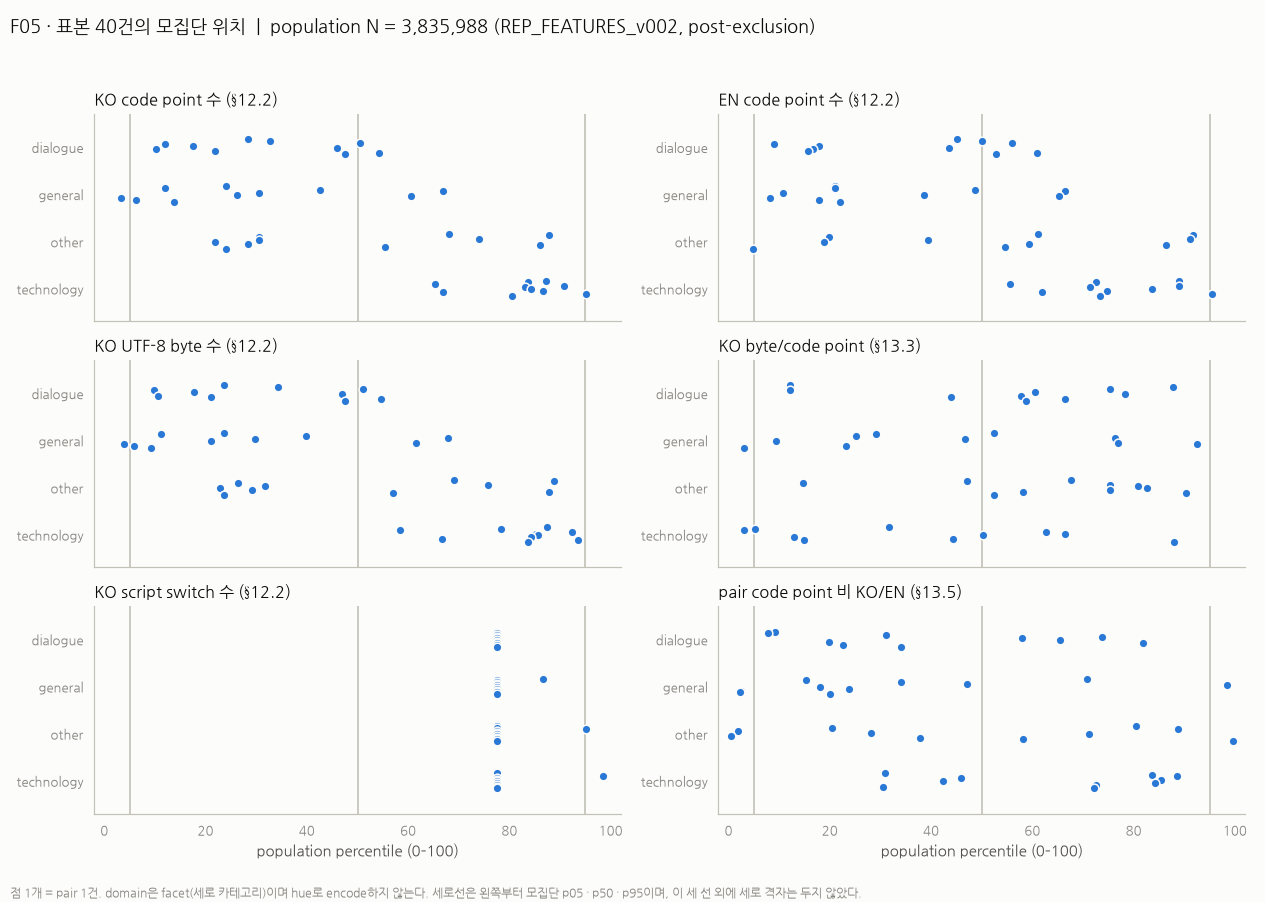

── table view: 표본 percentile (모든 값이 표로도 도달 가능) ──


ko_codepoint_count  en_codepoint_count  ko_utf8_bytes  \
domain     pair                                                              
dialogue   7770fa52                28.4                45.1           23.7   
           2c7f9e30                32.8                50.0           34.2   
           7b1980a7                50.4                56.0           51.0   
           75308f83                12.0                 9.0            9.9   
           74e68c7a                17.6                17.8           17.8   
           239048df                46.0                43.6           46.9   
           a5b8e0de                10.3                16.7           10.6   
           13cdbd63                21.8                15.7           21.0   
           e8aaaafa                54.2                60.9           54.7   
           a55fa6b9                47.5                52.9           47.5   
general    7393257b                24.0                21.0           23.7   
           1ee8a589                12.0                21.0           11.1   
           e5df6750                42.6                48.7           39.8   
           c18487e8                66.8                66.4           67.9   
           0579d4f4                30.6                10.8           29.8   
           d71c5e52                26.2                38.5           21.0   
           d6fd0abd                60.5                65.3           61.5   
           1936c8aa                 3.3                 8.2            3.9   
           4dc352bf                 6.3                17.8            5.8   
           7abbda16                13.7                22.1            9.2   
other      c8bebd0a                68.1                61.2           69.1   
           cfc8673e                87.8                91.8           88.9   
           011c9b9e                30.6                19.9           26.4   
           a17229cd                74.0                91.2           75.8   
           e0933a32                30.6                39.4           31.7   
           6d0597d9                21.8                18.8           22.8   
           a09e7c91                28.4                59.4           29.1   
           ac45ab19                86.1                86.3           87.8   
           68f40e0f                55.4                54.5           57.0   
           9dd42032                24.0                 4.9           23.7   
technology 3ed7c431                87.2                88.9           87.4   
           ff6c7e21                83.7                72.5           78.4   
           18b1f4f6                65.4                55.5           58.3   
           75b3171a                90.8                88.9           92.4   
           1725e594                83.1                71.4           85.2   
           ecbf40be                84.3                83.6           85.7   
           3f2419fb                86.7                74.7           84.2   
           c65a5d73                66.8                61.9           66.7   
           7688c93f                95.1                95.5           93.6   
           4faa1e5f                80.6                73.3           83.6   

                     ko_bytes_per_codepoint  ko_script_switch_count  \
domain     pair                                                       
dialogue   7770fa52                    12.2                    77.6   
           2c7f9e30                    87.8                    77.6   
           7b1980a7                    75.4                    77.6   
           75308f83                    12.2                    77.6   
           74e68c7a                    60.6                    77.6   
           239048df                    78.2                    77.6   
           a5b8e0de                    57.7                    77.6   
           13cdbd63                    43.9                    77.6   
           e8aaaafa               

In [12]:
# /**
#  * @cell 표본 40건의 모집단 percentile 위치를 feature별 panel, domain별 행으로 그린다.
#  * @ssot §16.1 핵심 분포; §16.3 extreme-case audit의 사전 좌표계
#  * @why 값 자체는 단위가 제각각이라 비교가 안 되지만 percentile은 공통 축이다. 색이 아니라
#  *      '위치'로 크기를 말하게 하면 hue 예산을 쓰지 않고도 6개 feature를 한 화면에 놓을 수 있다.
#  * @input PCT, POP_SUMMARY
#  * @output F05 figure (matplotlib), 표 형태의 table view
#  * @data_type 입력 PCT=DataFrame, 출력=Figure
#  * @target 표본이 모집단 분포의 중앙부인지 꼬리인지
#  * @controls domain = y축 카테고리(facet 역할), hue 사용 안 함
#  * @risk 점이 오른쪽에 있다고 '이상값'이 아니다. p99 밖이라는 사실과 오류라는 판단은 다르다.
#  */

if POP_MODE == "FULL_POPULATION":
    # @line 6개 feature를 3x2 격자에 놓아 한 화면에서 비교되게 한다.
    fig, axes = plt.subplots(3, 2, figsize=(11.5, 8.2), sharex=True)
    # @line 한글 라벨을 미리 지정해 축 제목이 코드 이름으로 노출되지 않게 한다.
    _labels = {
        "ko_codepoint_count":     "KO code point 수 (§12.2)",
        "en_codepoint_count":     "EN code point 수 (§12.2)",
        "ko_utf8_bytes":          "KO UTF-8 byte 수 (§12.2)",
        "ko_bytes_per_codepoint": "KO byte/code point (§13.3)",
        "ko_script_switch_count": "KO script switch 수 (§12.2)",
        "pair_codepoint_ratio":   "pair code point 비 KO/EN (§13.5)",
    }
    for ax, feat in zip(axes.ravel(), PCT_FEATURES):
        # @line p05/p50/p95를 세로 기준선으로 먼저 깔아 두면 점의 위치를 눈금 없이도 읽을 수 있다.
        # @line 격자선을 끄고 이 세 선만 남기면, 별도 라벨 없이도 '세로선 = p05/p50/p95'가 유일하게 읽힌다.
        #       라벨을 축 위에 얹으면 왼쪽 정렬 제목과 충돌하므로 각주로 옮겼다.
        for xv in (5, 50, 95):
            ax.axvline(xv, color=INK["baseline"], linewidth=MARK["hairline"] * 1.4, zorder=1)
        for yi, dom in enumerate(DOMAIN_ORDER):
            vals = PCT.loc[PCT.domain == dom, feat].to_numpy()
            # @line 같은 domain의 10점이 겹치지 않도록 아주 작은 결정론적 세로 흔들림만 준다.
            jitter = np.linspace(-0.16, 0.16, len(vals))
            # @line 단일 계열이므로 KO side 색(blue)만 쓰고 legend box를 두지 않는다(제목이 명명한다).
            ax.scatter(vals, np.full_like(vals, yi, dtype=float) + jitter,
                       s=MARK["marker"] ** 2 * 0.9, color=PALETTE["ko"],
                       edgecolor=INK["surface"], linewidth=MARK["ring"] / 2, zorder=3)
        # @line domain 순서를 모든 figure에서 동일하게 위→아래로 고정한다.
        domain_axis(ax)
        ax.set_xlim(-2, 102)
        ax.set_title(_labels[feat], loc="left", color=INK["primary"], pad=6)
        tidy(ax, xgrid=False, ygrid=False)
    # @line x축 라벨은 맨 아래 행에만 붙여 반복 잉크를 줄인다.
    for ax in axes[-1]:
        ax.set_xlabel("population percentile (0–100)")
    fig.suptitle(f"F05 · 표본 40건의 모집단 위치  |  population N = {POP_N:,} "
                 f"({REP_ARTIFACT_KEY}, post-exclusion)",
                 x=0.008, ha="left", fontsize=11.5, color=INK["primary"])
    fig.text(0.008, 0.006,
             "점 1개 = pair 1건. domain은 facet(세로 카테고리)이며 hue로 encode하지 않는다. "
             "세로선은 왼쪽부터 모집단 p05 · p50 · p95이며, 이 세 선 외에 세로 격자는 두지 않았다.",
             fontsize=8, color=INK["muted"])
    fig.tight_layout(rect=(0, 0.03, 1, 0.955))
    plt.show()

    # @line 색 대비 WARN에 대한 relief이자 skill의 table-view 요구를 동시에 충족하는 수치표다.
    print("── table view: 표본 percentile (모든 값이 표로도 도달 가능) ──")
    _tv = PCT.copy()
    _tv["pair"] = REP_SAMPLE.pair_id.str.slice(5, 13).to_numpy()
    display(_tv.set_index(["domain", "pair"])[PCT_FEATURES].round(1))
else:
    print("population 좌표계가 없으므로 F05를 생성하지 않는다.")

---

# 06 — Layer R · Representation Sample Diagnostics

## A. SSOT reference
§12.2 D-02 Representation Features; §13.3 Byte Density; §13.4 Whitespace Density;
§13.5 Pair Length Ratio; §16.2 F01 계보 (paired scatter / identity line).

## B. 통계적 의미
같은 의미를 담은 KO/EN 문자열이 **표면형 수준에서** 얼마나 다른지를 본다.
pair 내부 비교이므로 topic·의도는 pair matching으로 통제되어 있다 (§7.1).

$$\text{LengthRatio}_i = \log\frac{C_{i,\mathrm{KO}}}{C_{i,\mathrm{EN}}},\qquad
\text{BytesPerCodePoint}_{i,l} = \frac{B_{i,l}}{C_{i,l}}$$

## C. 데이터 타입
`PAIRED_COUNT` (A/B), `SIGNED_LOG_RATIO` (C), `COMPOSITION` (D).

## D. 축 의미
- **A/B (paired slope)**: x = 언어 side {EN, KO}(범주 2점), y = count (log10 축, 값의 배수 차이를 길이로 읽기 위함).
- **C (log-centered dot)**: x = $\log$ 비, **0 = KO와 EN이 같음**. 부호는 위치로만 표현한다.
- **D (script composition)**: x = share [0,1], y = script class 6종.

## E. Grouping / facet
모든 panel은 `domain`으로 facet한다. hue는 KO/EN에만 쓴다.

## F. 통제/문맥 변수
`length_stratum`은 x축 정렬이 아니라 표(cell 13)로 감사한다.

## G. 추론할 수 있는 것
- KO가 EN보다 code point가 적은지/많은지, byte는 어떤지 — **표본 40건 안에서의 관찰**.
- byte/code point가 KO에서 3.0에 근접하는지 (한글 완성형은 UTF-8에서 3 byte).

## H. 추론할 수 없는 것 (MUST NOT)
- domain 간 차이의 유의성 (domain당 $n=10$).
- 이 차이가 token 수 차이를 **일으킨다**는 인과 진술 (§MN-01).
- 표면형 구조만으로 tokenizer 압축을 설명했다는 주장 (그것은 layer T의 몫이며 §8 분해로만 분리된다).

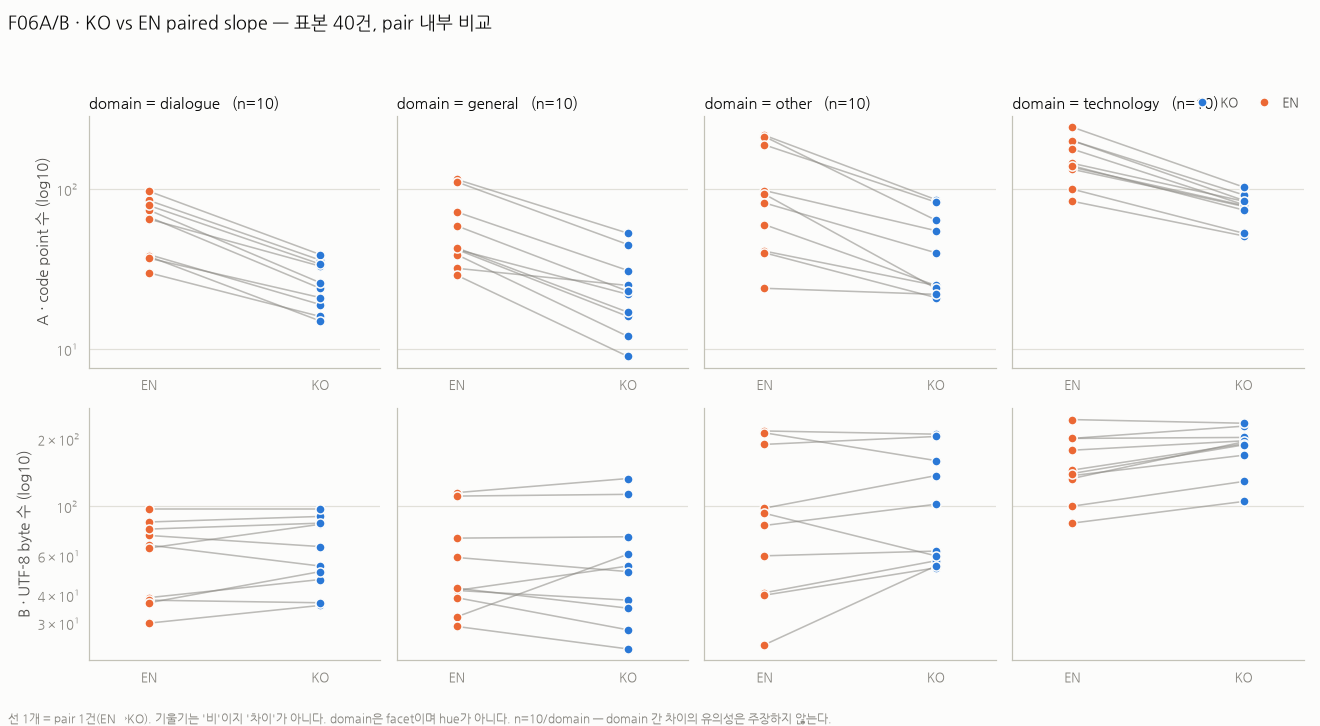

,KO codepoint(중앙값),EN codepoint,KO byte,EN byte
domain,,,,
dialogue,25.0,66.0,60.0,66.0
general,22.5,42.5,52.5,42.5
other,32.5,87.5,82.5,87.5
technology,79.5,142.5,192.0,142.5


In [13]:
# /**
#  * @cell 표본 40건의 KO vs EN paired slope(A: code point, B: UTF-8 byte)를 domain facet으로 그린다.
#  * @ssot §12.2 D-02; §16.2 F01 KO vs EN paired 계보
#  * @why 두 값을 나란한 bar로 그리면 pair 관계가 사라진다. 같은 pair를 선으로 이으면 '이 문장쌍에서'
#  *      KO가 늘었는지 줄었는지가 선의 기울기 하나로 읽히고, 40개의 개별 사례가 보존된다.
#  * @input REP_SAMPLE
#  * @output F06A/F06B figure
#  * @data_type 입력 PAIRED_COUNT(int) → 출력 Figure
#  * @target KO/EN 표면형 길이의 pair 내 비대칭
#  * @controls domain = facet
#  * @risk log10 축에서 선의 기울기는 '비'를 뜻하지 '차이'를 뜻하지 않는다. 절대 차이는 §13.2 별도 지표다.
#  */

def paired_slope(ax, df, ko_col: str, en_col: str, *, logy: bool = True) -> None:
    """
    /**
     * @purpose 같은 pair의 EN→KO 두 값을 선으로 잇는 slope plot을 한 axes에 그린다.
     * @spec_ref §16.2 F01 paired 계보; dataviz marks — 2px line, >=8px marker, surface ring
     * @param ax 대상 Axes
     * @param df domain 하나에 해당하는 표본 부분집합
     * @param ko_col KO side 열 이름
     * @param en_col EN side 열 이름
     * @param logy y축 log10 사용 여부
     * @return 없음
     * @raises 없음
     * @validation 선의 개수가 df 행수와 같은지, 끝점 색이 KO/EN 계약과 일치하는지 확인한다.
     */
    """
    for _, row in df.iterrows():
        # @line 연결선은 데이터 색을 입지 않는다. pair 소속만 나타내는 보조선이므로 muted 회색이다.
        ax.plot([0, 1], [row[en_col], row[ko_col]],
                color=INK["muted"], linewidth=MARK["hairline"] * 1.3, alpha=0.55, zorder=2)
    # @line 끝점만 계열 색으로 칠한다 — 색은 '어느 언어인가'라는 정체성 하나만 담당한다.
    ax.scatter(np.zeros(len(df)), df[en_col], s=MARK["marker"] ** 2, color=PALETTE["en"],
               edgecolor=INK["surface"], linewidth=MARK["ring"] / 2, zorder=3)
    ax.scatter(np.ones(len(df)), df[ko_col], s=MARK["marker"] ** 2, color=PALETTE["ko"],
               edgecolor=INK["surface"], linewidth=MARK["ring"] / 2, zorder=3)
    if logy:
        # @line 길이 분포는 오른쪽 꼬리가 길어 선형축에서는 짧은 문장들이 바닥에 뭉친다.
        ax.set_yscale("log")
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["EN", "KO"])
    ax.set_xlim(-0.35, 1.35)
    tidy(ax, xgrid=False, ygrid=True)


# @line A(code point)와 B(byte)를 위아래 두 행으로 배치해 같은 domain 열에서 바로 대조되게 한다.
fig, axes = plt.subplots(2, len(DOMAIN_ORDER), figsize=(3.0 * len(DOMAIN_ORDER), 6.6), sharey="row")
for j, dom in enumerate(DOMAIN_ORDER):
    sub = REP_SAMPLE[REP_SAMPLE.domain == dom]
    # @line 위 행 = A: code point 수 (§12.2 Unicode length).
    paired_slope(axes[0, j], sub, "ko_codepoint_count", "en_codepoint_count")
    axes[0, j].set_title(f"domain = {dom}   (n={len(sub)})", loc="left",
                         color=INK["primary"], fontsize=9.5, pad=5)
    # @line 아래 행 = B: UTF-8 byte 수 (§12.2 byte 변수군).
    paired_slope(axes[1, j], sub, "ko_utf8_bytes", "en_utf8_bytes")
# @line y축 라벨은 각 행의 첫 panel에만 붙여 반복을 없앤다.
axes[0, 0].set_ylabel("A · code point 수 (log10)")
axes[1, 0].set_ylabel("B · UTF-8 byte 수 (log10)")
# @line 계열이 2개이므로 legend는 항상 존재해야 한다(색만으로 정체성을 전달하지 않기 위함).
legend_keys(axes[0, -1], {"KO": PALETTE["ko"], "EN": PALETTE["en"]}, ncol=2, where="above")
fig.suptitle("F06A/B · KO vs EN paired slope — 표본 40건, pair 내부 비교",
             x=0.006, ha="left", fontsize=11.5, color=INK["primary"])
fig.text(0.006, 0.005,
         "선 1개 = pair 1건(EN→KO). 기울기는 '비'이지 '차이'가 아니다. domain은 facet이며 hue가 아니다. "
         "n=10/domain — domain 간 차이의 유의성은 주장하지 않는다.",
         fontsize=8, color=INK["muted"])
fig.tight_layout(rect=(0, 0.035, 1, 0.945))
plt.show()

# @line 그림이 말한 것을 수치로도 확인 가능하게 하는 table view(대비 WARN에 대한 relief 포함).
_tvA = REP_SAMPLE.groupby("domain")[["ko_codepoint_count", "en_codepoint_count",
                                     "ko_utf8_bytes", "en_utf8_bytes"]].median().round(1)
_tvA.columns = ["KO codepoint(중앙값)", "EN codepoint", "KO byte", "EN byte"]
display(_tvA)

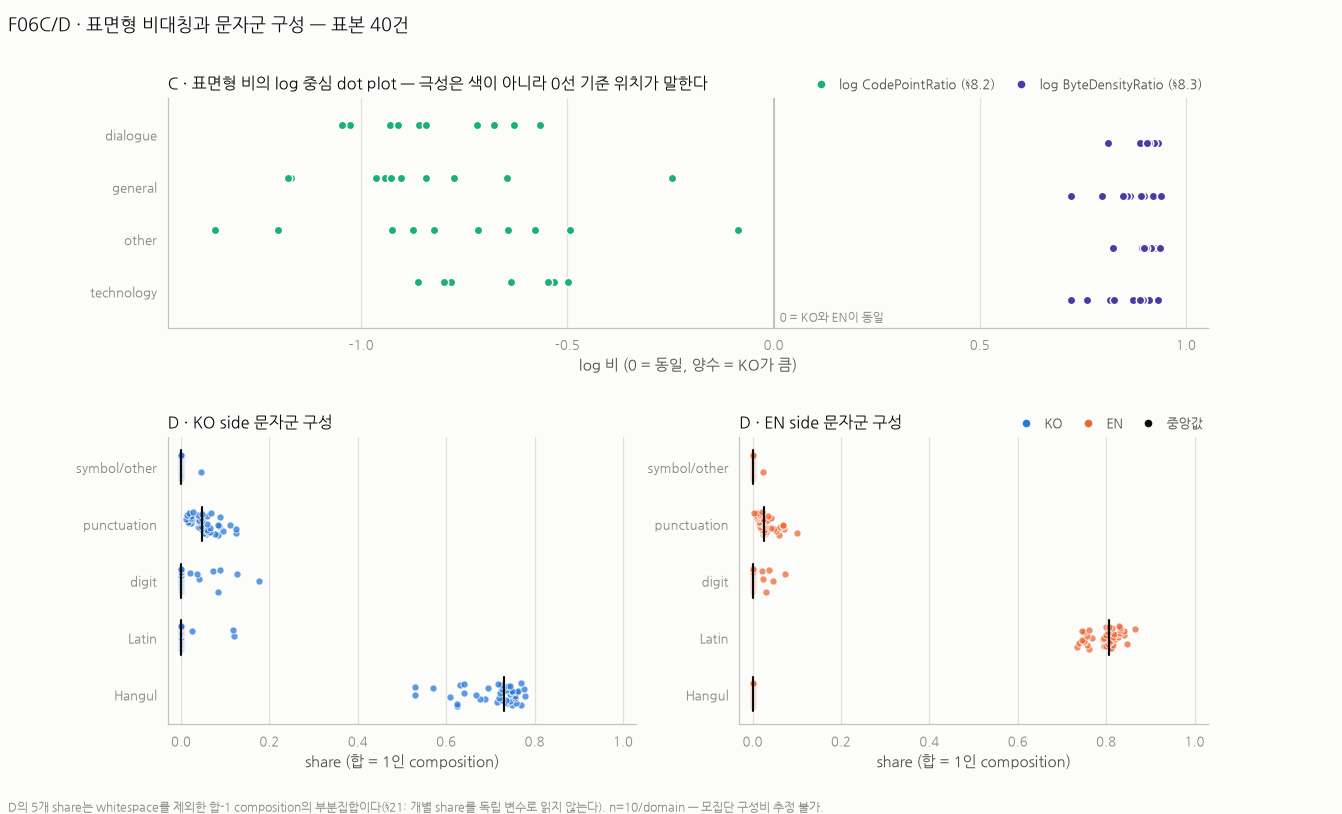

── table view: log 비 (표본 중앙값) ──


,log_codepoint_ratio,log_byte_density_ratio
domain,,
dialogue,-0.8511,0.9051
general,-0.9154,0.8785
other,-0.7704,0.9145
technology,-0.6362,0.8800


── table view: script share 중앙값 ──


,KO,EN
Hangul,0.7303,0.0000
Latin,0.0000,0.8061
digit,0.0000,0.0000
punctuation,0.0476,0.0252
symbol/other,0.0000,0.0000


In [14]:
# /**
#  * @cell C: 표면형 비를 log 중심 dot plot으로, D: KO/EN script 구성비를 대비 dot plot으로 그린다.
#  * @ssot §13.5 Pair Length Ratio; §13.3 Byte Density; §12.2 script 변수군
#  * @why 비(ratio)는 1을 중심으로 비대칭이라 선형축에서 왜곡된다. log를 취하면 0이 중립이 되고
#  *      "KO가 2배"와 "EN이 2배"가 같은 거리로 보인다. 극성은 색이 아니라 0선 기준 위치가 말한다.
#  * @input REP_SAMPLE
#  * @output F06C / F06D figure
#  * @data_type C=SIGNED_LOG_RATIO(float), D=COMPOSITION(share [0,1])
#  * @target C=길이/byte 밀도 비대칭, D=문자군 구성의 언어 간 차이
#  * @controls domain = facet
#  * @risk D의 6개 share는 합이 1인 composition이다. 개별 share를 독립 변수처럼 읽으면 안 된다(§21).
#  */

# @line log 비를 미리 계산해 둔다. accepted cohort는 분모가 0이 될 수 없으므로 smoothing을 넣지 않는다(§13.5).
REP_SAMPLE["log_codepoint_ratio"] = np.log(REP_SAMPLE.pair_codepoint_ratio)
# @line byte density 비는 (KO byte/cp) / (EN byte/cp)로, §8.3 ByteDensityRatio와 동일한 정의다.
REP_SAMPLE["log_byte_density_ratio"] = np.log(
    REP_SAMPLE.ko_bytes_per_codepoint / REP_SAMPLE.en_bytes_per_codepoint
)

# @line C와 D를 한 figure의 두 블록으로 배치해, 길이 비대칭과 문자군 구성을 한 화면에서 대조한다.
fig = plt.figure(figsize=(12.2, 7.4))
gs = fig.add_gridspec(2, 2, height_ratios=[1.0, 1.25], hspace=0.42, wspace=0.22)

# ── C: log-centered ratio dot plot ───────────────────────────────────
axC = fig.add_subplot(gs[0, :])
# @line 두 성분(길이 비, byte 밀도 비)은 decomposition family 색을 쓴다 — 이후 §8 분해와 의미가 이어진다.
_C_SERIES = [("log_codepoint_ratio", "log CodePointRatio (§8.2)", PALETTE["log_cr"]),
             ("log_byte_density_ratio", "log ByteDensityRatio (§8.3)", PALETTE["log_bdr"])]
for yi, dom in enumerate(DOMAIN_ORDER):
    sub = REP_SAMPLE[REP_SAMPLE.domain == dom]
    for k, (col, _lab, colr) in enumerate(_C_SERIES):
        # @line 두 성분을 같은 domain 행 안에서 위아래로 살짝 나눠 겹침을 없앤다(색 외 위치 보조부호).
        off = -0.17 + 0.34 * k
        ax_y = np.full(len(sub), yi + off, dtype=float)
        axC.scatter(sub[col], ax_y, s=MARK["marker"] ** 2 * 0.85, color=colr,
                    edgecolor=INK["surface"], linewidth=MARK["ring"] / 2, zorder=3)
# @line 0선은 'KO와 EN이 같다'는 의미의 기준선이므로 격자보다 진한 baseline 색을 쓴다.
axC.axvline(0.0, color=INK["baseline"], linewidth=MARK["hairline"] * 1.6, zorder=1)
axC.text(0.0, 0.02, "  0 = KO와 EN이 동일", transform=axC.get_xaxis_transform(),
         fontsize=8, color=INK["muted"], va="bottom")
domain_axis(axC)
axC.set_xlabel("log 비 (0 = 동일, 양수 = KO가 큼)")
axC.set_title("C · 표면형 비의 log 중심 dot plot — 극성은 색이 아니라 0선 기준 위치가 말한다",
              loc="left", color=INK["primary"], pad=6)
tidy(axC, xgrid=True, ygrid=False)
legend_keys(axC, {lab: c for _, lab, c in _C_SERIES}, ncol=2, where="above")

# ── D: script composition, KO vs EN ──────────────────────────────────
# @line 6개 문자군에 6개 hue를 쓰면 hue 예산을 초과한다. class는 y축 위치로, 언어만 색으로 표현한다.
_SCRIPT = [("hangul_share", "Hangul"), ("latin_share", "Latin"), ("digit_share", "digit"),
           ("punctuation_share", "punctuation"), ("symbol_other_share", "symbol/other")]
axD1 = fig.add_subplot(gs[1, 0])
axD2 = fig.add_subplot(gs[1, 1], sharex=axD1)
for ax, side, colr, title in ((axD1, "ko", PALETTE["ko"], "D · KO side 문자군 구성"),
                              (axD2, "en", PALETTE["en"], "D · EN side 문자군 구성")):
    for yi, (col, lab) in enumerate(_SCRIPT):
        vals = REP_SAMPLE[f"{side}_{col}"].to_numpy()
        # @line 40점을 결정론적 미세 흔들림으로 펼쳐, 0에 몰린 점들도 개수가 보이게 한다.
        jitter = np.linspace(-0.2, 0.2, len(vals))
        ax.scatter(vals, np.full_like(vals, yi, dtype=float) + jitter,
                   s=MARK["marker"] ** 2 * 0.6, color=colr, alpha=0.75,
                   edgecolor=INK["surface"], linewidth=MARK["ring"] / 3, zorder=3)
        # @line 중앙값에 짧은 세로 눈금을 얹어, 흩어진 점들의 대표값을 직접 읽게 한다.
        ax.plot([np.median(vals)] * 2, [yi - 0.3, yi + 0.3],
                color=INK["primary"], linewidth=MARK["line_w"] * 0.7, zorder=4)
    ax.set_yticks(range(len(_SCRIPT)))
    ax.set_yticklabels([lab for _, lab in _SCRIPT])
    ax.set_xlim(-0.03, 1.03)
    ax.set_xlabel("share (합 = 1인 composition)")
    ax.set_title(title, loc="left", color=INK["primary"], pad=6)
    tidy(ax, xgrid=True, ygrid=False)
# @line 두 panel이 서로 다른 계열(KO/EN)이므로 legend를 명시한다.
legend_keys(axD2, {"KO": PALETTE["ko"], "EN": PALETTE["en"], "중앙값": INK["primary"]},
            ncol=3, where="above")
fig.suptitle("F06C/D · 표면형 비대칭과 문자군 구성 — 표본 40건",
             x=0.006, ha="left", fontsize=11.5, color=INK["primary"])
fig.text(0.006, 0.004,
         "D의 5개 share는 whitespace를 제외한 합-1 composition의 부분집합이다(§21: 개별 share를 독립 변수로 읽지 않는다). "
         "n=10/domain — 모집단 구성비 추정 불가.",
         fontsize=8, color=INK["muted"])
plt.show()

# @line table view — log 비의 domain별 요약과 script share 중앙값을 수치로 남긴다.
print("── table view: log 비 (표본 중앙값) ──")
display(REP_SAMPLE.groupby("domain")[["log_codepoint_ratio", "log_byte_density_ratio"]].median().round(4))
print("── table view: script share 중앙값 ──")
display(pd.DataFrame({"KO": [REP_SAMPLE[f"ko_{c}"].median() for c, _ in _SCRIPT],
                      "EN": [REP_SAMPLE[f"en_{c}"].median() for c, _ in _SCRIPT]},
                     index=[lab for _, lab in _SCRIPT]).round(4))

---

# 07 — Layer M · Kiwi Morphology Sample Diagnostics

## A. SSOT reference
§12.3 D-03 Morphology Measurement; §13.6 Morpheme Density; §13.7 Particle / Ending Ratio;
§15.1–15.3 형태소 분석 고정 규약; §21 compositional feature 처리.

## B. 통계적 의미
Full `MORPH_FEATURES_v001.parquet`이 아직 없으므로 이 layer는 **표본 40건에 한해**
canonical `morphology_features()`로 재계산한다. 결과는 `SAMPLE_RECOMPUTED_FOR_VISUALIZATION`으로 표기한다.
나중에 full artifact가 생기면 **동일 pair_id로 join하여 equality check**할 수 있도록 값을 표로 남긴다.

$$\text{MorphemeDensity}_{i,\mathrm{KO}} = \frac{\text{MorphemeCount}_{i,\mathrm{KO}}}{\text{EojeolCount}_{i,\mathrm{KO}}},\qquad
\text{ParticleRatio}_{i} = \frac{\text{ParticleCount}_i}{\text{MorphemeCount}_i}$$

> **Upstream 라이브 변경 (본 notebook 작성 중 발생)**: canonical 구현이
> `RD-20260817-D02D03-CONFORMANCE-01`로 갱신되어 `morpheme_density` 분모가
> `ko_codepoint_count` → **`eojeol_count`(SSOT §13.6 준수)**로 바뀌었고,
> `morpheme_count = 0`일 때 morpheme_count 분모 ratio는 **`None`**(대체 분모 금지)이 되었으며
> `analysis_warning_flag`가 신설되었다.
>
> 다만 `src`는 `REP_FEATURES_v002`(= `ko_eojeol_count` / `en_word_count` 포함)를 요구하는데
> **디스크의 artifact는 아직 v001(47열)이다.** 이 lane에는 v002를 생성할 권한이 없으므로,
> 표본 40건에 한해 canonical `lexical_segment_count()`로 `ko_eojeol_count`를 재계산하고
> 그 사실을 `SAMPLE_RECOMPUTED_FOR_VISUALIZATION`으로 표기한다.
> 이 관측은 cell 02 `UPSTREAM_MIGRATION`과 cell 15 `src_module_sha256`에 기록된다.

## C. 데이터 타입
`morpheme_count`=COUNT, `morpheme_density`=PROPORTION*, particle/ending/deriv 비율=COMPOSITION.

## D. 축 의미
- 좌: x = morpheme density $=\text{MorphemeCount}/\text{EojeolCount}$, y = domain.
  단일 KO 측정치이므로 blue 단색·legend 없음.
- 우: x = 형태소 구성비 [0,1] 누적, y = 개별 pair (domain별 10건). **stacked = 합이 1**.

## E. Grouping / facet
`domain`. stacked bar는 domain 블록으로 묶어 배치한다.

## F. 통제/문맥 변수
`length_stratum`(짧은 문장일수록 형태소 수가 적어 비율이 불안정) — cell 13에서 감사한다.

## G. 추론할 수 있는 것
- 표본 40건에서 조사(J*)·어미(E*)·파생접사(XS*)가 형태소 중 차지하는 비중의 크기 순서.
- 형태소 분석 실패(morpheme_count = 0) 사례의 존재 여부.

## H. 추론할 수 없는 것 (MUST NOT)
- 형태소 비율이 token premium을 **일으킨다**는 진술 (§MN-01, §3.2 out of scope).
- 형태소 경계가 tokenizer token 경계와 대응한다는 진술 (§5.1).
- `function_morpheme_ratio`를 particle/ending과 같은 stacked에 동시 투입하는 것 (§12.3 / §21 금지).
- domain별 형태소 구성의 모집단 차이 (n=10).

In [15]:
# /**
#  * @cell 표본 40건의 KO 원문을 일시적으로 읽어 canonical Kiwi 함수로 형태소 feature를 재계산한다.
#  * @ssot §12.3 D-03; §13.6/§13.7; §15.1 Kiwi 0.23.2 / model 0.23.0 / custom dictionary 없음
#  * @why full artifact가 없으므로 population 계산 대신 40건만 재계산한다. 재구현하지 않고
#  *      NB04와 동일한 morphology_features()를 호출해야 나중 full artifact와 값이 일치할 수 있다.
#  * @input PAIR_REGISTRY_v002의 ko_text_analysis (일시 메모리 사용, 출력 금지)
#  * @output MORPH_SAMPLE(DataFrame 40행), MORPH_LAYER_STATUS(str)
#  * @data_type MORPH_SAMPLE=DataFrame[pair_id, ko_morpheme_count, ko_*_ratio, ...]
#  * @target KO 형태소 구조
#  * @controls domain(facet), length_stratum(문맥)
#  * @risk T-05 analyzer measurement error — 신조어/고유명사에서 분석기가 틀릴 수 있다.
#  *       그래서 analysis_warning 후보(morpheme_count=0)를 별도로 표시한다.
#  */

# @line 원문 텍스트는 계산에만 쓰고 절대 출력하지 않는다. 변수명에 _TRANSIENT를 붙여 의도를 못박는다.
with duck() as _con:
    _TRANSIENT_TEXT = _con.execute(f"""
        SELECT pair_id, ko_text_analysis, en_text_analysis
        FROM read_parquet('{_REG}') WHERE pair_id IN ({_ids_sql})
    """).df().set_index("pair_id")

# @line 40건 전부 텍스트를 얻었는지 확인한다(누락 시 layer M/T가 조용히 축소된다).
assert len(_TRANSIENT_TEXT) == len(SAMPLE_IDS), "STOP: 표본 텍스트 fetch 누락"
# @line accepted cohort는 empty가 있을 수 없다는 §10.1 전제를 실제로 검사한다.
assert (_TRANSIENT_TEXT.ko_text_analysis.str.len() > 0).all(), "STOP: KO empty text (§10.1 위반)"
assert (_TRANSIENT_TEXT.en_text_analysis.str.len() > 0).all(), "STOP: EN empty text (§10.1 위반)"

_t0 = time.time()
_rows = []
# @line morpheme_sequence는 원문 표면형을 그대로 담으므로 저장·출력 대상에서 제외한다(hygiene).
_DROP_KEYS = {"morpheme_sequence"}
for pid in SAMPLE_IDS:
    # @line KO 원문만 형태소 분석 대상이다(§15 morphology는 KO side 분석기다).
    ko_text = _TRANSIENT_TEXT.at[pid, "ko_text_analysis"]
    # @line SSOT §13.6의 density 분모는 EojeolCount다. artifact에 그 열이 있으면 그대로 쓰고,
    #       없을 때만 canonical lexical_segment_count()로 이 40건을 재계산한다(재구현하지 않는다).
    if UPSTREAM_MIGRATION["has_lexical_length"]:
        eojeol = int(REP_SAMPLE.loc[REP_SAMPLE.pair_id == pid, "ko_eojeol_count"].iloc[0])
    else:
        eojeol = lexical_segment_count(ko_text)
    # @line canonical 함수를 그대로 호출한다 — 재구현하면 full artifact와 값이 달라질 수 있다.
    feat = morphology_features(ko_text, eojeol_count=eojeol, kiwi=KIWI)
    _rows.append({"pair_id": pid, "ko_eojeol_count": eojeol,
                  **{f"ko_{k}": v for k, v in feat.items() if k not in _DROP_KEYS}})
MORPH_SAMPLE = pd.DataFrame(_rows)
print(f"morphology recompute (n={len(MORPH_SAMPLE)}): {time.time() - _t0:.2f}s")

# @line 표본 메타를 붙여 facet이 가능하게 하고, 행 순서를 SAMPLE 기준으로 고정한다.
MORPH_SAMPLE = SAMPLE[["pair_id", "domain", "length_stratum"]].merge(
    MORPH_SAMPLE, on="pair_id", how="left", validate="one_to_one")
# @line 새 계약에서 morpheme_count == 0 이면 ratio가 None이다(대체 분모 금지). NaN으로 보존한다.
for _c in ("ko_particle_ratio", "ko_ending_ratio", "ko_deriv_affix_ratio", "ko_function_morpheme_ratio"):
    MORPH_SAMPLE[_c] = pd.to_numeric(MORPH_SAMPLE[_c], errors="coerce")
# @line 조사/어미/파생접사에 속하지 않는 나머지 형태소 비율을 잔여로 계산해 stacked 합을 1로 만든다.
MORPH_SAMPLE["ko_other_ratio"] = (
    1.0 - MORPH_SAMPLE.ko_particle_ratio - MORPH_SAMPLE.ko_ending_ratio - MORPH_SAMPLE.ko_deriv_affix_ratio
)
# @line 부동소수 오차를 넘어서는 음수 잔여가 나오면 비율 정의가 어긋난 것이므로 검사한다(NaN은 정의상 제외).
assert (MORPH_SAMPLE.ko_other_ratio.dropna() >= -1e-9).all(), "STOP: 형태소 구성비 합이 1을 초과한다"

# @line full artifact가 없다는 사실을 결과에 명시적으로 붙여 나중 독자가 오해하지 않게 한다.
MORPH_LAYER_STATUS = ("SAMPLE_RECOMPUTED_FOR_VISUALIZATION"
                      if LAYER_STATE["M_morphology"] != "ARTIFACT_AVAILABLE" else "FROM_FULL_ARTIFACT")
# @line 분모의 출처(artifact join vs 표본 재계산)는 값의 신뢰 범위를 바꾸므로 따로 기록한다.
EOJEOL_SOURCE = ("REP_FEATURES artifact column" if UPSTREAM_MIGRATION["has_lexical_length"]
                 else "SAMPLE_RECOMPUTED via lexical_segment_count()")
print(f"MORPH_LAYER_STATUS = {MORPH_LAYER_STATUS}")
print(f"eojeol_count 출처   = {EOJEOL_SOURCE}")
# @line 분석 실패는 canonical analysis_warning_flag로 판정한다(내가 만든 기준을 쓰지 않는다).
_zero = int(MORPH_SAMPLE.ko_analysis_warning_flag.sum())
print(f"analysis_warning_flag = True 건수: {_zero}  (T-05 analyzer measurement error 후보)")
print(f"morpheme_density 분모  : {MORPHOLOGY_CONFIG['morpheme_density_denominator']} (SSOT §13.6)")
print(f"analyzer = Kiwi {ANALYZER_PACKAGE_VERSION} / model {ANALYZER_MODEL_VERSION} / custom dictionary NONE")

morphology recompute (n=40): 0.84s
MORPH_LAYER_STATUS = SAMPLE_RECOMPUTED_FOR_VISUALIZATION
eojeol_count 출처   = REP_FEATURES artifact column
analysis_warning_flag = True 건수: 0  (T-05 analyzer measurement error 후보)
morpheme_density 분모  : eojeol_count (SSOT §13.6)
analyzer = Kiwi 0.23.2 / model 0.23.0 / custom dictionary NONE


/tmp/ipykernel_65213/2289037964.py:78: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=(0, 0.115, 1, 0.945))


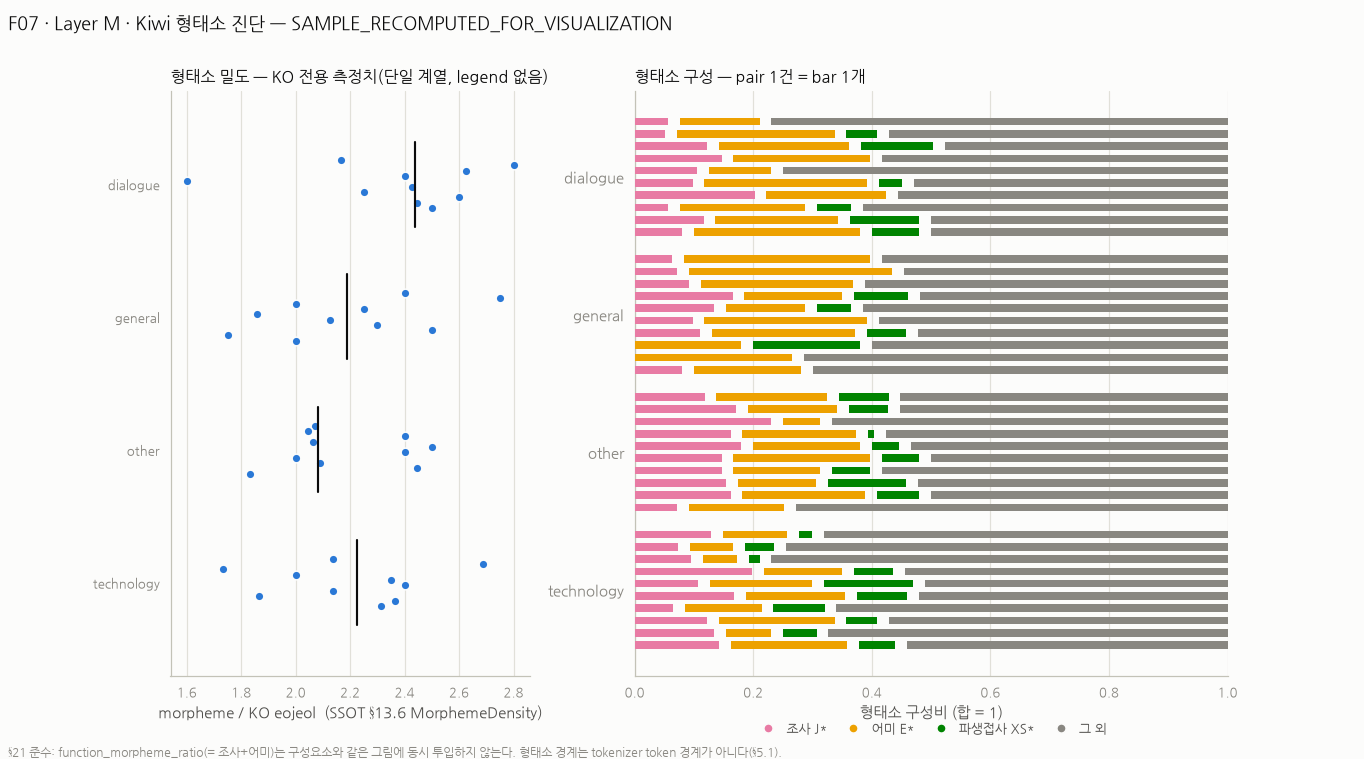

── table view: 형태소 feature (표본 중앙값) ──


,ko_eojeol_count,ko_morpheme_count,ko_morpheme_density,ko_particle_ratio,ko_ending_ratio,ko_deriv_affix_ratio,ko_function_morpheme_ratio
domain,,,,,,,
dialogue,5.5,13.5,2.4365,0.1213,0.2344,0.0651,0.3723
general,6.0,12.5,2.1875,0.1056,0.2693,0.0000,0.3796
other,7.5,18.5,2.0812,0.1779,0.1909,0.0833,0.3533
technology,20.0,46.5,2.2244,0.1459,0.1506,0.0790,0.2979


[관측] canonical morphology 구현이 SSOT §13.6대로 density 분모를 eojeol_count로 쓰고 있다 (현재 값: eojeol_count). 디스크의 REP_FEATURES는 아직 v001이라 이 열이 없으므로 40건만 canonical 함수로 재계산했다.


In [16]:
# /**
#  * @cell 형태소 밀도(좌)와 형태소 구성비 stacked bar(우)를 domain facet으로 그린다.
#  * @ssot §13.6 Morpheme Density; §13.7 Particle/Ending Ratio; §12.3 D-03
#  * @why 구성비는 합이 1인 composition이므로 stacked bar가 정확한 문법이다. 다만 세그먼트를
#  *      맞붙이면 경계가 사라지므로 표면색 2px 간격으로 분리한다(테두리 stroke를 그리지 않는다).
#  * @input MORPH_SAMPLE
#  * @output F07 figure + table view
#  * @data_type 좌=PROPORTION*, 우=COMPOSITION
#  * @target KO 형태소 구조의 pair별 구성
#  * @controls domain = facet / 블록 분리
#  * @risk stacked bar에서 가운데 세그먼트는 시작점이 달라 길이 비교가 어렵다.
#  *       그래서 각 성분의 값은 반드시 table view로도 제공한다.
#  */

fig = plt.figure(figsize=(12.4, 6.9))
gs = fig.add_gridspec(1, 2, width_ratios=[1.0, 1.65], wspace=0.22)

# ── 좌: morpheme density (KO 전용 단일 측정치 → blue 단색, legend 없음) ──
axL = fig.add_subplot(gs[0, 0])
for yi, dom in enumerate(DOMAIN_ORDER):
    vals = MORPH_SAMPLE.loc[MORPH_SAMPLE.domain == dom, "ko_morpheme_density"].to_numpy()
    jitter = np.linspace(-0.18, 0.18, len(vals))
    axL.scatter(vals, np.full_like(vals, yi, dtype=float) + jitter,
                s=MARK["marker"] ** 2 * 0.9, color=PALETTE["ko"],
                edgecolor=INK["surface"], linewidth=MARK["ring"] / 2, zorder=3)
    # @line 중앙값 눈금을 얹어 흩어진 점의 대표값을 즉시 읽게 한다(직접 label 대신 위치 부호).
    axL.plot([np.median(vals)] * 2, [yi - 0.32, yi + 0.32],
             color=INK["primary"], linewidth=MARK["line_w"] * 0.7, zorder=4)
domain_axis(axL)
axL.set_xlabel("morpheme / KO eojeol  (SSOT §13.6 MorphemeDensity)")
axL.set_title("형태소 밀도 — KO 전용 측정치(단일 계열, legend 없음)",
              loc="left", color=INK["primary"], pad=6)
tidy(axL, xgrid=True, ygrid=False)

# ── 우: 형태소 구성비 stacked bar, pair 단위 ──
axR = fig.add_subplot(gs[0, 1])
_COMP = [("ko_particle_ratio", "조사 J*", PALETTE["morph_particle"]),
         ("ko_ending_ratio", "어미 E*", PALETTE["morph_ending"]),
         ("ko_deriv_affix_ratio", "파생접사 XS*", PALETTE["morph_deriv"]),
         ("ko_other_ratio", "그 외", PALETTE["morph_other"])]
# @line domain 블록 사이에 빈 줄을 넣어 facet 경계를 공백으로 표현한다(구분선을 긋지 않는다).
_ypos, _ylabels, _yticks = [], [], []
_cursor = 0.0
for dom in DOMAIN_ORDER:
    sub = MORPH_SAMPLE[MORPH_SAMPLE.domain == dom].reset_index(drop=True)
    for _, row in sub.iterrows():
        left = 0.0
        for k, (col, _lab, colr) in enumerate(_COMP):
            w = float(row[col])
            # @line 형태소가 0개면 ratio가 정의되지 않는다(NaN). 0으로 대체하지 않고 세그먼트를 그리지 않는다.
            if not np.isfinite(w):
                continue
            # @line 세그먼트 사이 2px 상당의 표면색 간격을 폭에서 빼서 만든다(테두리 stroke 금지).
            draw_w = max(w - (MARK["gap"] if k < len(_COMP) - 1 and w > MARK["gap"] else 0.0), 0.0)
            axR.barh(_cursor, draw_w, left=left, height=MARK["bar_max"],
                     color=colr, edgecolor="none", zorder=3)
            left += w
        _ypos.append(_cursor)
        _cursor += 1.0
    # @line domain 라벨은 블록 중앙에 한 번만 둔다.
    _yticks.append(_cursor - len(sub) / 2 - 0.5)
    _ylabels.append(dom)
    _cursor += 1.2
axR.set_yticks(_yticks)
axR.set_yticklabels(_ylabels, fontsize=9.5)
axR.set_xlim(0, 1)
axR.invert_yaxis()
axR.set_xlabel("형태소 구성비 (합 = 1)")
axR.set_title("형태소 구성 — pair 1건 = bar 1개", loc="left", color=INK["primary"], pad=6)
tidy(axR, xgrid=True, ygrid=False)

fig.suptitle(f"F07 · Layer M · Kiwi 형태소 진단 — {MORPH_LAYER_STATUS}",
             x=0.006, ha="left", fontsize=11.5, color=INK["primary"])
fig.text(0.006, 0.004,
         "§21 준수: function_morpheme_ratio(= 조사+어미)는 구성요소와 같은 그림에 동시 투입하지 않는다. "
         "형태소 경계는 tokenizer token 경계가 아니다(§5.1).",
         fontsize=8, color=INK["muted"])
fig.tight_layout(rect=(0, 0.115, 1, 0.945))
# @line 이 panel의 제목이 길어 축 위에는 legend 자리가 없다. tight_layout 뒤에 x축 라벨 아래로 붙인다.
legend_keys(axR, {lab: c for _, lab, c in _COMP}, ncol=4, where="below")
plt.show()

# @line table view — stacked 중간 세그먼트의 길이 비교 어려움을 수치로 보완한다.
print("── table view: 형태소 feature (표본 중앙값) ──")
_tvM = MORPH_SAMPLE.groupby("domain")[
    ["ko_eojeol_count", "ko_morpheme_count", "ko_morpheme_density", "ko_particle_ratio",
     "ko_ending_ratio", "ko_deriv_affix_ratio", "ko_function_morpheme_ratio"]].median().round(4)
display(_tvM)
print("[관측] canonical morphology 구현이 SSOT §13.6대로 density 분모를 eojeol_count로 쓰고 있다 "
      f"(현재 값: {MORPHOLOGY_CONFIG['morpheme_density_denominator']}). "
      "디스크의 REP_FEATURES는 아직 v001이라 이 열이 없으므로 40건만 canonical 함수로 재계산했다.")

---

# 08 — Layer T · o200k_base Tokenizer Sample Diagnostics

## A. SSOT reference
§12.4 D-04 Token Measurement; §13.1 Token Premium; §14.1–14.2 Tokenizer 고정 규약;
§16.2 F01 (KO vs EN paired token scatter, identity line); §25.3–25.4 Track A 산출·성공 조건;
§31 G3 (roundtrip 100%).

## B. 통계적 의미
Track A 원칙대로 **chat template·special token 없이 `*_text_analysis` 문자열만** encode한다 (§14.2, §25.2).
Full `TOKEN_O200K_BASE_v001.parquet`이 없으므로 표본 40건만 canonical
`pair_token_measurement()`로 재계산하고 `SAMPLE_RECOMPUTED_FOR_VISUALIZATION`으로 표기한다.

$$TP_i = \frac{T_{i,\mathrm{KO}}}{T_{i,\mathrm{EN}}},\qquad
E_{i,l} = \frac{T_{i,l}}{B_{i,l}}\ (\text{tokens per byte})$$

## C. 데이터 타입
`T_KO/T_EN`=PAIRED_COUNT, `TP`=POSITIVE_RATIO, `logTP`=SIGNED_LOG_RATIO, `roundtrip_ok`=BINARY.

## D. 축 의미
- **좌 (F01 계보)**: x = $T_{EN}$, y = $T_{KO}$, 둘 다 log10. **대각선 = identity line**;
  선 위쪽 = KO가 token을 더 씀. 극성은 위치가 말한다.
- **우**: x = 언어 side, y = tokens/byte 및 tokens/code point (paired slope).

## E. Grouping / facet
`domain`.

## F. 통제/문맥 변수
`length_stratum` — 짧은 문장일수록 TP가 불안정하다.

## G. 추론할 수 있는 것
- 표본 40건에서 $T_{KO} > T_{EN}$ 인 건수.
- byte당 token 수의 언어 간 차이 (§8.4 CompressionPenalty의 원재료).
- roundtrip 100% 여부 (§31 G3 조건의 **증거**).

## H. 추론할 수 없는 것 (MUST NOT)
- $\theta_{TP} = \operatorname{Median}(\log TP) > 0$ 이라는 **추론** — 그것은 §17.1 signed-rank + bootstrap의 몫이며
  NB08의 권한이다. 여기서는 40건의 관찰만 보고한다.
- G3 PASS **판정** — 증거만 제시한다.
- o200k_base 결과의 다른 tokenizer로의 일반화 (§32 T-07).

In [17]:
# /**
#  * @cell 표본 40건에 o200k_base 측정을 적용하고 exact decomposition 항등식 오차를 함께 계산한다.
#  * @ssot §12.4 D-04; §14.2 측정 원칙(template/special token 없음, roundtrip 검증); §8 exact decomposition
#  * @why token 수는 결과변수의 원재료이므로 canonical 함수로만 만들어야 한다. 같은 함수가
#  *      identity 오차까지 돌려주므로 G2 numerical identity의 증거를 동시에 확보할 수 있다.
#  * @input _TRANSIENT_TEXT (일시), ENCODING
#  * @output TOK_SAMPLE(DataFrame 40행), TOK_LAYER_STATUS(str)
#  * @data_type TOK_SAMPLE=DataFrame[T_KO,T_EN,TP,logTP,logCodePointRatio,...,identity_abs_error,roundtrip_ok]
#  * @target tokenization burden / compression
#  * @controls domain(facet), length_stratum(문맥)
#  * @risk 40건의 roundtrip 100%는 모집단 100%를 뜻하지 않는다. §25.4 성공 조건은 accepted pair 전체가 대상이다.
#  */

_t0 = time.time()
_rows = []
for pid in SAMPLE_IDS:
    # @line Track A는 raw text만 encode한다 — chat template도 special token도 붙이지 않는다(§25.2).
    ko_text = _TRANSIENT_TEXT.at[pid, "ko_text_analysis"]
    en_text = _TRANSIENT_TEXT.at[pid, "en_text_analysis"]
    # @line canonical 측정 함수가 token 수·TP·3성분 log·identity 오차·roundtrip을 한 번에 돌려준다.
    _rows.append({"pair_id": pid, **pair_token_measurement(ko_text, en_text, encoding=ENCODING)})
TOK_SAMPLE = pd.DataFrame(_rows)
print(f"tokenizer measurement (n={len(TOK_SAMPLE)}): {time.time() - _t0:.2f}s")

# @line 표본 메타를 붙여 facet을 가능하게 한다.
TOK_SAMPLE = SAMPLE[["pair_id", "domain", "length_stratum", "translation_direction"]].merge(
    TOK_SAMPLE, on="pair_id", how="left", validate="one_to_one")
# @line byte/code point당 token은 §7.2 Descriptive 결과변수이므로 명시적으로 만들어 둔다.
_r = REP_SAMPLE.set_index("pair_id")
TOK_SAMPLE["ko_tokens_per_byte"] = TOK_SAMPLE.T_KO.to_numpy() / _r.loc[TOK_SAMPLE.pair_id, "ko_utf8_bytes"].to_numpy()
TOK_SAMPLE["en_tokens_per_byte"] = TOK_SAMPLE.T_EN.to_numpy() / _r.loc[TOK_SAMPLE.pair_id, "en_utf8_bytes"].to_numpy()
TOK_SAMPLE["ko_tokens_per_codepoint"] = TOK_SAMPLE.T_KO.to_numpy() / _r.loc[TOK_SAMPLE.pair_id, "ko_codepoint_count"].to_numpy()
TOK_SAMPLE["en_tokens_per_codepoint"] = TOK_SAMPLE.T_EN.to_numpy() / _r.loc[TOK_SAMPLE.pair_id, "en_codepoint_count"].to_numpy()

TOK_LAYER_STATUS = ("SAMPLE_RECOMPUTED_FOR_VISUALIZATION"
                    if LAYER_STATE["T_tokenizer"] != "ARTIFACT_AVAILABLE" else "FROM_FULL_ARTIFACT")

# @line G3 증거: roundtrip 실패가 하나라도 있으면 STOP 조건이므로 즉시 드러낸다.
_rt_fail = int((~TOK_SAMPLE.roundtrip_ok).sum())
# @line G2 증거: identity 오차의 최댓값이 epsilon 미만인지 확인한다(판정이 아니라 증거 제시다).
_max_err = float(TOK_SAMPLE.identity_abs_error.max())
print(f"TOK_LAYER_STATUS       = {TOK_LAYER_STATUS}")
print(f"roundtrip 실패 건수     = {_rt_fail} / {len(TOK_SAMPLE)}   (§31 G3 조건의 표본 증거)")
print(f"identity_abs_error max = {_max_err:.3e}  (epsilon = {EXACT_DECOMPOSITION_EPSILON:g}) "
      f"→ {'ε 미만' if _max_err < EXACT_DECOMPOSITION_EPSILON else 'ε 초과 — STOP 검토'}")
print(f"TP > 1 인 건수          = {int((TOK_SAMPLE.TP > 1).sum())} / {len(TOK_SAMPLE)}  "
      f"(표본 관찰 — §17.1 추론이 아니다)")
# @line 원문 텍스트를 더 이상 쓰지 않으므로 메모리에서 즉시 지워 hygiene 위험 창구를 닫는다.
del _TRANSIENT_TEXT
print("\n[hygiene] 원문 텍스트 임시 버퍼를 메모리에서 삭제했다. 이 notebook은 원문을 출력하지 않는다.")

tokenizer measurement (n=40): 0.00s
TOK_LAYER_STATUS       = SAMPLE_RECOMPUTED_FOR_VISUALIZATION
roundtrip 실패 건수     = 0 / 40   (§31 G3 조건의 표본 증거)
identity_abs_error max = 2.776e-16  (epsilon = 1e-10) → ε 미만
TP > 1 인 건수          = 33 / 40  (표본 관찰 — §17.1 추론이 아니다)

[hygiene] 원문 텍스트 임시 버퍼를 메모리에서 삭제했다. 이 notebook은 원문을 출력하지 않는다.


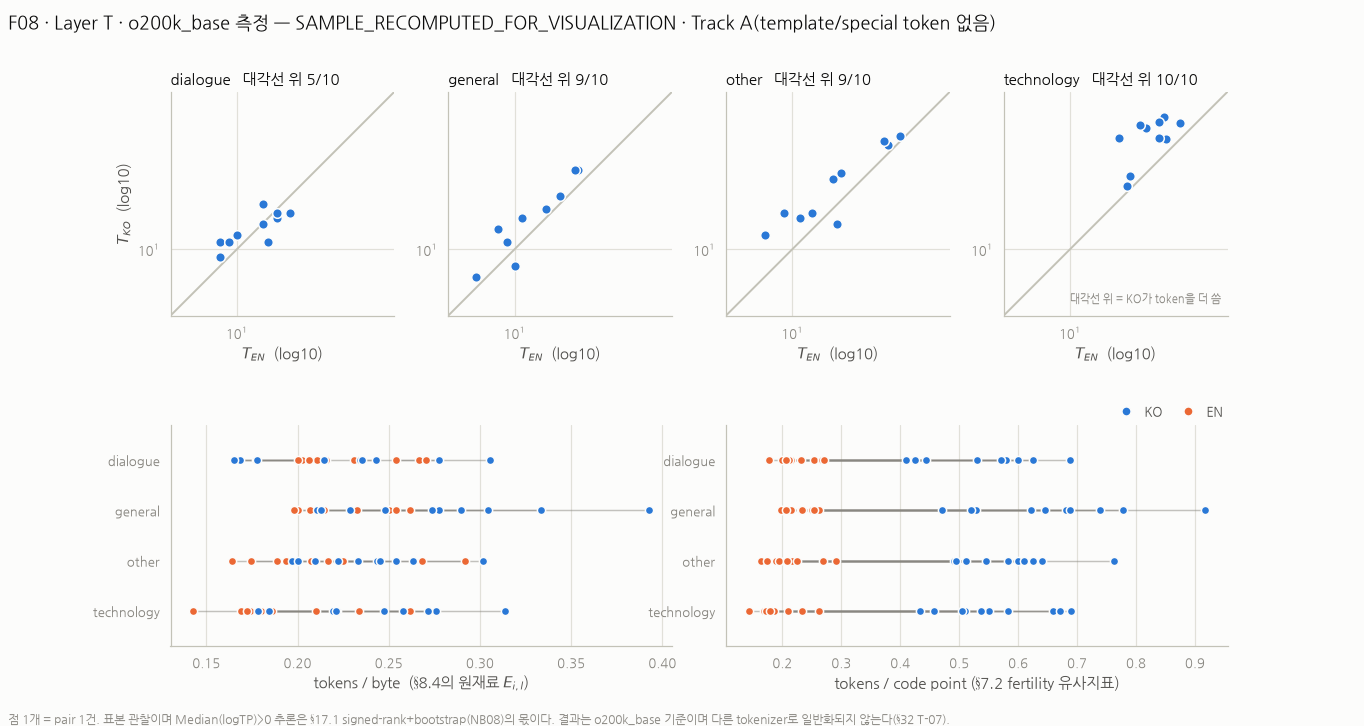

── table view: token 측정 (표본 중앙값) ──


,T_KO,T_EN,TP,logTP,ko_tokens_per_byte,en_tokens_per_byte
domain,,,,,,
dialogue,13.0,14.0,1.0625,0.0589,0.2242,0.2130
general,14.0,10.5,1.2198,0.1987,0.2759,0.2317
other,20.5,17.5,1.3030,0.2636,0.2385,0.2006
technology,46.0,29.5,1.4954,0.3972,0.2346,0.1792


In [18]:
# /**
#  * @cell F01 계보의 KO vs EN token paired scatter(identity line)와 tokens/byte·tokens/cp slope를 그린다.
#  * @ssot §16.2 F01; §12.4 D-04; §7.2 Descriptive 결과변수(tokens_per_byte / tokens_per_codepoint)
#  * @why identity line이 있는 paired scatter는 '어느 쪽이 큰가'를 색 없이 위치만으로 말한다.
#  *      점 하나가 pair 하나이므로 계열이 없고, 따라서 legend도 필요 없다.
#  * @input TOK_SAMPLE
#  * @output F08 figure + table view
#  * @data_type 좌=PAIRED_COUNT(log-log), 우=PROPORTION*(paired slope)
#  * @target tokenization burden의 pair 내 비대칭
#  * @controls domain = facet
#  * @risk 대각선 위라는 사실은 '이 pair에서 KO가 token을 더 썼다'는 관찰이지 모집단 진술이 아니다.
#  */

fig = plt.figure(figsize=(12.4, 6.6))
gs = fig.add_gridspec(2, len(DOMAIN_ORDER), height_ratios=[1.0, 0.95], hspace=0.46, wspace=0.24)

# ── 상단: domain별 KO vs EN token paired scatter + identity line ──
_lim_lo = float(min(TOK_SAMPLE.T_EN.min(), TOK_SAMPLE.T_KO.min())) * 0.7
_lim_hi = float(max(TOK_SAMPLE.T_EN.max(), TOK_SAMPLE.T_KO.max())) * 1.4
for j, dom in enumerate(DOMAIN_ORDER):
    ax = fig.add_subplot(gs[0, j])
    sub = TOK_SAMPLE[TOK_SAMPLE.domain == dom]
    # @line identity line을 데이터보다 먼저 깔아 기준선이 마크를 가리지 않게 한다.
    ax.plot([_lim_lo, _lim_hi], [_lim_lo, _lim_hi],
            color=INK["baseline"], linewidth=MARK["hairline"] * 1.6, zorder=1)
    # @line 점은 pair 1건 = 계열 없음 → 단일 색, legend 없음. 표면색 링으로 겹침을 분리한다.
    ax.scatter(sub.T_EN, sub.T_KO, s=MARK["marker"] ** 2 * 1.1, color=PALETTE["ko"],
               edgecolor=INK["surface"], linewidth=MARK["ring"] / 2, zorder=3)
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_xlim(_lim_lo, _lim_hi); ax.set_ylim(_lim_lo, _lim_hi)
    ax.set_aspect("equal", adjustable="box")
    # @line log 축 minor tick label은 서로 겹쳐 읽히지 않으므로 라벨만 제거한다.
    no_minor_tick_labels(ax)
    above = int((sub.T_KO > sub.T_EN).sum())
    # @line 선 위 건수만 직접 label한다 — 모든 점에 숫자를 붙이는 것은 anti-pattern이다.
    ax.set_title(f"{dom}   대각선 위 {above}/{len(sub)}", loc="left",
                 color=INK["primary"], fontsize=9.5, pad=5)
    if j == 0:
        ax.set_ylabel("$T_{KO}$  (log10)")
    ax.set_xlabel("$T_{EN}$  (log10)")
    tidy(ax, xgrid=True, ygrid=True)
    if j == len(DOMAIN_ORDER) - 1:
        # @line 대각선의 의미를 한 번만 주석으로 달아 색 없이도 극성이 읽히게 한다.
        ax.text(0.97, 0.06, "대각선 위 = KO가 token을 더 씀", transform=ax.transAxes,
                ha="right", fontsize=7.5, color=INK["muted"])

# ── 하단: tokens/byte, tokens/codepoint paired slope ──
for k, (kc, ec, lab) in enumerate([
        ("ko_tokens_per_byte", "en_tokens_per_byte", "tokens / byte  (§8.4의 원재료 $E_{i,l}$)"),
        ("ko_tokens_per_codepoint", "en_tokens_per_codepoint", "tokens / code point (§7.2 fertility 유사지표)")]):
    ax = fig.add_subplot(gs[1, k * 2:(k * 2 + 2)] if len(DOMAIN_ORDER) >= 4 else gs[1, k])
    for yi, dom in enumerate(DOMAIN_ORDER):
        sub = TOK_SAMPLE[TOK_SAMPLE.domain == dom]
        for _, row in sub.iterrows():
            # @line 같은 pair의 EN·KO 값을 가로선으로 이어 pair 관계를 보존한다.
            ax.plot([row[ec], row[kc]], [yi, yi], color=INK["muted"],
                    linewidth=MARK["hairline"] * 1.2, alpha=0.5, zorder=2)
        ax.scatter(sub[ec], np.full(len(sub), yi, dtype=float), s=MARK["marker"] ** 2 * 0.8,
                   color=PALETTE["en"], edgecolor=INK["surface"], linewidth=MARK["ring"] / 2, zorder=3)
        ax.scatter(sub[kc], np.full(len(sub), yi, dtype=float), s=MARK["marker"] ** 2 * 0.8,
                   color=PALETTE["ko"], edgecolor=INK["surface"], linewidth=MARK["ring"] / 2, zorder=3)
    domain_axis(ax)
    ax.set_xlabel(lab)
    tidy(ax, xgrid=True, ygrid=False)
    if k == 1:
        legend_keys(ax, {"KO": PALETTE["ko"], "EN": PALETTE["en"]}, ncol=2, where="above")

fig.suptitle(f"F08 · Layer T · o200k_base 측정 — {TOK_LAYER_STATUS} · Track A(template/special token 없음)",
             x=0.006, ha="left", fontsize=11.5, color=INK["primary"])
fig.text(0.006, 0.004,
         "점 1개 = pair 1건. 표본 관찰이며 Median(logTP)>0 추론은 §17.1 signed-rank+bootstrap(NB08)의 몫이다. "
         "결과는 o200k_base 기준이며 다른 tokenizer로 일반화되지 않는다(§32 T-07).",
         fontsize=8, color=INK["muted"])
plt.show()

print("── table view: token 측정 (표본 중앙값) ──")
display(TOK_SAMPLE.groupby("domain")[
    ["T_KO", "T_EN", "TP", "logTP", "ko_tokens_per_byte", "en_tokens_per_byte"]].median().round(4))

---

# 09 — Exact Decomposition (SSOT 중심식)

## A. SSOT reference
§8 Exact Decomposition; §8.1–8.4; §6.2 RQ2; Decision D-04 (*exact decomposition을 연구 중심식으로 승격*);
§31 G2 numerical identity; IR-01 (ByteDensityRatio와 CompressionPenalty를 분리 보고).

## B. 통계적 의미
SSOT의 정확한 가법 항등식:

$$\log TP_i \;=\; \log \mathrm{CodePointRatio}_i \;+\; \log \mathrm{ByteDensityRatio}_i \;+\; \log \mathrm{CompressionPenalty}_i$$

이것은 **추정식이 아니라 항등식**이다. 따라서 잔차가 없고, 각 성분의 기여를 **더하기**로 회계할 수 있다.
단순 stacked bar보다 **waterfall**을 우선하는 이유가 여기에 있다 — 누적 경로가 곧 회계 그 자체이기 때문이다.

G2 조건: $\;\big|\log TP_i - (\log CR_i + \log BDR_i + \log CP_i)\big| < \varepsilon,\ \varepsilon = 10^{-10}$

## C. 데이터 타입
세 성분 모두 `SIGNED_LOG_RATIO`. `identity_abs_error`는 PROPORTION* (0 이상).

## D. 축 의미
- **Waterfall**: x = 누적 $\log$ 기여, 0에서 출발해 세 성분을 차례로 더하고 최종 $\log TP$에 도달한다.
- **성분 dot matrix**: x = $\log$ 기여, y = pair. 0선 = 기여 없음.

## E. Grouping / facet
`domain`. 대표 case는 domain별 **$\log TP$ 중앙값 pair**(결정론적 선택).

## F. 통제/문맥 변수
없음 — 항등식은 문맥과 무관하게 성립한다.

## G. 추론할 수 있는 것
- 각 pair에서 premium의 **회계적** 출처 (표현 길이 / UTF-8 밀도 / tokenizer 압축).
- SSOT §33의 Case A(ByteDensity 주도) vs Case B(CompressionPenalty도 큼) 중 **표본이 어느 쪽으로 보이는지**.
- identity 오차가 $\varepsilon$ 미만인지 — G2 조건의 **증거**.

## H. 추론할 수 없는 것 (MUST NOT)
- 회계적 기여를 **인과 기여**로 읽는 것. 항등식은 정의이지 메커니즘이 아니다 (§32 T-06).
- G2 **PASS 판정** — 증거만 제시한다. 판정은 Claude-B/Gate steward의 권한이다.
- 40건의 성분 크기 순서를 모집단 순서로 일반화하는 것.

findfont: Failed to find font weight bold, now using 600.


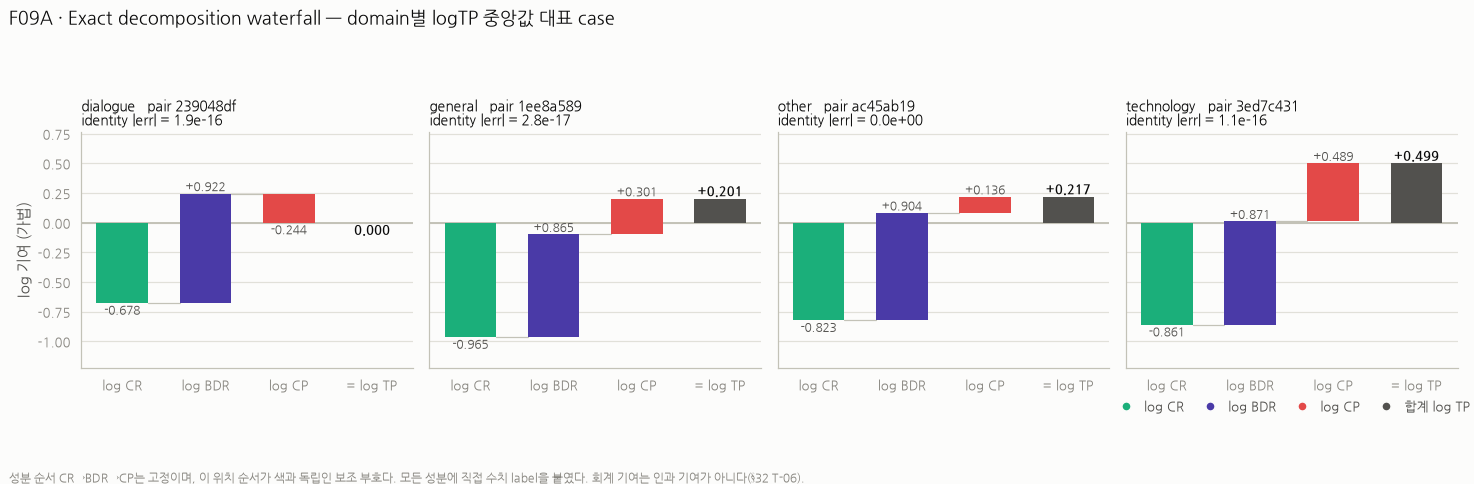

In [19]:
# /**
#  * @cell domain별 대표 case의 exact decomposition waterfall과 전체 40건의 성분 dot matrix를 그린다.
#  * @ssot §8.1~8.4 exact decomposition; D-04; §31 G2 numerical identity; IR-01
#  * @why 항등식은 '더해서 전체가 되는' 구조다. waterfall은 그 누적 경로를 그대로 그리므로
#  *      stacked bar보다 회계 구조를 정확히 전달한다. 세 성분은 항상 CR->BDR->CP 고정 순서로 놓아
#  *      위치 자체가 보조 부호가 되게 한다(CVD floor band 대응).
#  * @input TOK_SAMPLE
#  * @output F09 figure + identity 오차 보고
#  * @data_type SIGNED_LOG_RATIO 3성분 + 합계
#  * @target premium의 회계적 출처
#  * @controls domain = facet
#  * @risk 회계 기여 != 인과 기여 (§32 T-06). 성분끼리는 수학적으로 연결되어 있다.
#  */

# @line 성분 순서를 상수로 고정한다 — 이 순서가 CVD floor band에 대한 위치 기반 보조 부호다.
_COMPONENTS = [("logCodePointRatio", "log CodePointRatio\n(§8.2 표현 길이)", PALETTE["log_cr"]),
               ("logByteDensityRatio", "log ByteDensityRatio\n(§8.3 UTF-8 밀도)", PALETTE["log_bdr"]),
               ("logCompressionPenalty", "log CompressionPenalty\n(§8.4 tokenizer 압축)", PALETTE["log_cp"])]

# @line 대표 case는 domain별 logTP 중앙값에 가장 가까운 pair로 정한다 — 무작위가 아니라 결정론적이다.
_reps = []
for dom in DOMAIN_ORDER:
    sub = TOK_SAMPLE[TOK_SAMPLE.domain == dom]
    med = sub.logTP.median()
    # @line 중앙값과의 거리로 정렬하고 pair_id를 2차 키로 두어 동점에서도 선택이 유일하다.
    pick = sub.assign(_d=(sub.logTP - med).abs()).sort_values(["_d", "pair_id"]).iloc[0]
    _reps.append(pick)
REPRESENTATIVE = pd.DataFrame(_reps).reset_index(drop=True)

fig, axes = plt.subplots(1, len(DOMAIN_ORDER), figsize=(3.35 * len(DOMAIN_ORDER), 4.4), sharey=True)
axes = np.atleast_1d(axes)
# @line bar는 baseline에 sticky edge를 걸어 margins()를 무력화한다. 그래서 ylim을 직접 계산해 넣는다.
#       누적 경로의 모든 중간 지점이 막대 끝이 될 수 있으므로 부분합 전체에서 최소·최대를 찾는다.
_wf_levels = [0.0]
for _, _r in REPRESENTATIVE.iterrows():
    _c = 0.0
    for _col, _, _ in _COMPONENTS:
        _c += float(_r[_col])
        _wf_levels.append(_c)
_wf_lo, _wf_hi = min(_wf_levels), max(_wf_levels)
# @line 값 label이 막대 밖에 놓이므로, 위아래로 전체 범위의 18%씩 여백을 준다.
_wf_pad = (_wf_hi - _wf_lo) * 0.18
for j, (ax, (_, row)) in enumerate(zip(axes, REPRESENTATIVE.iterrows())):
    cum = 0.0
    for k, (col, _lab, colr) in enumerate(_COMPONENTS):
        v = float(row[col])
        # @line waterfall bar는 이전 누적값에서 시작해 성분 크기만큼 이동한다 — 이것이 가법 회계다.
        ax.bar(k, v, bottom=cum, width=MARK["bar_max"], color=colr, edgecolor="none", zorder=3)
        # @line 성분 값은 모두 직접 label한다(CVD floor band와 대비 WARN에 대한 필수 보조 부호).
        ax.text(k, cum + v + (0.008 if v >= 0 else -0.008), f"{v:+.3f}",
                ha="center", va="bottom" if v >= 0 else "top",
                fontsize=8, color=INK["secondary"])
        cum += v
        if k < len(_COMPONENTS) - 1:
            # @line 누적 연결선을 hairline으로 그어 bar 사이의 '이어짐'을 보이게 한다.
            ax.plot([k + MARK["bar_max"] / 2, k + 1 - MARK["bar_max"] / 2], [cum, cum],
                    color=INK["baseline"], linewidth=MARK["hairline"], zorder=2)
    # @line 마지막 막대는 합계(logTP)이며 계열 색이 아니라 primary ink로 칠해 '성분이 아님'을 표시한다.
    ax.bar(len(_COMPONENTS), cum, width=MARK["bar_max"], color=INK["secondary"],
           edgecolor="none", zorder=3)
    # @line 반올림 결과가 0인데 부호가 붙어 '-0.000'으로 보이는 것을 막는다.
    _cum_lab = "0.000" if abs(round(cum, 3)) == 0 else f"{cum:+.3f}"
    ax.text(len(_COMPONENTS), cum + (0.008 if cum >= 0 else -0.008), _cum_lab,
            ha="center", va="bottom" if cum >= 0 else "top", fontsize=8.5,
            color=INK["primary"], fontweight="bold")
    # @line 0선은 '기여 없음'의 기준이므로 baseline 색 hairline으로 항상 표시한다.
    ax.axhline(0.0, color=INK["baseline"], linewidth=MARK["hairline"] * 1.6, zorder=1)
    ax.set_xticks(range(len(_COMPONENTS) + 1))
    ax.set_xticklabels(["log CR", "log BDR", "log CP", "= log TP"], fontsize=8.5)
    ax.set_title(f"{row.domain}   pair {row.pair_id[5:13]}\nidentity |err| = {row.identity_abs_error:.1e}",
                 loc="left", color=INK["primary"], fontsize=9, pad=5)
    tidy(ax, xgrid=False, ygrid=True)
axes[0].set_ylabel("log 기여 (가법)")
axes[0].set_ylim(_wf_lo - _wf_pad, _wf_hi + _wf_pad)
fig.suptitle("F09A · Exact decomposition waterfall — domain별 logTP 중앙값 대표 case",
             x=0.006, ha="left", fontsize=11.5, color=INK["primary"])
fig.text(0.006, 0.005,
         "성분 순서 CR→BDR→CP는 고정이며, 이 위치 순서가 색과 독립인 보조 부호다. 모든 성분에 직접 수치 label을 붙였다. "
         "회계 기여는 인과 기여가 아니다(§32 T-06).",
         fontsize=8, color=INK["muted"])
fig.tight_layout(rect=(0, 0.155, 1, 0.90))
legend_keys(axes[-1], {"log CR": PALETTE["log_cr"], "log BDR": PALETTE["log_bdr"],
                       "log CP": PALETTE["log_cp"], "합계 log TP": INK["secondary"]},
            ncol=4, where="below")
plt.show()

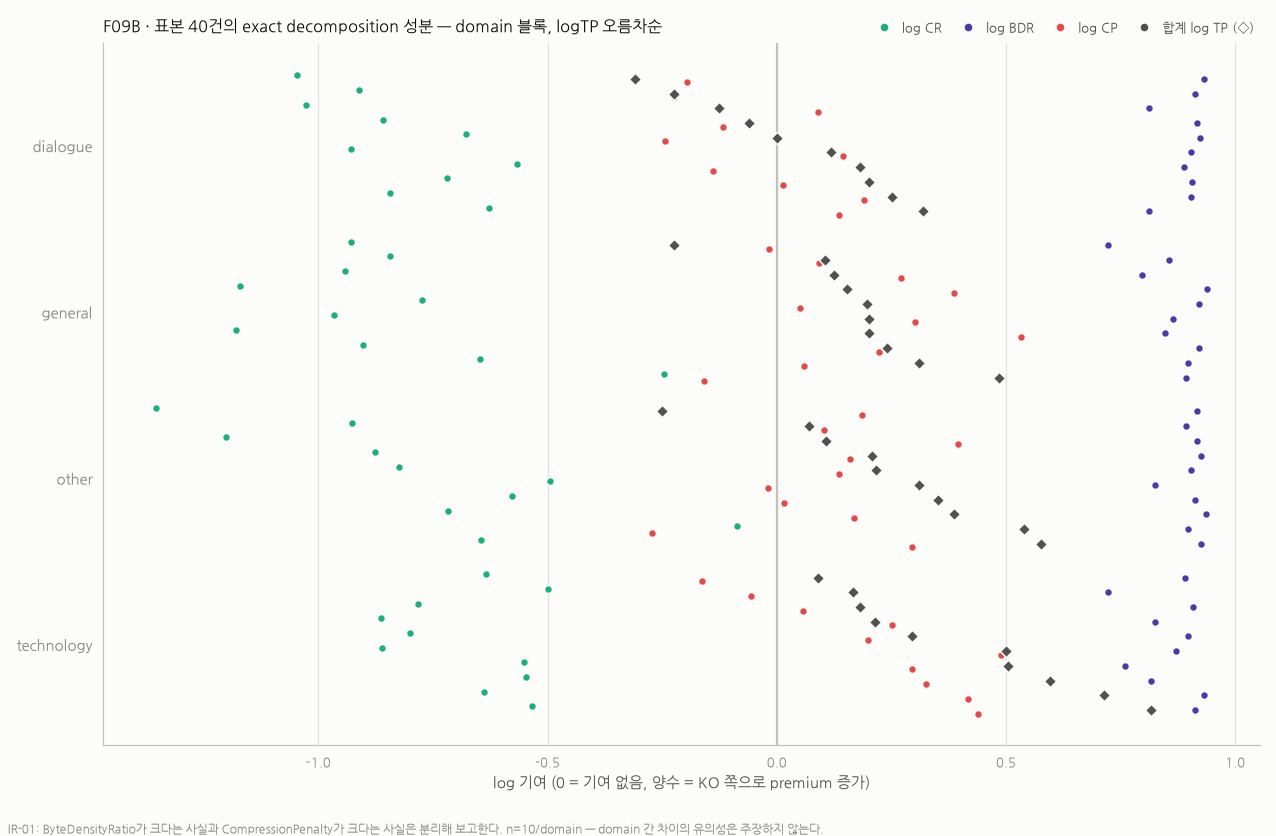

── §31 G2 numerical identity — 표본 증거 (판정 아님) ──


,identity_abs_error
max,2.776e-16
median,5.551e-17
min,0.000e+00


epsilon (D-RD-01) = 1e-10 → 표본 40건 전부 ε 미만: True

── §33 Case 프레임에 대한 표본 관찰 (결론 아님) ──
  logCodePointRatio        중앙값 -0.8113   (성분 중앙값 합 대비 -360.5%)
  logByteDensityRatio      중앙값 +0.9004   (성분 중앙값 합 대비 400.1%)
  logCompressionPenalty    중앙값 +0.1360   (성분 중앙값 합 대비  60.4%)
  → 위 값은 표본 40건의 중앙값이며, 모집단 분해 비중의 추정치가 아니다.


In [20]:
# /**
#  * @cell 40건 전체의 성분 기여를 dot matrix로 펼치고 identity 오차를 종합 보고한다.
#  * @ssot §8; §31 G2; §33 Case A/B 해석 프레임
#  * @why 대표 case 4개만으로는 표본 전체의 분포를 알 수 없다. 40건을 모두 같은 축에 놓아
#  *      어느 성분이 일관되게 크고 어느 성분이 부호를 바꾸는지 보이게 한다.
#  * @input TOK_SAMPLE
#  * @output F09B figure + identity 오차 표 + Case A/B 관찰
#  * @data_type SIGNED_LOG_RATIO
#  * @target 성분 기여의 표본 내 분포와 부호 안정성
#  * @controls domain = facet(세로 블록)
#  * @risk n=10/domain이므로 domain별 성분 크기 차이를 유의하다고 말할 수 없다(Directive §27).
#  */

fig, ax = plt.subplots(figsize=(11.6, 7.6))
_ycur, _yticks, _ylabels = 0.0, [], []
for dom in DOMAIN_ORDER:
    # @line domain 안에서 logTP 오름차순으로 정렬해 pair 순서가 의미를 갖게 한다(triptych와 동일 순서).
    sub = TOK_SAMPLE[TOK_SAMPLE.domain == dom].sort_values(["logTP", "pair_id"]).reset_index(drop=True)
    for _, row in sub.iterrows():
        for k, (col, _lab, colr) in enumerate(_COMPONENTS):
            # @line 세 성분을 같은 pair 행 안에서 미세하게 어긋나게 놓아 겹침을 위치로 해소한다.
            ax.scatter(row[col], _ycur + (-0.24 + 0.24 * k), s=MARK["marker"] ** 2 * 0.75,
                       color=colr, edgecolor=INK["surface"], linewidth=MARK["ring"] / 2, zorder=3)
        # @line 합계 logTP는 성분이 아니므로 색이 아니라 형태(다이아몬드)로 구분한다.
        ax.scatter(row.logTP, _ycur, s=MARK["marker"] ** 2 * 0.9, marker="D",
                   color=INK["secondary"], edgecolor=INK["surface"],
                   linewidth=MARK["ring"] / 2, zorder=4)
        _ycur += 1.0
    _yticks.append(_ycur - len(sub) / 2 - 0.5)
    _ylabels.append(dom)
    _ycur += 1.3
# @line 0선은 성분 기여의 부호가 뒤집히는 지점이므로 가장 중요한 기준선이다.
ax.axvline(0.0, color=INK["baseline"], linewidth=MARK["hairline"] * 1.8, zorder=1)
ax.set_yticks(_yticks); ax.set_yticklabels(_ylabels, fontsize=10)
ax.invert_yaxis()
ax.set_xlabel("log 기여 (0 = 기여 없음, 양수 = KO 쪽으로 premium 증가)")
ax.set_title("F09B · 표본 40건의 exact decomposition 성분 — domain 블록, logTP 오름차순",
             loc="left", color=INK["primary"], pad=8)
tidy(ax, xgrid=True, ygrid=False)
legend_keys(ax, {"log CR": PALETTE["log_cr"], "log BDR": PALETTE["log_bdr"],
                 "log CP": PALETTE["log_cp"], "합계 log TP (◇)": INK["secondary"]},
            ncol=4, where="above")
fig.text(0.006, 0.004,
         "IR-01: ByteDensityRatio가 크다는 사실과 CompressionPenalty가 크다는 사실은 분리해 보고한다. "
         "n=10/domain — domain 간 차이의 유의성은 주장하지 않는다.",
         fontsize=8, color=INK["muted"])
fig.tight_layout(rect=(0, 0.035, 1, 1))
plt.show()

# @line G2 증거를 수치로 정리한다. 판정이 아니라 증거 제시임을 문구로 명시한다.
print("── §31 G2 numerical identity — 표본 증거 (판정 아님) ──")
_id_tbl = pd.DataFrame({
    "identity_abs_error": [TOK_SAMPLE.identity_abs_error.max(),
                           TOK_SAMPLE.identity_abs_error.median(),
                           TOK_SAMPLE.identity_abs_error.min()]},
    index=["max", "median", "min"])
display(_id_tbl.map(lambda v: f"{v:.3e}"))
print(f"epsilon (D-RD-01) = {EXACT_DECOMPOSITION_EPSILON:g} → "
      f"표본 40건 전부 ε 미만: {bool((TOK_SAMPLE.identity_abs_error < EXACT_DECOMPOSITION_EPSILON).all())}")

# @line §33 해석 프레임의 어느 Case로 보이는지 '관찰'만 기록한다(결론 선언이 아니다).
_med = TOK_SAMPLE[[c for c, _, _ in _COMPONENTS]].median()
print("\n── §33 Case 프레임에 대한 표본 관찰 (결론 아님) ──")
for c, lab, _ in _COMPONENTS:
    share = _med[c] / _med.sum() * 100 if _med.sum() != 0 else float("nan")
    print(f"  {c:24s} 중앙값 {_med[c]:+.4f}   (성분 중앙값 합 대비 {share:5.1f}%)")
print("  → 위 값은 표본 40건의 중앙값이며, 모집단 분해 비중의 추정치가 아니다.")

---

# 10 — Three-Layer Domain Triptych (핵심 그림)

## A. SSOT reference
§5 / §5.1 핵심 구분 (형태소 ≠ regex chunk ≠ 최종 token); §12.2 / §12.3 / §12.4;
§16.2 F07 계보 (case audit panel); Directive §20.

## B. 통계적 의미
같은 40건을 **세 layer가 각자의 언어로** 설명한다. 세 panel은 pair 순서를 완전히 공유하므로,
어떤 pair가 R에서 특이하면 M·T에서도 같은 행을 보면 된다.

## C. 데이터 타입
R = PROPORTION* (byte/code point), M = COMPOSITION, T = SIGNED_LOG_RATIO.

## D. 축 의미
세 panel 모두 y = pair (domain 내 $\log TP$ 오름차순, **동일 순서**),
x는 각 layer의 고유 척도 — 공유하지 않는다.

## E. Grouping / facet
행 = domain, 열 = layer(R / M / T).

## F. 통제/문맥 변수
pair 정렬키가 $\log TP$이므로 T layer가 정렬을 주도한다. 이는 의도된 것이며 R·M의
패턴이 $\log TP$ 순서와 정렬되는지 보기 위함이다.

## G. 추론할 수 있는 것
- $\log TP$가 커지는 방향으로 R 또는 M의 어떤 양이 단조적으로 움직이는지 **눈으로** 확인.

## H. 추론할 수 없는 것 (MUST NOT — 이 그림의 가장 중요한 제약)

$$\boxed{\;\texttt{MORPHEME BOUNDARY} \;\neq\; \texttt{TOKENIZER REGEX CHUNK} \;\neq\; \texttt{FINAL TOKEN BOUNDARY}\;}$$

- 이 notebook에는 **regex chunk layer(D-05)가 없다.** 따라서 morpheme과 token을
  동일 boundary로 align했다고 표현할 수 없다.
- 세 layer를 하나의 segmentation처럼 **겹쳐 그리지 않는다.** panel은 항상 분리되어 있다.
- 시각적 동조(co-movement)는 상관도 아니고 인과는 더욱 아니다.

/tmp/ipykernel_65213/2068670552.py:108: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=(0, 0.085, 1, 0.955))


findfont: Failed to find font weight bold, now using 600.


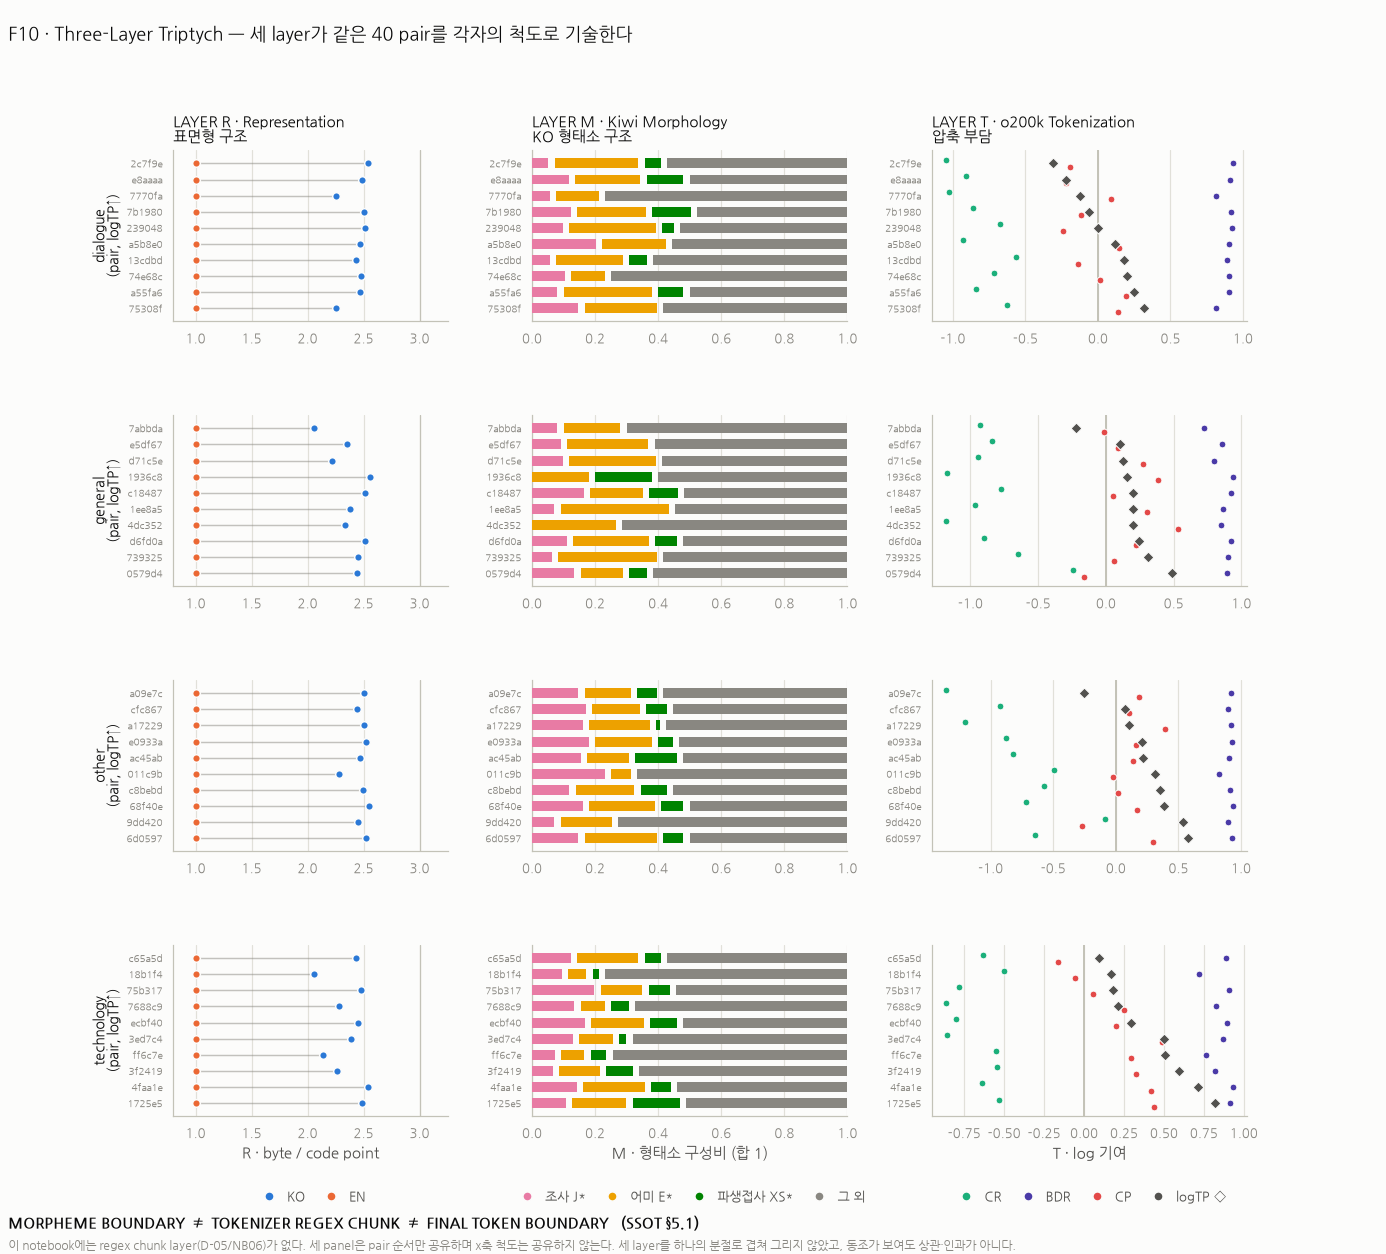

In [21]:
# /**
#  * @cell R/M/T 세 layer를 pair 순서를 공유하는 3열 panel로 배치한다(겹쳐 그리지 않는다).
#  * @ssot §5.1 핵심 구분; §16.2 F07 case audit panel 계보; Directive §20
#  * @why 세 layer를 한 축 위에 겹치면 '같은 분절'이라는 잘못된 인상을 준다. 축을 분리하고
#  *      pair 순서만 공유하면, 동조 여부는 볼 수 있으면서 boundary 동일성은 주장하지 않게 된다.
#  * @input REP_SAMPLE, MORPH_SAMPLE, TOK_SAMPLE
#  * @output F10 figure (domain 수 x 3 panel)
#  * @data_type R=PROPORTION*, M=COMPOSITION, T=SIGNED_LOG_RATIO
#  * @target 세 layer가 같은 pair를 어떻게 다르게 기술하는가
#  * @controls pair 정렬 = domain 내 logTP 오름차순 (세 panel 공유)
#  * @risk 세 panel의 x축은 서로 다른 척도다. 가로 위치를 layer 간에 비교하면 안 된다.
#  */

# @line 세 layer를 pair_id로 하나의 폭 넓은 표로 합친다 — 정렬을 한 곳에서만 결정하기 위함이다.
TRI = (SAMPLE[["pair_id", "domain", "length_stratum", "translation_direction"]]
       .merge(REP_SAMPLE[["pair_id", "ko_bytes_per_codepoint", "en_bytes_per_codepoint"]],
              on="pair_id", validate="one_to_one")
       .merge(MORPH_SAMPLE[["pair_id", "ko_particle_ratio", "ko_ending_ratio",
                            "ko_deriv_affix_ratio", "ko_other_ratio", "ko_morpheme_density"]],
              on="pair_id", validate="one_to_one")
       .merge(TOK_SAMPLE[["pair_id", "logTP", "logCodePointRatio", "logByteDensityRatio",
                          "logCompressionPenalty", "ko_tokens_per_byte", "en_tokens_per_byte"]],
              on="pair_id", validate="one_to_one"))

_nd = len(DOMAIN_ORDER)
fig, axes = plt.subplots(_nd, 3, figsize=(12.6, 2.35 * _nd + 2.0),
                         gridspec_kw={"width_ratios": [1.0, 1.15, 1.15], "hspace": 0.55, "wspace": 0.28})
axes = np.atleast_2d(axes)
for i, dom in enumerate(DOMAIN_ORDER):
    # @line 정렬은 여기서 딱 한 번만 결정하고 세 panel이 같은 sub를 쓴다 — 순서 공유의 유일한 보장 방법이다.
    sub = TRI[TRI.domain == dom].sort_values(["logTP", "pair_id"]).reset_index(drop=True)
    y = np.arange(len(sub))

    # ── LEFT · Layer R: KO/EN byte per code point ──
    axR = axes[i, 0]
    for yy, row in zip(y, sub.itertuples()):
        # @line pair 관계를 보존하는 연결선은 muted 회색이며 데이터 색을 입지 않는다.
        axR.plot([row.en_bytes_per_codepoint, row.ko_bytes_per_codepoint], [yy, yy],
                 color=INK["muted"], linewidth=MARK["hairline"] * 1.2, alpha=0.5, zorder=2)
    axR.scatter(sub.en_bytes_per_codepoint, y, s=MARK["marker"] ** 2 * 0.7, color=PALETTE["en"],
                edgecolor=INK["surface"], linewidth=MARK["ring"] / 2, zorder=3)
    axR.scatter(sub.ko_bytes_per_codepoint, y, s=MARK["marker"] ** 2 * 0.7, color=PALETTE["ko"],
                edgecolor=INK["surface"], linewidth=MARK["ring"] / 2, zorder=3)
    axR.set_xlim(0.8, 3.25)
    # @line 완성형 한글의 UTF-8 크기 3.0을 참조선으로 두면 KO 값의 의미가 즉시 읽힌다.
    axR.axvline(3.0, color=INK["baseline"], linewidth=MARK["hairline"], zorder=1)
    axR.set_ylabel(f"{dom}\n(pair, logTP↑)", fontsize=9, color=INK["primary"])

    # ── MIDDLE · Layer M: 형태소 구성 stacked ──
    axM = axes[i, 1]
    for yy, row in zip(y, sub.itertuples()):
        left = 0.0
        for k, (col, _lab, colr) in enumerate(_COMP):
            w = float(getattr(row, col))
            # @line 형태소 0개 pair는 ratio가 NaN이므로 세그먼트를 건너뛴다(0으로 대체하지 않는다).
            if not np.isfinite(w):
                continue
            # @line stacked 세그먼트는 표면색 간격으로 분리한다(테두리 stroke를 그리지 않는다).
            draw_w = max(w - (MARK["gap"] if k < len(_COMP) - 1 and w > MARK["gap"] else 0.0), 0.0)
            axM.barh(yy, draw_w, left=left, height=MARK["bar_max"], color=colr,
                     edgecolor="none", zorder=3)
            left += w
    axM.set_xlim(0, 1)

    # ── RIGHT · Layer T: exact decomposition 성분 + logTP ──
    axT = axes[i, 2]
    for yy, row in zip(y, sub.itertuples()):
        for k, (col, _lab, colr) in enumerate(_COMPONENTS):
            axT.scatter(getattr(row, col), yy + (-0.22 + 0.22 * k), s=MARK["marker"] ** 2 * 0.55,
                        color=colr, edgecolor=INK["surface"], linewidth=MARK["ring"] / 3, zorder=3)
        axT.scatter(row.logTP, yy, s=MARK["marker"] ** 2 * 0.7, marker="D", color=INK["secondary"],
                    edgecolor=INK["surface"], linewidth=MARK["ring"] / 3, zorder=4)
    axT.axvline(0.0, color=INK["baseline"], linewidth=MARK["hairline"] * 1.6, zorder=1)

    for ax in (axR, axM, axT):
        ax.set_yticks(y)
        ax.set_yticklabels([p[5:11] for p in sub.pair_id], fontsize=6.5)
        ax.set_ylim(-0.8, len(sub) - 0.2)
        ax.invert_yaxis()
        tidy(ax, xgrid=True, ygrid=False)
    # @line 축 라벨은 마지막 행에만 붙여 반복 잉크를 없앤다.
    if i == _nd - 1:
        axR.set_xlabel("R · byte / code point")
        axM.set_xlabel("M · 형태소 구성비 (합 1)")
        axT.set_xlabel("T · log 기여")
    # @line layer 제목은 첫 행에만 둔다.
    if i == 0:
        axR.set_title("LAYER R · Representation\n표면형 구조", loc="left", fontsize=9.5,
                      color=INK["primary"], pad=6)
        axM.set_title("LAYER M · Kiwi Morphology\nKO 형태소 구조", loc="left", fontsize=9.5,
                      color=INK["primary"], pad=6)
        axT.set_title("LAYER T · o200k Tokenization\n압축 부담", loc="left", fontsize=9.5,
                      color=INK["primary"], pad=6)
    # @line 마지막 행의 axes 3개를 기억해 두었다가 tight_layout 뒤에 그 아래로 legend를 붙인다.
    if i == _nd - 1:
        _last_row_axes = (axR, axM, axT)

fig.suptitle("F10 · Three-Layer Triptych — 세 layer가 같은 40 pair를 각자의 척도로 기술한다",
             x=0.006, ha="left", fontsize=12, color=INK["primary"])
# @line SSOT §5.1의 불변 경고를 figure 자체에 새겨, 그림만 잘라 써도 경고가 따라가게 한다.
fig.text(0.006, 0.021,
         "MORPHEME BOUNDARY  ≠  TOKENIZER REGEX CHUNK  ≠  FINAL TOKEN BOUNDARY   (SSOT §5.1)",
         fontsize=9.5, color=INK["primary"], fontweight="bold")
fig.text(0.006, 0.004,
         "이 notebook에는 regex chunk layer(D-05/NB06)가 없다. 세 panel은 pair 순서만 공유하며 x축 척도는 공유하지 않는다. "
         "세 layer를 하나의 분절로 겹쳐 그리지 않았고, 동조가 보여도 상관·인과가 아니다.",
         fontsize=8, color=INK["muted"])
fig.tight_layout(rect=(0, 0.085, 1, 0.955))
# @line legend는 각 layer 열의 x축 라벨 바로 아래에 둔다 — 축 안에 두면 반드시 stacked bar를 가린다.
legend_keys(_last_row_axes[0], {"KO": PALETTE["ko"], "EN": PALETTE["en"]}, ncol=2, where="below")
legend_keys(_last_row_axes[1], {lab: c for _, lab, c in _COMP}, ncol=4, where="below")
legend_keys(_last_row_axes[2], {"CR": PALETTE["log_cr"], "BDR": PALETTE["log_bdr"],
                                "CP": PALETTE["log_cp"], "logTP ◇": INK["secondary"]},
            ncol=4, where="below")
plt.show()

---

# 11 — Similarity / Concordance (rank 기반, descriptive only)

## A. SSOT reference
§6.4 RQ4 (형태소 feature의 증분 설명력 — **여기서 검정하지 않는다**);
§21 공선성 및 compositional feature 처리; §29 다중 검정; §32 T-06 deterministic feature overlap;
Directive §22.

## B. 통계적 의미
Spearman **rank** concordance만 계산한다. Pearson이 아닌 이유는 비율·count 변수의
분포가 치우쳐 있고 $n=40$ 이라 선형성 가정이 위험하기 때문이다.

$$\rho_s = \operatorname{corr}\big(\operatorname{rank}(x),\ \operatorname{rank}(y)\big)$$

**semantic similarity는 계산하지 않는다** (Directive §22 금지, §3.2 out of scope).
여기서 말하는 similarity는 오직 *rank concordance*다.

## C. 데이터 타입
입력은 SIGNED_LOG_RATIO / PROPORTION* / COMPOSITION. 출력 $\rho_s \in [-1, 1]$ 은 극성이 있는 척도 → **diverging**.

## D. 축 의미
- 행 = 결과 쪽 수량 ($\log TP$, $\log CP$), 열 = 설명 쪽 수량.
- 색 = diverging scale (음: blue ↔ 중립 gray ↔ 양: red). **모든 cell에 수치를 병기**하므로
  색이 값을 게이트하지 않는다.

## E. Grouping / facet
없음 — overall sample($n=40$) 기준 하나의 행렬. domain별 $n=10$ 결과는 표로만, DESCRIPTIVE ONLY.

## F. 통제/문맥 변수
**통제하지 않는다.** 이것은 회귀가 아니라 단순 rank 일치도다. 그래서 §6.4의 "통제 후 증분 설명력"
질문에는 답할 수 없다.

## G. 추론할 수 있는 것
- 어떤 feature 쌍이 표본에서 **순위상 함께 움직이는지**.
- §32 T-06이 경고한 결정론적 중복 (예: $\log CR$ 와 $\log TP$ 는 항등식으로 연결되어 있으므로 높은 $\rho$가 당연하다).

## H. 추론할 수 없는 것 (MUST NOT)
- p-value 중심 해석 (§17.3 p-value 단독 보고 금지; Directive §22).
- 증분 설명력 (그것은 M2 − M1 비교이며 NB09의 권한).
- 인과 · semantic similarity · model understanding.
- domain별 $n=10$ 상관을 domain 차이의 증거로 쓰는 것.

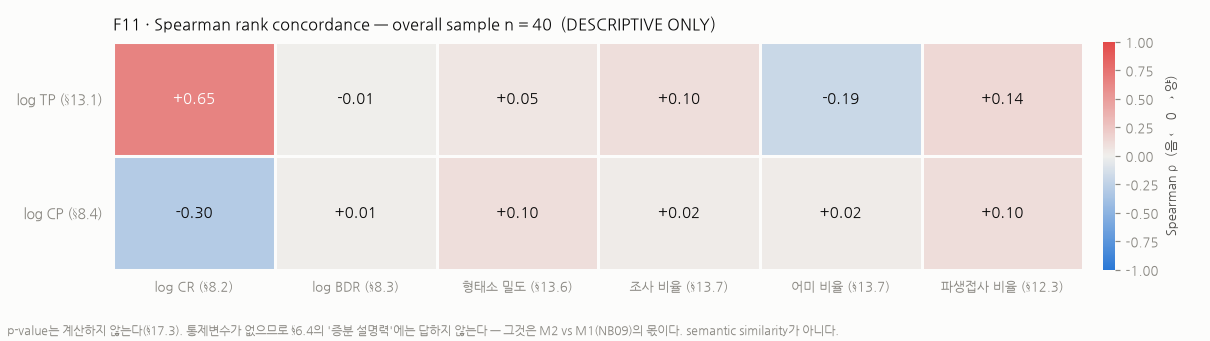

── table view ──


,log CR (§8.2),log BDR (§8.3),형태소 밀도 (§13.6),조사 비율 (§13.7),어미 비율 (§13.7),파생접사 비율 (§12.3)
log TP (§13.1),0.647,-0.007,0.054,0.098,-0.192,0.135
log CP (§8.4),-0.301,0.013,0.099,0.020,0.022,0.104



[§32 T-06] logCR·logBDR와 logTP는 exact decomposition 항등식으로 결정론적으로 연결되어 있다. 따라서 이 두 열의 높은 |ρ|는 발견이 아니라 정의의 귀결이다.

── domain별 ρ(logTP, 형태소 밀도) — n=10, DESCRIPTIVE ONLY, 유의성 주장 불가 ──
  {'dialogue': -0.345, 'general': 0.104, 'other': 0.286, 'technology': 0.541}


In [22]:
# /**
#  * @cell logTP/logCP 대 표면형·형태소 수량의 Spearman rank concordance를 계산하고 행렬로 표시한다.
#  * @ssot §6.4 RQ4(여기서는 검정하지 않음); §21; §32 T-06; Directive §22
#  * @why 상관은 극성이 있는 척도이므로 diverging 색이 정확한 문법이다. 다만 40건짜리 표본이므로
#  *      모든 cell에 수치를 병기해 색이 값을 대신하지 않게 하고, p-value는 계산조차 하지 않는다.
#  * @input TRI (세 layer 결합표)
#  * @output F11 figure + CONCORDANCE(DataFrame)
#  * @data_type 입력 혼합, 출력 rho in [-1,1]
#  * @target 순위 수준의 동조 관계
#  * @controls 없음 (통제하지 않으므로 증분 설명력을 말할 수 없다)
#  * @risk logCR/logBDR와 logTP는 항등식으로 연결되어 있어 높은 rho가 구조적으로 당연하다(T-06).
#  */

from scipy import stats  # noqa: E402  # @line Spearman 계산에만 사용한다.

# @line 결과 쪽(행)과 설명 쪽(열)을 명시적으로 나눠, 행렬이 대칭 상관표로 오독되지 않게 한다.
_OUTCOMES = [("logTP", "log TP (§13.1)"), ("logCompressionPenalty", "log CP (§8.4)")]
_EXPLAIN = [("logCodePointRatio", "log CR (§8.2)"),
            ("logByteDensityRatio", "log BDR (§8.3)"),
            ("ko_morpheme_density", "형태소 밀도 (§13.6)"),
            ("ko_particle_ratio", "조사 비율 (§13.7)"),
            ("ko_ending_ratio", "어미 비율 (§13.7)"),
            ("ko_deriv_affix_ratio", "파생접사 비율 (§12.3)")]

# @line rho만 저장한다 — p-value를 저장하지 않는 것 자체가 §17.3 준수를 코드로 강제하는 방법이다.
_mat = np.zeros((len(_OUTCOMES), len(_EXPLAIN)))
for i, (oc, _) in enumerate(_OUTCOMES):
    for j, (ec, _) in enumerate(_EXPLAIN):
        _mat[i, j] = stats.spearmanr(TRI[oc], TRI[ec]).statistic
CONCORDANCE = pd.DataFrame(_mat, index=[lab for _, lab in _OUTCOMES],
                           columns=[lab for _, lab in _EXPLAIN])

# @line diverging colormap을 documented 극(blue↔red)과 중립 gray 중점으로 직접 구성한다.
from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm  # noqa: E402
_DIVERGING = LinearSegmentedColormap.from_list(
    "koen_div", [PALETTE["ko"], "#f0efec", PALETTE["log_cp"]], N=256)
# @line 0을 반드시 중립색에 고정해야 '중점이 아무것도 아님'이라는 diverging의 전제가 지켜진다.
_norm = TwoSlopeNorm(vmin=-1.0, vcenter=0.0, vmax=1.0)

fig, ax = plt.subplots(figsize=(11.0, 3.1))
im = ax.imshow(CONCORDANCE.to_numpy(), cmap=_DIVERGING, norm=_norm, aspect="auto")
ax.set_xticks(range(len(_EXPLAIN))); ax.set_xticklabels(CONCORDANCE.columns, fontsize=8.5, rotation=0)
ax.set_yticks(range(len(_OUTCOMES))); ax.set_yticklabels(CONCORDANCE.index, fontsize=9)
for i in range(CONCORDANCE.shape[0]):
    for j in range(CONCORDANCE.shape[1]):
        v = CONCORDANCE.iat[i, j]
        # @line cell 안의 글자색은 배경 명도로 정해 항상 대비를 확보한다(색만으로 값을 전달하지 않기 위함).
        ax.text(j, i, f"{v:+.2f}", ha="center", va="center", fontsize=9.5,
                color="#ffffff" if abs(v) > 0.55 else INK["primary"])
# @line 격자를 끄고 cell 경계는 표면색 얇은 선으로만 만들어 heatmap이 조용하게 읽히게 한다.
ax.set_xticks(np.arange(-0.5, len(_EXPLAIN), 1), minor=True)
ax.set_yticks(np.arange(-0.5, len(_OUTCOMES), 1), minor=True)
ax.grid(which="minor", color=INK["surface"], linewidth=2.0)
ax.grid(which="major", visible=False)
ax.tick_params(which="minor", length=0)
for s in ax.spines.values():
    s.set_visible(False)
cb = fig.colorbar(im, ax=ax, fraction=0.022, pad=0.02)
cb.set_label("Spearman ρ  (음 ← 0 → 양)", fontsize=8.5, color=INK["secondary"])
cb.outline.set_visible(False)
ax.set_title(f"F11 · Spearman rank concordance — overall sample n = {len(TRI)}  (DESCRIPTIVE ONLY)",
             loc="left", color=INK["primary"], pad=8)
fig.text(0.006, 0.02,
         "p-value는 계산하지 않는다(§17.3). 통제변수가 없으므로 §6.4의 '증분 설명력'에는 답하지 않는다 — 그것은 M2 vs M1(NB09)의 몫이다. "
         "semantic similarity가 아니다.",
         fontsize=8, color=INK["muted"])
fig.tight_layout(rect=(0, 0.09, 0.99, 1))
plt.show()

print("── table view ──")
display(CONCORDANCE.round(3))
print("\n[§32 T-06] logCR·logBDR와 logTP는 exact decomposition 항등식으로 결정론적으로 연결되어 있다. "
      "따라서 이 두 열의 높은 |ρ|는 발견이 아니라 정의의 귀결이다.")

# @line domain별 결과는 n=10이므로 표로만 남기고 그림으로 강조하지 않는다(과잉해석 방지).
print("\n── domain별 ρ(logTP, 형태소 밀도) — n=10, DESCRIPTIVE ONLY, 유의성 주장 불가 ──")
_by_dom = {dom: round(float(stats.spearmanr(g.logTP, g.ko_morpheme_density).statistic), 3)
           for dom, g in TRI.groupby("domain")}
print(f"  {_by_dom}")

---

# 12 — Outlier / Boundary Casebook & Morphology Composition Divergence

## A. SSOT reference
§16.3 Extreme-case audit (**극단값은 먼저 삭제하지 않는다**); §10.1 hard exclusion; §10.2 soft flags;
§31 G2 / G3; §32 T-05; Directive §23 / §26.

## B. 통계적 의미

**(1) 형태소 구성 divergence.** domain별 표본 평균 구성벡터
$q_d = (\text{particle},\text{ending},\text{deriv},\text{other})$ 사이의 Jensen–Shannon divergence:

$$\mathrm{JSD}(P\Vert Q) = \tfrac12 D_{KL}(P\Vert M) + \tfrac12 D_{KL}(Q\Vert M),\quad M = \tfrac12(P+Q)$$

$\mathrm{JSD}$는 대칭이고 유계($\log 2$ 이하, base-2에서는 1 이하)라서 composition 비교에 적합하다.
4개 domain → **6개 쌍**뿐이므로 heatmap 대신 정렬된 dot plot + 표로 제시한다
(7개 이상 색 계급은 anti-pattern이며, 6개 값은 표가 더 정확하다).

**(2) Extreme-case rubric.** Directive §26의 5단계로 40건을 분류한다.

| 등급 | 판정 근거 (이 notebook이 실제로 검사하는 것) |
|---|---|
| `HARD_INVALID` | roundtrip 실패 **또는** identity 오차 ≥ $\varepsilon$ |
| `MEASUREMENT_WARNING` | `morpheme_count = 0` (T-05 analyzer 오류 후보) |
| `SUSPICIOUS` | D-01 soft flag 점등 (`unicode_anomaly` / `markup_dominant` / `control_char_excess` 등) |
| `PLAUSIBLE_EXTREME` | 핵심 feature 중 하나 이상이 모집단 p01 미만 또는 p99 초과 |
| `EXPECTED` | 위 어디에도 해당하지 않음 |

**등급이 낮다는 이유로 어떤 pair도 제거하지 않는다** (§16.3).

## C. 데이터 타입
JSD = PROPORTION [0,1]. rubric = ORDINAL(심각도 순) → **status 색** (categorical과 절대 섞지 않으며 항상 라벨 병기).

## D. 축 의미
- JSD: x = divergence(0 = 동일 구성), y = domain 쌍.
- rubric: x = 건수, y = 등급.

## E. Grouping / facet
JSD는 domain 쌍이 단위. rubric은 전체 40건 + domain별 교차표.

## F. 통제/문맥 변수
`length_stratum` (극단 등급이 길이 극단에 몰리는지 확인).

## G. 추론할 수 있는 것
- 표본 수준에서 어떤 domain 쌍의 형태소 구성이 서로 먼지.
- 어떤 pair가 후속 audit 대상인지.

## H. 추론할 수 없는 것 (MUST NOT)
- **SAMPLE-ONLY, N=10/domain, NO POPULATION INFERENCE** — JSD는 모집단 domain 차이의 추정치가 아니다.
- rubric 등급은 QC 판정이 아니다. 이 notebook은 새 QC/exclusion을 만들 권한이 없다.
- `PLAUSIBLE_EXTREME`은 오류가 아니다 (§16.3: valid extreme은 분석에 유지한다).

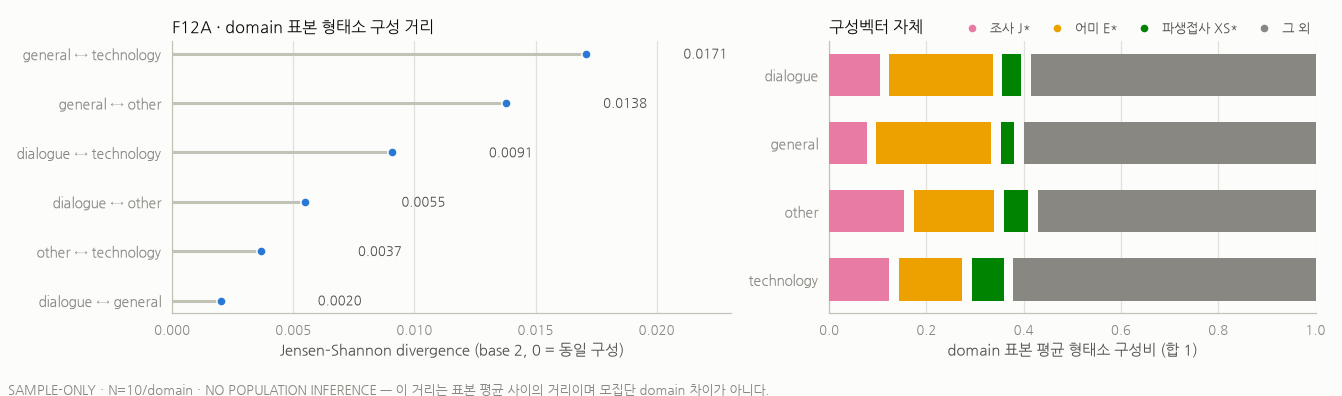

,domain_A,domain_B,JSD_base2
0,dialogue,general,0.00201
1,other,technology,0.00367
2,dialogue,other,0.00546
3,dialogue,technology,0.00907
4,general,other,0.01379
5,general,technology,0.01710


In [23]:
# /**
#  * @cell domain별 형태소 구성벡터의 Jensen-Shannon divergence를 계산하고 6개 쌍을 dot plot으로 그린다.
#  * @ssot §12.3 D-03; Directive §23 morphology composition similarity
#  * @why 구성벡터 간 거리는 유클리드가 아니라 확률분포 거리로 재는 것이 옳다. JSD는 대칭이고
#  *      유계이므로 "얼마나 다른가"를 0-1로 말할 수 있다. 쌍이 6개뿐이라 heatmap보다 표가 정확하다.
#  * @input MORPH_SAMPLE
#  * @output F12A figure + JSD 표
#  * @data_type 입력 COMPOSITION, 출력 PROPORTION [0,1]
#  * @target domain 표본 간 형태소 구성 거리
#  * @controls 없음
#  * @risk SAMPLE-ONLY. n=10 평균 구성벡터의 거리이며 모집단 domain 차이가 아니다.
#  */

from itertools import combinations  # noqa: E402  # @line domain 쌍 열거에만 사용한다.

# @line 각 domain의 표본 평균 구성벡터를 만든다 — 이것이 JSD의 입력 분포다.
_COMP_COLS = ["ko_particle_ratio", "ko_ending_ratio", "ko_deriv_affix_ratio", "ko_other_ratio"]
# @line ratio가 NaN인 pair(형태소 0개)는 구성벡터 평균에서 제외한다 — 0으로 채우면 구성을 왜곡한다.
COMP_VEC = MORPH_SAMPLE.dropna(subset=_COMP_COLS).groupby("domain")[_COMP_COLS].mean()
# @line 부동소수 오차로 합이 정확히 1이 아닐 수 있으므로 정규화해 확률분포 조건을 보장한다.
COMP_VEC = COMP_VEC.div(COMP_VEC.sum(axis=1), axis=0)


def jsd(p: np.ndarray, q: np.ndarray) -> float:
    """
    /**
     * @purpose 두 확률벡터의 Jensen-Shannon divergence(base 2)를 계산한다.
     * @spec_ref Directive §23 (domain간 JS divergence heatmap 허용)
     * @param p 확률벡터 (합 1)
     * @param q 확률벡터 (합 1)
     * @return [0,1] 범위의 divergence (0 = 동일 분포)
     * @raises 없음
     * @validation jsd(p,p)==0 과 대칭성 jsd(p,q)==jsd(q,p)로 검사한다.
     */
    """
    # @line 혼합분포 M은 두 분포의 산술평균이며 JSD의 정의에 들어간다.
    m = 0.5 * (p + q)

    def _kl(a: np.ndarray, b: np.ndarray) -> float:
        # @line a가 0인 항은 극한에서 0이므로 마스크로 제외해 log(0) 발산을 피한다.
        mask = a > 0
        return float(np.sum(a[mask] * np.log2(a[mask] / b[mask])))

    return 0.5 * _kl(p, m) + 0.5 * _kl(q, m)


# @line 6개 쌍을 모두 계산하고 거리 오름차순으로 정렬해 '가장 비슷한 쌍'이 위에 오게 한다.
_pairs = [(a, b, jsd(COMP_VEC.loc[a].to_numpy(), COMP_VEC.loc[b].to_numpy()))
          for a, b in combinations(DOMAIN_ORDER, 2)]
JSD_TABLE = pd.DataFrame(_pairs, columns=["domain_A", "domain_B", "JSD_base2"]).sort_values("JSD_base2")

fig, (axJ, axC) = plt.subplots(1, 2, figsize=(12.2, 3.6), gridspec_kw={"width_ratios": [1.15, 1.0]})
_ylab = [f"{a} ↔ {b}" for a, b in zip(JSD_TABLE.domain_A, JSD_TABLE.domain_B)]
_yy = np.arange(len(JSD_TABLE))
# @line lollipop의 막대는 0에서 값까지의 거리이므로 '거리'라는 의미와 형태가 일치한다.
axJ.hlines(_yy, 0, JSD_TABLE.JSD_base2, color=INK["baseline"], linewidth=MARK["line_w"], zorder=2)
axJ.scatter(JSD_TABLE.JSD_base2, _yy, s=MARK["marker"] ** 2, color=PALETTE["ko"],
            edgecolor=INK["surface"], linewidth=MARK["ring"] / 2, zorder=3)
for yy, v in zip(_yy, JSD_TABLE.JSD_base2):
    # @line 값이 6개뿐이므로 전부 직접 label하는 것이 표보다 빠르게 읽힌다(과잉 label이 아니다).
    axJ.text(v + 0.004, yy, f"{v:.4f}", va="center", fontsize=8.5, color=INK["secondary"])
axJ.set_yticks(_yy); axJ.set_yticklabels(_ylab, fontsize=9)
axJ.set_xlim(0, max(float(JSD_TABLE.JSD_base2.max()) * 1.35, 0.01))
axJ.set_xlabel("Jensen–Shannon divergence (base 2, 0 = 동일 구성)")
axJ.set_title("F12A · domain 표본 형태소 구성 거리", loc="left", color=INK["primary"], pad=6)
tidy(axJ, xgrid=True, ygrid=False)

# @line 거리만 보면 '무엇이 달라서 먼지'를 알 수 없으므로 구성벡터 자체를 옆에 stacked로 함께 놓는다.
for yi, dom in enumerate(DOMAIN_ORDER):
    left = 0.0
    for k, (col, lab, colr) in enumerate(_COMP):
        w = float(COMP_VEC.loc[dom, col])
        draw_w = max(w - (MARK["gap"] if k < len(_COMP) - 1 and w > MARK["gap"] else 0.0), 0.0)
        axC.barh(yi, draw_w, left=left, height=MARK["bar_max"], color=colr, edgecolor="none", zorder=3)
        left += w
axC.set_yticks(range(len(DOMAIN_ORDER))); axC.set_yticklabels(DOMAIN_ORDER, fontsize=9)
axC.set_xlim(0, 1); axC.invert_yaxis()
axC.set_xlabel("domain 표본 평균 형태소 구성비 (합 1)")
axC.set_title("구성벡터 자체", loc="left", color=INK["primary"], pad=6)
tidy(axC, xgrid=True, ygrid=False)
legend_keys(axC, {lab: c for _, lab, c in _COMP}, ncol=4, where="above")
fig.text(0.006, 0.005,
         "SAMPLE-ONLY · N=10/domain · NO POPULATION INFERENCE — 이 거리는 표본 평균 사이의 거리이며 모집단 domain 차이가 아니다.",
         fontsize=8.5, color=INK["muted"])
fig.tight_layout(rect=(0, 0.055, 1, 1))
plt.show()
display(JSD_TABLE.reset_index(drop=True).round(5))

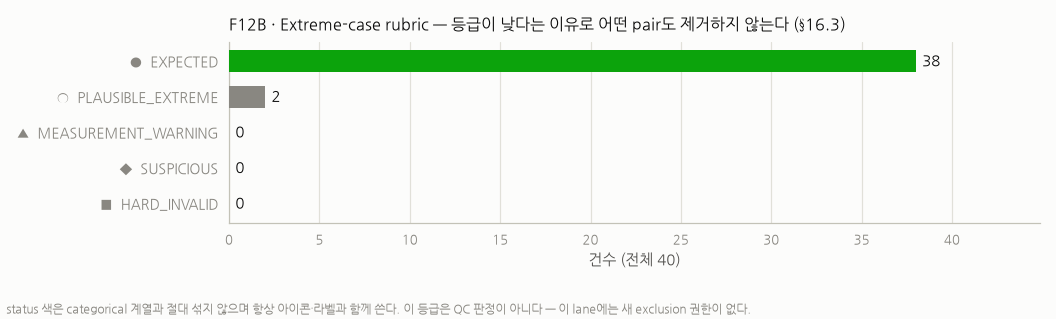

── rubric x domain 교차표 ──


rubric,EXPECTED,PLAUSIBLE_EXTREME,MEASUREMENT_WARNING,SUSPICIOUS,HARD_INVALID
domain,,,,,
dialogue,10,0,0,0,0
general,10,0,0,0,0
other,8,2,0,0,0
technology,10,0,0,0,0


── rubric x length_stratum 교차표 (길이 극단에 몰리는지) ──


rubric,EXPECTED,PLAUSIBLE_EXTREME,MEASUREMENT_WARNING,SUSPICIOUS,HARD_INVALID
length_stratum,,,,,
Q1,12,1,0,0,0
Q2,3,0,0,0,0
Q3,10,1,0,0,0
Q4,7,0,0,0,0
Q5,6,0,0,0,0



── EXPECTED가 아닌 case 목록 (후속 audit 후보, 제거 대상 아님) ──


,domain,pair_id,length_stratum,logTP,rubric,rubric_reason
0,other,a09e7c91,Q3,-0.2513,PLAUSIBLE_EXTREME,핵심 feature 중 하나 이상이 모집단 p01 미만 또는 p99 초과
1,other,9dd42032,Q1,0.5390,PLAUSIBLE_EXTREME,핵심 feature 중 하나 이상이 모집단 p01 미만 또는 p99 초과


In [24]:
# /**
#  * @cell Directive §26의 5단계 rubric으로 40건을 분류한다(등급이 낮다는 이유로 제거하지 않는다).
#  * @ssot §16.3 extreme-case audit; §10.1 hard exclusion; §10.2 soft flags; §31 G2/G3; §32 T-05
#  * @why 극단값을 만나면 지우고 싶은 유혹이 생긴다. SSOT는 정확히 그것을 금지한다. rubric은
#  *      '지울지'가 아니라 '왜 극단인지'를 분류하는 도구이며, 판정 권한 없이도 분류는 할 수 있다.
#  * @input TOK_SAMPLE, MORPH_SAMPLE, PCT, PAIR_REGISTRY_v002의 soft flag 열
#  * @output CASEBOOK(DataFrame 40행), F12B figure
#  * @data_type rubric=ORDINAL(심각도), 근거=BINARY 조합
#  * @target 후속 audit이 필요한 case의 식별
#  * @controls length_stratum(문맥)
#  * @risk 이 등급은 QC 판정이 아니다. 새 exclusion을 만들 권한이 이 lane에는 없다.
#  */

# @line D-01의 soft/hard flag를 40건에 대해서만 읽어와 rubric 근거로 쓴다(§10.2).
_FLAG_COLS = ["unicode_anomaly_flag", "markup_dominant_flag", "control_char_excess_flag",
              "decode_integrity_flag", "short_text_flag", "long_text_flag",
              "high_digit_ratio_flag", "high_punctuation_ratio_flag", "script_mix_flag",
              "named_entity_heavy_flag", "translation_quality_review_flag",
              "lang_side_anomaly_review_flag"]
with duck() as _con:
    FLAGS = _con.execute(
        f"SELECT pair_id, {', '.join(_FLAG_COLS)} FROM read_parquet('{_REG}') "
        f"WHERE pair_id IN ({_ids_sql})"
    ).df()

# @line rubric 계산에 필요한 세 layer의 판정 재료를 하나의 표로 모은다.
CASEBOOK = (SAMPLE[["pair_id", "domain", "length_stratum", "translation_direction", "logical_corpus"]]
            .merge(TOK_SAMPLE[["pair_id", "logTP", "TP", "identity_abs_error", "roundtrip_ok"]],
                   on="pair_id", validate="one_to_one")
            .merge(MORPH_SAMPLE[["pair_id", "ko_morpheme_count", "ko_analysis_warning_flag",
                                 "ko_analysis_warning_reason"]], on="pair_id", validate="one_to_one")
            .merge(FLAGS, on="pair_id", validate="one_to_one"))

# @line SUSPICIOUS 판정에 쓸 flag는 '구조적 이상' 계열로 한정한다(길이 flag는 이상이 아니다).
_ANOMALY_FLAGS = ["unicode_anomaly_flag", "markup_dominant_flag",
                  "control_char_excess_flag", "decode_integrity_flag"]
CASEBOOK["anomaly_flag_any"] = CASEBOOK[_ANOMALY_FLAGS].any(axis=1)
# @line 모집단 꼬리 여부는 cell 05에서 만든 percentile을 재사용한다(새 기준을 만들지 않는다).
if PCT is not None:
    _tail = PCT.set_index("pair_id")[PCT_FEATURES]
    CASEBOOK["tail_p01_p99"] = CASEBOOK.pair_id.map(
        ((_tail < 1.0) | (_tail > 99.0)).any(axis=1)).fillna(False)
else:
    # @line population 좌표계가 없으면 꼬리 판정을 하지 않는다(sample 범위를 percentile이라 부르지 않는다).
    CASEBOOK["tail_p01_p99"] = False


def classify(row) -> tuple[str, str]:
    """
    /**
     * @purpose Directive §26의 5단계 rubric으로 한 pair를 분류하고 근거 문자열을 함께 돌려준다.
     * @spec_ref Directive §26; §16.3(극단값 선삭제 금지); §31 G2/G3; §32 T-05
     * @param row CASEBOOK의 한 행
     * @return (등급, 근거)
     * @raises 없음
     * @validation 5개 등급 외의 값이 나오지 않는지, 심각도 우선순위가 지켜지는지로 검사한다.
     */
    """
    # @line 가장 심각한 조건부터 검사해야 낮은 등급이 높은 등급을 덮지 않는다.
    if (not row.roundtrip_ok) or (row.identity_abs_error >= EXACT_DECOMPOSITION_EPSILON):
        return "HARD_INVALID", "roundtrip 실패 또는 identity 오차 >= ε (§31 G2/G3)"
    # @line 분석기 실패는 canonical analysis_warning_flag로 판정한다(자체 기준을 만들지 않는다).
    if bool(row.ko_analysis_warning_flag):
        return "MEASUREMENT_WARNING", f"analyzer warning: {row.ko_analysis_warning_reason} (§32 T-05)"
    # @line 구조적 이상 flag는 내용이 아니라 표현 층위의 문제이므로 별도 등급으로 분리한다.
    if row.anomaly_flag_any:
        hit = [c for c in _ANOMALY_FLAGS if row[c]]
        return "SUSPICIOUS", f"D-01 구조 flag 점등: {hit} (§10.2)"
    # @line 모집단 꼬리는 '이상'이 아니라 '드묾'이다. 그래서 별도 등급이며 제거 대상이 아니다.
    if row.tail_p01_p99:
        return "PLAUSIBLE_EXTREME", "핵심 feature 중 하나 이상이 모집단 p01 미만 또는 p99 초과"
    return "EXPECTED", "특이 조건 없음"


# @line 분류 결과와 근거를 함께 저장해, 나중에 등급만 보고 이유를 되묻지 않아도 되게 한다.
CASEBOOK[["rubric", "rubric_reason"]] = CASEBOOK.apply(
    lambda r: pd.Series(classify(r)), axis=1)

# @line 등급은 심각도 순서를 갖는 ORDINAL이므로 표시 순서를 상수로 고정한다.
_RUBRIC_ORDER = ["EXPECTED", "PLAUSIBLE_EXTREME", "MEASUREMENT_WARNING", "SUSPICIOUS", "HARD_INVALID"]
# @line status 색은 categorical과 절대 섞지 않는 예약 색이며 항상 라벨과 함께 쓴다.
_RUBRIC_COLOR = {"EXPECTED": STATUS["good"], "PLAUSIBLE_EXTREME": INK["muted"],
                 "MEASUREMENT_WARNING": STATUS["warning"], "SUSPICIOUS": STATUS["serious"],
                 "HARD_INVALID": STATUS["critical"]}
_RUBRIC_ICON = {"EXPECTED": "●", "PLAUSIBLE_EXTREME": "○", "MEASUREMENT_WARNING": "▲",
                "SUSPICIOUS": "◆", "HARD_INVALID": "■"}

fig, ax = plt.subplots(figsize=(9.6, 2.9))
_counts = CASEBOOK.rubric.value_counts().reindex(_RUBRIC_ORDER).fillna(0).astype(int)
for yi, grade in enumerate(_RUBRIC_ORDER):
    n = int(_counts[grade])
    ax.barh(yi, n, height=MARK["bar_max"], color=_RUBRIC_COLOR[grade], edgecolor="none", zorder=3)
    # @line status 색은 단독으로 의미를 전달할 수 없으므로 아이콘 + 라벨 + 수치를 항상 병기한다.
    ax.text(n + 0.35, yi, f"{n}", va="center", fontsize=9.5, color=INK["primary"])
ax.set_yticks(range(len(_RUBRIC_ORDER)))
ax.set_yticklabels([f"{_RUBRIC_ICON[g]}  {g}" for g in _RUBRIC_ORDER], fontsize=9)
ax.invert_yaxis()
ax.set_xlim(0, max(int(_counts.max()) * 1.18, 2))
ax.set_xlabel(f"건수 (전체 {len(CASEBOOK)})")
ax.set_title("F12B · Extreme-case rubric — 등급이 낮다는 이유로 어떤 pair도 제거하지 않는다 (§16.3)",
             loc="left", color=INK["primary"], pad=8)
tidy(ax, xgrid=True, ygrid=False)
fig.text(0.006, 0.02,
         "status 색은 categorical 계열과 절대 섞지 않으며 항상 아이콘·라벨과 함께 쓴다. "
         "이 등급은 QC 판정이 아니다 — 이 lane에는 새 exclusion 권한이 없다.",
         fontsize=8, color=INK["muted"])
fig.tight_layout(rect=(0, 0.11, 1, 1))
plt.show()

print("── rubric x domain 교차표 ──")
display(pd.crosstab(CASEBOOK.domain, CASEBOOK.rubric).reindex(columns=_RUBRIC_ORDER, fill_value=0))
print("── rubric x length_stratum 교차표 (길이 극단에 몰리는지) ──")
display(pd.crosstab(CASEBOOK.length_stratum, CASEBOOK.rubric).reindex(columns=_RUBRIC_ORDER, fill_value=0))
print("\n── EXPECTED가 아닌 case 목록 (후속 audit 후보, 제거 대상 아님) ──")
_flagged = CASEBOOK[CASEBOOK.rubric != "EXPECTED"][
    ["domain", "pair_id", "length_stratum", "logTP", "rubric", "rubric_reason"]].copy()
if len(_flagged):
    _flagged["pair_id"] = _flagged.pair_id.str.slice(5, 13)
    display(_flagged.round(4).reset_index(drop=True))
else:
    print("  (없음 — 40건 모두 EXPECTED)")

---

# 13 — Control / Context Variable Audit

## A. SSOT reference
§9.2 층화 변수; §20.1–20.2 Source effect와 Identifiability Gate (Gate G-ID);
§32 T-03 Translationese / T-04 Domain-source confounding;
redline §8 (026 `특허정보원 ↔ 기술과학` biconditional, N=359,910, exception=0).

## B. 통계적 의미
표본 40건이 어떤 문맥 변수 조합에서 나왔는지 감사한다. **가장 중요한 확인은 교락(confounding)**이다:
`domain`과 `logical_corpus`가 구조적으로 겹쳐 있으면, 두 축의 독립 계수를 동시에 해석할 수 없다 (§20.1).

Gate G-ID (§20.2): *"domain과 source가 구조적으로 식별 불가능하면 coefficient table을 강제로 산출하지 않고
설계를 재매핑한다."*

## C. 데이터 타입
전부 NOMINAL / ORDINAL. 값이 아니라 **교차표의 0 패턴**이 정보다.

## D. 축 의미
교차표(빈도). 그림보다 표가 정확하므로 표를 우선한다 — 7개 이상의 색 계급은 anti-pattern이며
$4\times2$ 교차표는 표가 더 빨리 읽힌다.

## E. Grouping / facet
`domain` × 각 문맥 변수.

## F. 통제/문맥 변수
이 cell의 주제 자체.

## G. 추론할 수 있는 것
- 표본에서 domain과 source가 얼마나 겹치는지 (**모집단 교차표도 함께 확인한다**).
- zero-variance 통제변수의 존재.

## H. 추론할 수 없는 것 (MUST NOT)
- 표본 교차표만으로 모집단 식별가능성을 판정하는 것 → 그래서 **모집단 교차표를 별도로 계산**한다.
- Gate G-ID **판정** — 증거만 제시한다.

In [25]:
# /**
#  * @cell 표본과 모집단 양쪽에서 domain x source 교차표를 만들어 식별가능성 위협을 증거로 제시한다.
#  * @ssot §20.1/§20.2 Identifiability Gate; §32 T-04 domain-source confounding; §9.2 층화 변수
#  * @why 표본 교차표에 0이 많다고 모집단도 그렇다는 보장은 없다. 판정 권한이 없으므로 더더욱
#  *      추측하지 않고 모집단 교차표를 직접 계산해 사실만 올린다.
#  * @input SAMPLE, DOMAIN_COUNTS(모집단 domain x corpus), PAIR_REGISTRY_v002
#  * @output 교차표들과 CONFOUND_REPORT(dict)
#  * @data_type 모두 빈도 교차표(int)
#  * @target domain과 source/direction의 구조적 겹침
#  * @controls 없음
#  * @risk 교락의 존재는 사실이지만 그 대응(재매핑/composite)은 설계 결정이며 이 lane 밖이다.
#  */

print("══ 표본(n=40) 교차표 ══")
_s_dom_corp = pd.crosstab(SAMPLE.domain, SAMPLE.logical_corpus)
print("\n[표본] domain x logical_corpus")
display(_s_dom_corp)
print("[표본] domain x translation_direction")
display(pd.crosstab(SAMPLE.domain, SAMPLE.translation_direction))
print("[표본] domain x length_stratum")
display(pd.crosstab(SAMPLE.domain, SAMPLE.length_stratum))

# @line 모집단 교차표는 cell 04에서 이미 얻은 DOMAIN_COUNTS를 피벗해 재사용한다(중복 스캔 방지).
_p_dom_corp = DOMAIN_COUNTS.pivot_table(index="domain", columns="logical_corpus",
                                        values="population_n", aggfunc="sum").fillna(0).astype(int)
print("\n══ 모집단(final cohort) 교차표 ══")
print("[모집단] domain x logical_corpus")
display(_p_dom_corp)

# @line 무거운 추가 집계 전에 간섭을 다시 확인한다.
_allow_ctx, _guard_ctx = interference_guard("13_context_crosstab")
if _allow_ctx:
    with duck() as _con:
        # @line direction과 sentence_type의 모집단 분포도 확인해야 표본 편향을 판단할 수 있다.
        _p_dir = _con.execute(f"""
            SELECT r.domain, r.translation_direction, count(*) AS n
            FROM read_parquet('{_REG}') r
            SEMI JOIN read_parquet('{_REP}') f ON r.pair_id = f.pair_id
            GROUP BY 1,2 ORDER BY 1,2
        """).df().pivot_table(index="domain", columns="translation_direction",
                              values="n", aggfunc="sum").fillna(0).astype(int)
        _p_stype = _con.execute(f"""
            SELECT r.sentence_type, count(*) AS n
            FROM read_parquet('{_REG}') r
            SEMI JOIN read_parquet('{_REP}') f ON r.pair_id = f.pair_id
            GROUP BY 1 ORDER BY 2 DESC
        """).df()
    print("[모집단] domain x translation_direction")
    display(_p_dir)
    print("[모집단] sentence_type 분포")
    display(_p_stype)
else:
    _p_dir, _p_stype = None, None
    print("간섭 감지 — 모집단 direction/sentence_type 교차표를 건너뛴다.")

# @line 교락 정도를 사람이 읽을 수 있는 형태로 정리한다. 판정이 아니라 사실 진술이다.
CONFOUND_REPORT = {}
# @line 각 domain이 단일 corpus에서만 나오는지 검사한다 — 그것이 곧 완전 교락의 정의다.
_single = _p_dom_corp.gt(0).sum(axis=1)
CONFOUND_REPORT["domains_with_single_corpus"] = _single[_single == 1].index.tolist()
CONFOUND_REPORT["domains_with_multiple_corpus"] = _single[_single > 1].index.tolist()
# @line zero-variance 통제변수는 회귀에 넣어도 아무 정보를 주지 못하므로 미리 표시한다.
CONFOUND_REPORT["zero_variance_in_sample"] = [
    c for c in ("sentence_type", "logical_corpus", "translation_direction", "length_stratum")
    if SAMPLE[c].nunique() == 1
]
if _p_stype is not None:
    CONFOUND_REPORT["population_sentence_type_levels"] = int(len(_p_stype))

print("\n══ §20.2 Identifiability — 증거 (판정 아님) ══")
print(f"단일 corpus에서만 나오는 domain : {CONFOUND_REPORT['domains_with_single_corpus']}")
print(f"두 corpus에 걸친 domain          : {CONFOUND_REPORT['domains_with_multiple_corpus']}")
print(f"표본 내 zero-variance 통제변수   : {CONFOUND_REPORT['zero_variance_in_sample']}")
if _p_stype is not None:
    print(f"모집단 sentence_type 수준 수     : {CONFOUND_REPORT['population_sentence_type_levels']}")
print("\n[§32 T-04] 모집단 교차표에서 일부 domain이 단일 logical_corpus에만 존재한다면, "
      "그 domain의 효과와 source 효과는 구조적으로 분리되지 않는다. "
      "이는 SSOT §20.2가 회귀 실행 전에 확인하라고 지시한 바로 그 조건이며, "
      "본 notebook은 증거만 제시하고 Gate G-ID 판정은 하지 않는다.")

══ 표본(n=40) 교차표 ══

[표본] domain x logical_corpus


logical_corpus,025,026
domain,,
dialogue,10,0
general,10,0
other,7,3
technology,0,10


[표본] domain x translation_direction


translation_direction,EN_TO_KO,KO_TO_EN
domain,,
dialogue,8,2
general,8,2
other,4,6
technology,0,10


[표본] domain x length_stratum


...

[모집단] domain x translation_direction


translation_direction,EN_TO_KO,KO_TO_EN,UNKNOWN
domain,,,
dialogue,254955,247947,13260
general,449606,354654,31
other,568728,1549646,37256
technology,0,359905,0


[모집단] sentence_type 분포


,sentence_type,n
0,other,3835988



══ §20.2 Identifiability — 증거 (판정 아님) ══
단일 corpus에서만 나오는 domain : ['dialogue', 'general', 'technology']
두 corpus에 걸친 domain          : ['other']
표본 내 zero-variance 통제변수   : ['sentence_type']
모집단 sentence_type 수준 수     : 1

[§32 T-04] 모집단 교차표에서 일부 domain이 단일 logical_corpus에만 존재한다면, 그 domain의 효과와 source 효과는 구조적으로 분리되지 않는다. 이는 SSOT §20.2가 회귀 실행 전에 확인하라고 지시한 바로 그 조건이며, 본 notebook은 증거만 제시하고 Gate G-ID 판정은 하지 않는다.


---

# 14 — Director-Facing Summary

아래 code cell이 **실제 계산된 값**으로 요약을 조립한다. 그 다음 markdown cell은 그 값을
Director가 읽을 서술로 옮긴 것이며, 숫자를 손으로 쓰지 않고 출력에서 가져온다.

In [26]:
# /**
#  * @cell 앞선 모든 cell의 결과를 Directive §30의 10개 항목 순서로 집계해 출력한다.
#  * @ssot §33 결과 해석 프레임; §16.3; §20.2; Directive §30 Director-facing final summary
#  * @why 서술을 손으로 쓰면 숫자가 그림과 어긋난다. 요약은 반드시 계산 결과에서 뽑아야
#  *      notebook 자체가 재현성 record 역할을 할 수 있다.
#  * @input REP_SAMPLE, MORPH_SAMPLE, TOK_SAMPLE, TRI, CONCORDANCE, CASEBOOK, JSD_TABLE, CONFOUND_REPORT
#  * @output SUMMARY(dict) 와 사람이 읽는 출력
#  * @data_type SUMMARY=dict[str, Any] (JSON 직렬화 가능)
#  * @target Director가 다음 결정을 내리는 데 필요한 사실 묶음
#  * @controls 없음
#  * @risk 여기의 모든 수치는 n=40 표본 기술통계다. 어떤 항목도 모집단 추정치가 아니다.
#  */

SUMMARY: dict = {}

# @line (1) Representation이 보여주는 것 — 표면형 층위의 pair 내 비대칭.
SUMMARY["1_representation"] = {
    "median_log_codepoint_ratio": round(float(REP_SAMPLE.log_codepoint_ratio.median()), 4),
    "median_log_byte_density_ratio": round(float(REP_SAMPLE.log_byte_density_ratio.median()), 4),
    "median_ko_bytes_per_codepoint": round(float(REP_SAMPLE.ko_bytes_per_codepoint.median()), 4),
    "median_en_bytes_per_codepoint": round(float(REP_SAMPLE.en_bytes_per_codepoint.median()), 4),
    "pairs_with_ko_shorter_in_codepoints": int((REP_SAMPLE.pair_codepoint_ratio < 1).sum()),
}
# @line (2) Kiwi가 더하는 것 — 표면형만으로는 보이지 않는 KO 문법 구조.
SUMMARY["2_morphology"] = {
    "status": MORPH_LAYER_STATUS,
    "morpheme_density_denominator": MORPHOLOGY_CONFIG["morpheme_density_denominator"],
    "eojeol_source": EOJEOL_SOURCE,
    "median_eojeol_count": round(float(MORPH_SAMPLE.ko_eojeol_count.median()), 2),
    "median_morpheme_density": round(float(MORPH_SAMPLE.ko_morpheme_density.median()), 4),
    "median_particle_ratio": round(float(MORPH_SAMPLE.ko_particle_ratio.median()), 4),
    "median_ending_ratio": round(float(MORPH_SAMPLE.ko_ending_ratio.median()), 4),
    "median_deriv_affix_ratio": round(float(MORPH_SAMPLE.ko_deriv_affix_ratio.median()), 4),
    "analysis_warning_count": int(MORPH_SAMPLE.ko_analysis_warning_flag.sum()),
}
# @line (3) o200k가 더하는 것 — 실제 token 부담과 분해의 세 성분.
SUMMARY["3_tokenizer"] = {
    "status": TOK_LAYER_STATUS,
    "pairs_TP_gt_1": int((TOK_SAMPLE.TP > 1).sum()),
    "median_TP": round(float(TOK_SAMPLE.TP.median()), 4),
    "median_logTP": round(float(TOK_SAMPLE.logTP.median()), 4),
    "median_logCR": round(float(TOK_SAMPLE.logCodePointRatio.median()), 4),
    "median_logBDR": round(float(TOK_SAMPLE.logByteDensityRatio.median()), 4),
    "median_logCP": round(float(TOK_SAMPLE.logCompressionPenalty.median()), 4),
    "roundtrip_failures": int((~TOK_SAMPLE.roundtrip_ok).sum()),
    "identity_abs_error_max": float(TOK_SAMPLE.identity_abs_error.max()),
}
# @line (4) domain 특이 패턴 — domain별 중앙값을 나란히 두어 차이의 크기만 본다(유의성 아님).
SUMMARY["4_domain_specific"] = (
    TOK_SAMPLE.groupby("domain")[["logTP", "logCodePointRatio",
                                  "logByteDensityRatio", "logCompressionPenalty"]]
    .median().round(4).to_dict("index"))
# @line (5) 길이/source/direction을 따라가는 패턴 — domain이 아니라 이쪽이 설명일 가능성.
SUMMARY["5_tracks_length_source_direction"] = {
    "spearman_logTP_vs_ko_codepoint": round(float(
        stats.spearmanr(TRI.logTP, REP_SAMPLE.set_index("pair_id")
                        .loc[TRI.pair_id, "ko_codepoint_count"]).statistic), 3),
    "median_logTP_by_length_stratum": TOK_SAMPLE.groupby("length_stratum").logTP.median().round(4).to_dict(),
    "median_logTP_by_direction": TOK_SAMPLE.groupby("translation_direction").logTP.median().round(4).to_dict(),
    "median_logTP_by_corpus": TOK_SAMPLE.merge(
        SAMPLE[["pair_id", "logical_corpus"]], on="pair_id"
    ).groupby("logical_corpus").logTP.median().round(4).to_dict(),
}
# @line (6) 중복 feature — 항등식으로 묶인 쌍은 |rho|가 높을 수밖에 없다(T-06).
SUMMARY["6_redundant_features"] = {
    "abs_rho_ge_0.8": [
        {"outcome": r, "explain": c, "rho": round(float(CONCORDANCE.at[r, c]), 3)}
        for r in CONCORDANCE.index for c in CONCORDANCE.columns
        if abs(CONCORDANCE.at[r, c]) >= 0.8],
    "note": "exact decomposition 항등식으로 연결된 쌍의 높은 |rho|는 발견이 아니라 정의의 귀결이다(§32 T-06).",
}
# @line (7)(8) 극단/후속 audit — rubric 결과를 그대로 옮긴다.
SUMMARY["7_plausible_extremes"] = CASEBOOK[CASEBOOK.rubric == "PLAUSIBLE_EXTREME"].pair_id.tolist()
SUMMARY["8_needs_later_audit"] = CASEBOOK[
    CASEBOOK.rubric.isin(["MEASUREMENT_WARNING", "SUSPICIOUS", "HARD_INVALID"])
][["pair_id", "rubric", "rubric_reason"]].to_dict("records")
# @line (9) 아직 추론할 수 없는 것 — 권한 경계를 명시적으로 기록한다.
SUMMARY["9_cannot_infer_yet"] = [
    "Median(logTP) > 0 추론 — §17.1 signed-rank + bootstrap(NB08)의 몫",
    "형태소 block의 증분 설명력 — M2 vs M1(NB09)의 몫",
    "domain 차이의 유의성 — n=10/domain",
    "모집단 prevalence / 분해 비중",
    "regex chunk와 token 경계의 관계 — D-05/NB06 부재",
    "G2/G3/G4 PASS 판정 — 이 lane에 권한 없음",
]
# @line (10) 다음에 볼 것 — NB06/NB07이 실제로 확인해야 할 항목만 남긴다.
SUMMARY["10_next_in_NB06_NB07"] = [
    "NB06: regex chunk 층을 넣어 morpheme–chunk–token 세 경계를 처음으로 비교 가능하게 만들 것",
    "NB07: full-population exact decomposition 분포와 §16.2 F02~F05를 canonical로 생성할 것",
    "morphology full-population 실행 후 동일 pair_id로 본 notebook의 40건 값과 equality check",
    "§20.2 Gate G-ID: domain x source 모집단 교차표를 근거로 composite/restriction 설계 결정",
    "REP_FEATURES_v002(ko_eojeol_count/en_word_count) 재생성 후, 본 notebook의 40건 eojeol 값과 대조",
]
SUMMARY["_upstream_migration"] = UPSTREAM_MIGRATION
SUMMARY["_confound"] = CONFOUND_REPORT
SUMMARY["_jsd_min_max"] = {"min": float(JSD_TABLE.JSD_base2.min()),
                           "max": float(JSD_TABLE.JSD_base2.max())}

print(json.dumps(SUMMARY, ensure_ascii=False, indent=1, default=str))

{
 "1_representation": {
  "median_log_codepoint_ratio": -0.8113,
  "median_log_byte_density_ratio": 0.9004,
  "median_ko_bytes_per_codepoint": 2.4606,
  "median_en_bytes_per_codepoint": 1.0,
  "pairs_with_ko_shorter_in_codepoints": 40
 },
 "2_morphology": {
  "status": "SAMPLE_RECOMPUTED_FOR_VISUALIZATION",
  "morpheme_density_denominator": "eojeol_count",
  "eojeol_source": "REP_FEATURES artifact column",
  "median_eojeol_count": 8.0,
  "median_morpheme_density": 2.275,
  "median_particle_ratio": 0.1371,
  "median_ending_ratio": 0.2034,
  "median_deriv_affix_ratio": 0.0742,
  "analysis_warning_count": 0
 },
 "3_tokenizer": {
  "status": "SAMPLE_RECOMPUTED_FOR_VISUALIZATION",
  "pairs_TP_gt_1": 33,
  "median_TP": 1.2222,
  "median_logTP": 0.2007,
  "median_logCR": -0.8113,
  "median_logBDR": 0.9004,
  "median_logCP": 0.136,
  "roundtrip_failures": 0,
  "identity_abs_error_max": 2.7755575615628914e-16
 },
 "4_domain_specific": {
  "dialogue": {
   "logTP": 0.0589,
   "logCodePointRatio

## 14.1 Director-facing 서술 (10개 항목)

> 아래 수치는 모두 위 code cell의 출력에서 온 것이며, 전부 **표본 40건(domain당 10건)** 기술통계다.
> 어떤 항목도 모집단 추정치가 아니고, 어떤 항목도 Gate 판정이 아니다.
> 중앙값은 가법적이지 않으므로, 성분 중앙값의 합은 $\log TP$ 중앙값과 정확히 같지 않다.

**1. Representation이 보여주는 것 — 두 힘이 서로 반대 방향이다.**
표본 40건 **전부**에서 한국어가 영어보다 code point가 **적다**
($\text{median}\ \log CR = -0.811$). 동시에 한국어의 byte/code point 중앙값은 **2.46**,
영어는 **1.00**이어서 byte 밀도는 크게 **높다** ($\text{median}\ \log BDR = +0.900$).
즉 "한국어가 길어서 token이 많다"는 통념은 이 표본에서 성립하지 않는다.
표현 길이와 byte 밀도는 서로 **상쇄하는 방향**으로 작동하며, 둘의 중앙값 합은 $+0.089$에 그친다.
SSOT §8이 이 둘을 별도 성분으로 분리한 설계가 표본 수준에서 정확히 정당화된다.

**2. Kiwi가 더하는 것.**
형태소 layer는 표면형이 말하지 않는 KO 내부 구조를 준다: 어절당 형태소 **2.28개**(중앙값),
형태소 중 조사 **13.7%**, 어미 **20.3%**, 파생접사 **7.4%**. 분석 경고(`analysis_warning_flag`)는
40건 중 **0건**이다. 다만 이 layer는 full artifact가 없어 40건 재계산값이며
(`SAMPLE_RECOMPUTED_FOR_VISUALIZATION`), 따라서 population percentile을 붙이지 않았다.
밀도 분모는 upstream 변경 이후 SSOT §13.6대로 `eojeol_count`이며, 그 열은
`REP_FEATURES_v002` artifact에서 직접 join했다.

**3. o200k가 더하는 것 — 그리고 이것이 이 표본의 핵심이다.**
40건 중 **33건**에서 $TP > 1$이고 중앙값 $TP = 1.222$, $\log TP = +0.201$이다.
결정적으로 $\text{median}\ \log CP = +0.136$ 으로, **byte 량을 이미 나눈 뒤에도 남는
tokenizer 고유의 비대칭이 표현 길이·byte 밀도의 순합($+0.089$)보다 크다.**
SSOT §33의 해석 프레임에서 이 표본은 Case A(ByteDensity 주도)가 아니라
**Case B(CompressionPenalty도 큼)** 쪽으로 보인다. 이는 40건의 관찰이지 추론이 아니다.
roundtrip 실패 **0건**, exact decomposition identity 오차 최대 $2.78\times10^{-16}$
($\varepsilon = 10^{-10}$ 미만)으로 §31 G2/G3 조건의 표본 증거는 확보되어 있다 — **판정은 하지 않는다.**

**4. domain 특이 패턴.**
$\log TP$ 중앙값이 dialogue $0.059$ < general $0.199$ < other $0.264$ < technology $0.397$ 로
단조 증가한다. 특히 **dialogue는 $\log CP$ 중앙값이 $-0.052$ 로 음수**다 — 이 domain에서는
tokenizer가 byte당으로는 오히려 한국어를 더 잘 압축한다. 다만 domain당 $n=10$이므로
**차이의 유의성을 주장하지 않는다**(Directive §27). 그리고 5번이 더 중요하다.

**5. domain이 아니라 corpus·direction·길이를 따라가는 패턴 — 이 표본의 가장 강한 경고.**
**모집단** 교차표에서 `dialogue`·`general`은 025에만, `technology`는 026에만 존재하고,
`other`만 두 corpus에 걸쳐 있다. 게다가 `technology`의 모집단 `translation_direction`은
**KO_TO_EN 359,905건 / EN_TO_KO 0건**으로 방향까지 완전히 고정되어 있다.
따라서 4번의 "domain 차이"는 **domain 효과와 source 효과와 direction 효과를 분리할 수 없는 상태**다.
이것이 SSOT §32 T-04와 §20.2 Gate G-ID가 회귀 실행 전에 확인하라고 지시한 바로 그 조건이며,
표본이 아니라 **모집단에서** 관측되었다.
추가로 `sentence_type`은 최종 코호트 **3,835,988건 전부가 `other` 단일값**이어서
통제변수로 기능할 수 없다. 길이는 단조적이지 않다
($Q1\ 0.201$, $Q2\ 0.125$, $Q3\ 0.091$, $Q4\ 0.505$, $Q5\ 0.198$).

**6. 중복 feature.**
$\rho_s(\log TP,\ \log CR) = +0.647$ 은 두 양이 exact decomposition 항등식으로 묶여 있기 때문이며
**발견이 아니라 정의의 귀결**이다(§32 T-06). 반면 형태소 feature는 이 표본에서 모두 약하다
($|\rho_s| \le 0.192$; 최대는 $\rho_s(\log TP,\ \text{어미 비율}) = -0.192$).
$|\rho_s| \ge 0.8$ 인 쌍은 없다. 통제변수가 없으므로 이것은 §6.4의 증분 설명력에 대한 답이 **아니다.**

**7. 그럴듯한 극단.**
`PLAUSIBLE_EXTREME` 2건(둘 다 `other` domain, `a09e7c91`·`9dd42032`)은 모집단 p01/p99 밖에
있을 뿐 오류가 아니다. §16.3에 따라 **하나도 제거하지 않았다.**

**8. 후속 audit이 필요한 case.**
`MEASUREMENT_WARNING` / `SUSPICIOUS` / `HARD_INVALID` **0건**이다.
40건 중 38건이 `EXPECTED`이며, STOP 조건에 해당하는 case는 없었다.

**9. 아직 추론할 수 없는 것.**
$\operatorname{Median}(\log TP) > 0$ 검정(§17.1 signed-rank + bootstrap, NB08),
형태소 block의 증분 설명력(M2 vs M1, NB09), domain 차이의 유의성, 모집단 분해 비중,
regex chunk와 token 경계의 관계(D-05 부재), G2/G3/G4 판정 — 전부 이 notebook 밖이다.

**10. NB06/NB07에서 볼 것.**
① **NB06 regex chunk layer**를 넣어야 비로소 §5.1의 세 경계를 처음으로 비교할 수 있다.
그 전까지 morpheme–token align 주장은 불가능하다.
② **§20.2 Gate G-ID를 회귀 전에 반드시 통과시켜야 한다** — 5번의 모집단 교차표가
domain × source × direction 완전 교락을 이미 보여주므로, composite 변수 또는 restriction 설계가
필요하고 `sentence_type`은 모형에서 제외되어야 한다.
③ morphology / o200k **full-population 실행 후 동일 `pair_id`로 본 notebook의 40건 값과
equality check**를 걸면 이 exploratory 계산이 canonical 계산과 같은지 한 번에 검증된다
(그 목적으로 cell 15에 40개 `pair_id`와 집합 hash를 남겼다).
④ 표본에서 $\log CP$가 premium의 지배적 성분으로 보이므로, NB07의 full-population
$\log CP$ 분포와 §16.2 F04–F05가 최우선 확인 대상이다.

---

# 15 — Reproducibility Record

## A. SSOT reference
§30.1 환경; §30.2 데이터 lineage; §30.3 Seed policy; §38 release manifest 요건;
Directive §31 (외부 manifest 불필요 — **notebook 자체가 이 exploratory 작업의 재현성 기록이다**).

## B. 기록 항목
Git HEAD · SSOT 파일 hash · 입력 artifact hash · sample seed · 선택된 pair_id 전체 ·
domain별 건수 · package 버전 · CPU/RAM 스냅샷 · DuckDB 한도 · thread 한도 · 실행 timestamp ·
layer artifact 상태.

## C~H
이 cell은 기록이므로 축/추론 항목은 해당 없음. **아무것도 추론하지 않는다.**

In [27]:
# /**
#  * @cell 이 exploratory 실행 전체의 재현성 기록을 하나의 dict로 조립해 출력한다.
#  * @ssot §30.1 환경; §30.2 lineage; §30.3 seed policy; Directive §31
#  * @why 외부 manifest 파일을 만들지 않기로 했으므로, 재현에 필요한 모든 값이 이 출력 안에
#  *      전부 들어 있어야 한다. 여기에 없는 값은 사실상 기록되지 않은 것이다.
#  * @input 앞선 모든 cell의 상태
#  * @output REPRO(dict)와 사람이 읽는 출력
#  * @data_type REPRO=dict[str, Any] (JSON 직렬화 가능)
#  * @target 이 실행을 그대로 재현하는 데 필요한 전부
#  * @controls 없음
#  * @risk 큰 parquet의 SHA-256은 계산 비용이 크므로 manifest에 기록된 기대값을 함께 남기고,
#  *       실제 재계산은 하지 않는다는 사실을 명시한다.
#  */

def _git(*args: str) -> str | None:
    """
    /**
     * @purpose git 명령을 실행해 표준출력을 돌려주되, 실패해도 notebook을 중단시키지 않는다.
     * @spec_ref §30.2 데이터 lineage (Git commit SHA)
     * @param args git 하위 명령 인자
     * @return 명령 출력 문자열 또는 실패 시 None
     * @raises 없음
     * @validation 반환값이 None이 아니면 40자 SHA 형식인지 눈으로 확인한다.
     */
    """
    try:
        # @line cwd를 PROJECT_ROOT로 고정해야 다른 저장소의 HEAD를 읽는 사고가 없다.
        return subprocess.run(["git", *args], cwd=PROJECT_ROOT, capture_output=True,
                              text=True, timeout=15, check=True).stdout.strip()
    except Exception:
        return None


# @line SSOT 파일들의 hash를 직접 계산한다 — 이 파일들은 작아서 매 실행 계산해도 부담이 없다.
_ssot_hashes = {}
for p in sorted((PROJECT_ROOT / "ssot").rglob("*")):
    if p.is_file():
        # @line 8KB 단위 스트리밍으로 읽어 큰 PDF에서도 메모리를 쓰지 않는다.
        h = hashlib.sha256()
        with p.open("rb") as fh:
            for chunk in iter(lambda: fh.read(8192), b""):
                h.update(chunk)
        _ssot_hashes[str(p.relative_to(PROJECT_ROOT))] = h.hexdigest()

REPRO = {
    "artifact_class": "EXPLORATORY / PRE-NB07 / PRE-F07 MULTILAYER DIAGNOSTIC CASEBOOK",
    "notebook": "notebooks/exploratory/EDA_representation_kiwi_o200k_casebook.ipynb",
    "lane": "CLAUDE-VIZ (no gate authority, no full-population authority)",
    "run_id": RUN_ID,
    "started_kst": RUN_STARTED_KST.isoformat(),
    "finished_kst": datetime.now(KST).isoformat(),

    "git": {
        "head": _git("rev-parse", "HEAD"),
        "branch": _git("rev-parse", "--abbrev-ref", "HEAD"),
        "dirty_files": (_git("status", "--porcelain") or "").splitlines(),
    },
    "ssot_file_sha256": _ssot_hashes,
    # @line src가 uncommitted 상태로 바뀌면 git SHA만으로는 실제 사용한 코드를 특정할 수 없다.
    #       그래서 import한 모듈 파일의 내용 hash를 따로 남긴다.
    "src_module_sha256": {
        rel: hashlib.sha256((PROJECT_ROOT / rel).read_bytes()).hexdigest()
        for rel in ("src/tokenization_premium/representation.py",
                    "src/tokenization_premium/morphology.py",
                    "src/tokenization_premium/tokenizer_measurement.py",
                    "src/tokenization_premium/tokenization.py")
    },
    "upstream_migration_observed": UPSTREAM_MIGRATION,

    "input_artifacts": {
        # @line 실제 파일 상태(존재/크기/시각)와 manifest의 기대 hash를 함께 남긴다.
        "PAIR_REGISTRY_v002": {
            **ARTIFACTS["PAIR_REGISTRY_v002"],
            "manifest_expected_sha256": (MANIFESTS["QC_MANIFEST_v001"] or {}).get("output", {}).get("sha256"),
        },
        "REP_FEATURES_selected": {
            "key": REP_ARTIFACT_KEY,
            **ARTIFACTS[REP_ARTIFACT_KEY],
            "manifest_expected_sha256": (
                MANIFESTS.get(f"REP_FEATURES_MANIFEST_{REP_ARTIFACT_KEY.rsplit('_', 1)[-1]}") or {}
            ).get("output", {}).get("sha256"),
        },
        "note": "대용량 parquet의 SHA-256은 이 notebook에서 재계산하지 않는다(I/O 비용). manifest 기대값만 기록한다.",
    },

    "sample": {
        "frozen_seed": FROZEN_SEED,
        "seed_provenance": "D-RD-01 auxiliary_seed (동결된 seed bundle; 새 seed를 만들지 않았다)",
        "selection_rule": "partition by domain, order by md5(pair_id || seed) then pair_id, rank <= 10",
        "n_per_domain": 10,
        "n_total": len(SAMPLE),
        "populated_domains": POPULATED_DOMAINS,
        "domain_counts_population": DOMAIN_COUNTS.to_dict("records"),
        "sample_set_sha256": SAMPLE_SET_SHA256,
        "pair_ids": list(SAMPLE_IDS),
    },

    "layer_state": LAYER_STATE,
    "layer_status_reported": {
        "R_representation": "FROM_FULL_ARTIFACT",
        "M_morphology": MORPH_LAYER_STATUS,
        "T_tokenizer": TOK_LAYER_STATUS,
    },
    "population_context": {
        "mode": POP_MODE,
        "population_n": POP_N,
        "source": f"{REP_ARTIFACT_KEY}.parquet (post-exclusion final cohort)",
        "note": "Morphology/Tokenizer layer에는 full artifact가 없으므로 'population percentile'이라는 표현을 쓰지 않았다.",
    },

    "measurement_freeze": {
        "tokenizer_id": "o200k_base",
        "tiktoken_version": tiktoken.__version__,
        "encoding_name": ENCODING.name,
        "tokenizer_artifact_sha256": (MANIFESTS["TOKENIZER_O200K_BASE_ARTIFACT_v001"] or {}).get("encoding_file_sha256"),
        "pat_str_sha256": (MANIFESTS["TOKENIZER_O200K_BASE_ARTIFACT_v001"] or {}).get("pat_str_sha256"),
        "mergeable_ranks_hash": (MANIFESTS["TOKENIZER_O200K_BASE_ARTIFACT_v001"] or {}).get("mergeable_ranks_hash"),
        "analyzer_name": "Kiwi",
        "kiwipiepy_version": ANALYZER_PACKAGE_VERSION,
        "kiwi_model_version": ANALYZER_MODEL_VERSION,
        "kiwi_model_manifest_sha256": ANALYZER_MODEL_MANIFEST_SHA256,
        "custom_dictionary_used": False,
        "representation_config_sha256": REPRESENTATION_CONFIG_SHA256,
        "morphology_config_sha256": MORPHOLOGY_CONFIG_SHA256,
        "rep_features_schema_version": REP_FEATURES_SCHEMA_VERSION,
        "exact_decomposition_epsilon": EXACT_DECOMPOSITION_EPSILON,
        "config_match": CONFIG_MATCH,
    },

    "resource_isolation": {
        "os_nice": os.nice(0),
        "thread_budget": THREAD_BUDGET,
        "thread_env": {v: os.environ.get(v) for v in
                       ("OMP_NUM_THREADS", "MKL_NUM_THREADS", "OPENBLAS_NUM_THREADS", "NUMEXPR_NUM_THREADS")},
        "duckdb_memory_limit": "1GB",
        "duckdb_threads": THREAD_BUDGET,
        "duckdb_spill_dir": str(SPILL_DIR.relative_to(PROJECT_ROOT)),
        "gpu_workload_created": False,
        "forbidden_modules_absent": [m for m in _FORBIDDEN_MODULES if m not in sys.modules],
        "resource_at_start": RESOURCE_AT_START,
        "resource_at_end": resource_snapshot(),
        "main_a_interference": "NONE" if not RESOURCE_AT_START["heavy_jobs"] else "DETECTED",
    },

    "environment": {
        "python": sys.version.split()[0],
        "platform": platform.platform(),
        "packages": {m.__name__: getattr(m, "__version__", "n/a")
                     for m in (np, pd, matplotlib, sns, duckdb, tiktoken, psutil)},
        "scipy": stats.__name__ and __import__("scipy").__version__,
        "kiwipiepy": ANALYZER_PACKAGE_VERSION,
        "korean_font": _FONT,
    },

    "palette_validation": {
        "tool": "dataviz skill scripts/validate_palette.js (bundled pack 2.1.233)",
        "mode_checked": ["light", "dark"],
        "pairs_mode": "all",
        "families": {
            "language_side": {"hex_light": [PALETTE["ko"], PALETTE["en"]],
                              "result": "ALL PASS (CVD ΔE 24.7 light / 26.8 dark; NV 33.6 / 31.8)"},
            "decomposition": {"hex_light": [PALETTE["log_cr"], PALETTE["log_bdr"], PALETTE["log_cp"]],
                              "result": "PASS with CVD floor-band WARN (6.9 / 6.5) → 고정 성분 순서 + 직접 label 보조부호 적용"},
            "morphology": {"hex_light": [PALETTE["morph_particle"], PALETTE["morph_ending"], PALETTE["morph_deriv"]],
                           "result": "PASS (CVD 16.2 light / 6.9 dark; NV 19.6 / 19.3)"},
        },
        "contrast_relief_applied": "light 표면 sub-3:1 색(#1baf7a 2.74, #e87ba4 2.62, #eda100 2.11)에 대해 "
                                   "직접 label + table view 제공",
        "dark_mode": "dark step을 선택·검증했으나 이 notebook은 light 표면에 렌더링된다(PALETTE_DARK에 값 보존).",
    },

    "authority_boundary": {
        "gate_decisions_made": [],
        "new_qc_or_exclusion_created": [],
        "files_written_to_repository": ["notebooks/exploratory/EDA_representation_kiwi_o200k_casebook.ipynb"],
        "src_modified": False, "tests_modified": False,
        "canonical_notebooks_modified": False,
        "git_operations": "NONE (add/commit/push 하지 않았다)",
        "raw_text_rendered": False,
    },
}

print(json.dumps(REPRO, ensure_ascii=False, indent=1, default=str))

{
 "artifact_class": "EXPLORATORY / PRE-NB07 / PRE-F07 MULTILAYER DIAGNOSTIC CASEBOOK",
 "notebook": "notebooks/exploratory/EDA_representation_kiwi_o200k_casebook.ipynb",
 "lane": "CLAUDE-VIZ (no gate authority, no full-population authority)",
 "run_id": "VIZ_CASEBOOK_20260817T151317",
 "started_kst": "2026-08-17T15:13:17.266596+09:00",
 "finished_kst": "2026-08-17T15:14:34.484709+09:00",
 "git": {
  "head": "2d99c906c7c94a9ce2ee2e0ff9dc01cf61998c3a",
  "branch": "main",
  "dirty_files": [
   "M notebooks/00_environment_repro.ipynb",
   " M notebooks/02_normalize_and_qc.ipynb",
   " M notebooks/03_representation_features.ipynb",
   " M notebooks/04_morphology_features.ipynb",
   "?? notebooks/exploratory/EDA_representation_kiwi_o200k_casebook.ipynb",
   "?? outputs/manifests/QC_MANIFEST_v001.json",
   "?? outputs/manual_audit/KOEN_MANUAL_AUDIT_500.xlsx",
   "?? outputs/manual_audit/build_manual_audit_sample.py",
   "?? outputs/manual_audit/manual_audit_sampling_key.csv",
   "?? outputs

---

## 15.1 Notebook 종료 상태

```text
MULTILAYER_DATAVIZ_NOTEBOOK_COMPLETE
```

- 산출물: `notebooks/exploratory/EDA_representation_kiwi_o200k_casebook.ipynb` (이 파일 하나)
- Git: add/commit/push **하지 않음**
- Gate 판정: **없음**
- 새 QC / exclusion: **없음**
- `src/`, `tests/`, canonical notebook 03/04/05: **수정 없음**
- 새 `.py` 파일: **없음**
- 원문 KO/EN 문장 렌더링: **없음**